In [107]:
import pandas as pd
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as LogNorm
import matplotlib.ticker as ticker
import math
import csv 
import sys

#python makeRatios.py outfile file_1 title_1 file_2 title_2 ...
#outFileName = sys.argv[1]
inFile_1 = uproot.open("../histograms/analysis_note/ratio_10.2_rho_pT_fullUnc.root")

colorList = ['red', 'blue', 'magenta', 'green', 'brown', 'gold', 'cyan', 'blueviolet', 'darkorange', 'black', 'yellow', 'gray', 'red', 'blue', 'magenta', 'green', 'brown', 'gold', 'cyan', 'blueviolet', 'darkorange', 'black', 'yellow', 'gray', 'red', 'blue', 'magenta', 'green', 'brown', 'gold', 'cyan', 'blueviolet', 'darkorange', 'black', 'yellow', 'gray']



(7, 3)
(22, 5)


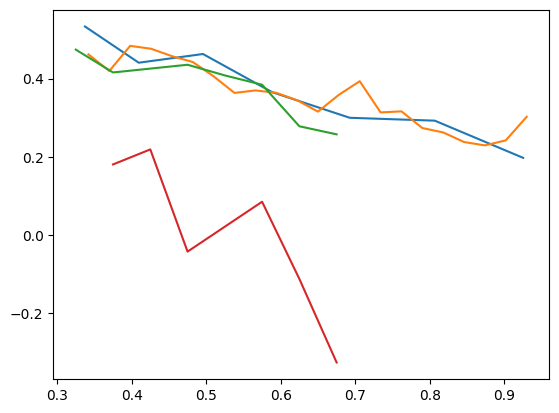

In [ ]:
def ff(z):
	return (1-z)/(z+1)

def load_csv(path, delimiter=','):
    """Load a delimited file, skipping all non-numeric header rows."""
    with open(path) as f:
        lines = f.readlines()
    skip = 0
    for line in lines:
        fields = [s.strip() for s in line.strip().split(delimiter) if s.strip()]
        try:
            [float(v) for v in fields]
            break
        except ValueError:
            skip += 1
    return np.loadtxt(path, delimiter=delimiter, skiprows=skip)

z_vals = np.linspace(.3, .8, 100)
file_path = ["../data/exp_data/HERMES2000.csv",
             "../data/exp_data/JLAB2012_r_Table11.csv",
              #"../data/exp_data/Cornell77_xB_0.24_Q2_2.0.csv",
              #"../data/exp_data/Cornell77_xB_0.5_Q2_4.0.csv",
              "../data/exp_data/jlab_hallC.csv",
              "../data/exp_data/jlab_hallC.csv"
              ]

# Hall C W filter — set to None to include all panels
hallC_W_min = 2.4   # e.g. 2.0
hallC_W_max = 2.6   # e.g. 3.0
z=[]
r=[]
dr=[]

delim = [',',',',',',',',',',',']
label = [r'Hermes 2000: $x_B=.32, Q^2 > 1, W > 3.3$',
         r'JLAB 2012: $x_B=.32, Q^2=2.3, W=2.4$',
         #r'Cornell 1977: $x_B = 0.24, Q^2 = 2.0, W=2.7$',
         #r'Cornell 1977: $x_B = 0.5, Q^2 = 4.0, W=2.7$',
         r'JLAB Hall C: $D_{u}^{\pi^-}$ (unf) / $D_{d}^{\pi^-}$ (fav)',
         r'JLAB Hall C: $D_{d}^{\pi^+}$ (unf) / $D_{u}^{\pi^+}$ (fav)'
]
marker = ['x','s','^','D','*','v']

for i in range(len(file_path)):
    if i == 2:  # Hall C — sparse CSV, use pandas to handle empty cells
        df = pd.read_csv(file_path[i])
        w_mask = pd.Series([True] * len(df))
        if hallC_W_min is not None: w_mask &= df['avg_W_GeV'] >= hallC_W_min
        if hallC_W_max is not None: w_mask &= df['avg_W_GeV'] <= hallC_W_max
        mask = df['Dupi-_unf'].notna() & df['Ddpi-_fav'].notna() & w_mask
        z.append(df.loc[mask, 'z_nominal'].values)
        A  = df.loc[mask, 'Dupi-_unf'].values
        B  = df.loc[mask, 'Ddpi-_fav'].values
        dA = df.loc[mask, 'Dupi-_unf_stat_err'].values
        dB = df.loc[mask, 'Ddpi-_fav_stat_err'].values
        ratio = A / B
        r.append(ratio)
        dr.append(np.abs(ratio) * np.sqrt((dA/A)**2 + (dB/B)**2))
    elif i == 3:  # Hall C second ratio — Ddpi+_unf / Ddpi-_fav
        df = pd.read_csv(file_path[2])
        w_mask = pd.Series([True] * len(df))
        if hallC_W_min is not None: w_mask &= df['avg_W_GeV'] >= hallC_W_min
        if hallC_W_max is not None: w_mask &= df['avg_W_GeV'] <= hallC_W_max
        mask = df['Ddpi+_unf'].notna() & df['Dupi+_fav'].notna() & w_mask
        z.append(df.loc[mask, 'z_nominal'].values)
        A  = df.loc[mask, 'Ddpi+_unf'].values
        B  = df.loc[mask, 'Dupi+_fav'].values
        dA = df.loc[mask, 'Ddpi+_unf_stat_err'].values
        dB = df.loc[mask, 'Dupi+_fav_stat_err'].values

        ratio = A / B
        r.append(ratio)
        dr.append(np.abs(ratio) * np.sqrt((dA/A)**2 + (dB/B)**2))
    else:
        data = load_csv(file_path[i], delimiter=delim[i])
        print(data.shape)
        z.append(data[:, 0])
        r.append(data[:, 1] if i < 2 else (4-data[:, 1])/(4*data[:, 1] - 1))
        if i < 2:
            dr.append(data[:,2])
        else:
            dr.append(np.zeros(len(data)))

    plt.plot(z[i], r[i])


In [109]:
def edit_ax(ax):
    ax.set_ylim( [0, 0.8] )   
    ax.set_xlim( [.3, .8] )
		
    z = np.linspace( .3, 1, 500 )
    ax.axhline( y=1, xmin=0, xmax=1 , color = 'black', linestyle = '--')
	
    ax.set_xlabel(r'$z$', fontsize=20)
    ax.set_ylabel(r'$r(z)$', fontsize=20)


In [110]:
def make_plots(inFile1,  ax, q, x, label, colorIdx):
    hist_1 = inFile1[f'hFF_0_{q+1}_{x+1}']
    
    values_1 =np.array( hist_1.values() )
    values_1[values_1 <= 0] = np.nan
    if( np.isnan(values_1).all() ):
        return
    errors_1 = np.array(hist_1.errors())
    #values_1 = (4-values_1)/(4*values_1 - 1)
    
    xEdges = hist_1.axis().edges()
    binCenters = np.asarray((xEdges[:-1]+xEdges[1:])/2 )


    label_x = r'%.2f $< x_B <$ %.2f, %.2f < $Q^2$ < %.2f [GeV]'%( .1 + .04*x, .1 + .04*(x+1), 2 + .5*q, 2.5 + .5*q)

    ax.tick_params(labelsize=16)
    ax.errorbar( binCenters, values_1, errors_1, marker='o',
                        color = colorList[1], linestyle = '',capsize = 2, lw = 1, capthick = 1, label=label_x)

/var/folders/4d/9x90517x6q3cc4_sz1jrqlj00000gn/T/ipykernel_91261/2419440451.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(12,6), layout='constrained')


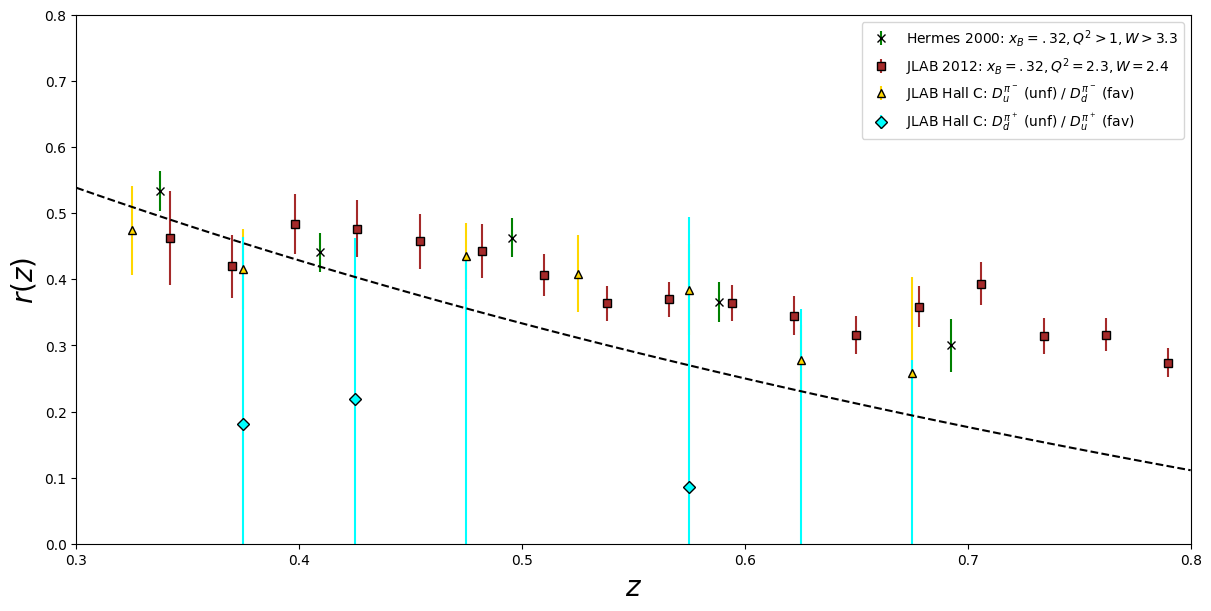

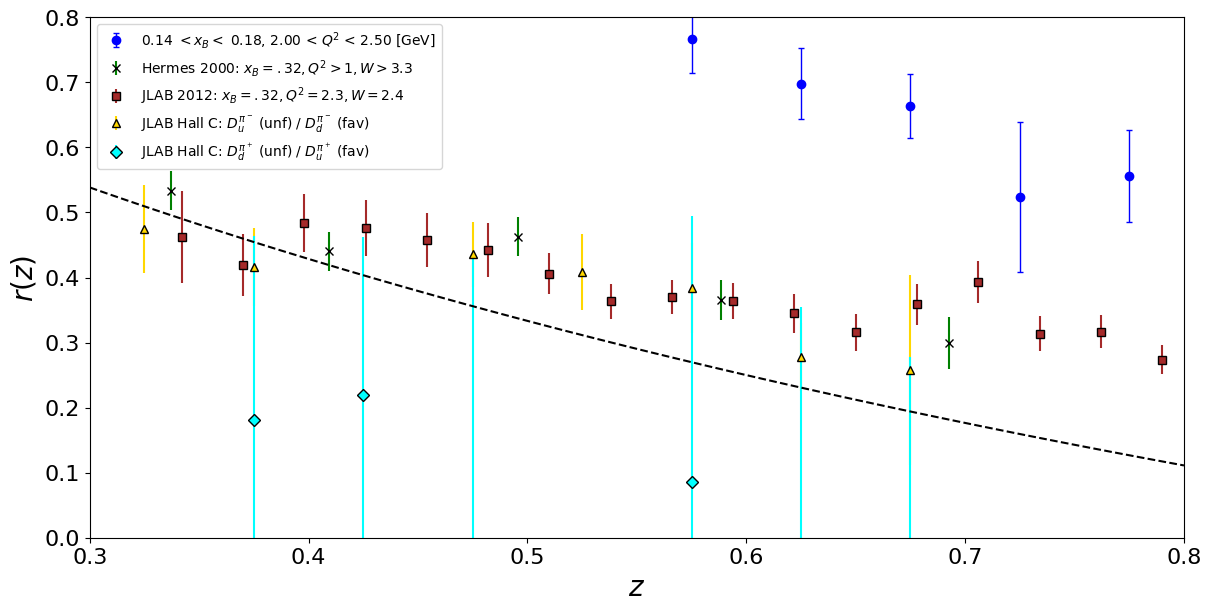

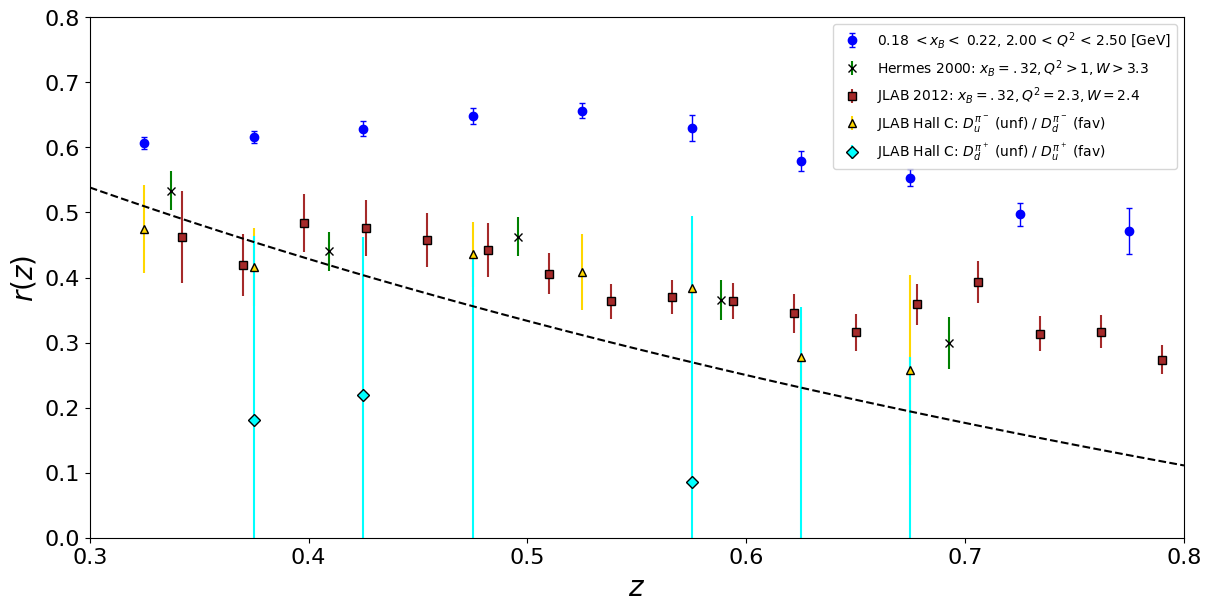

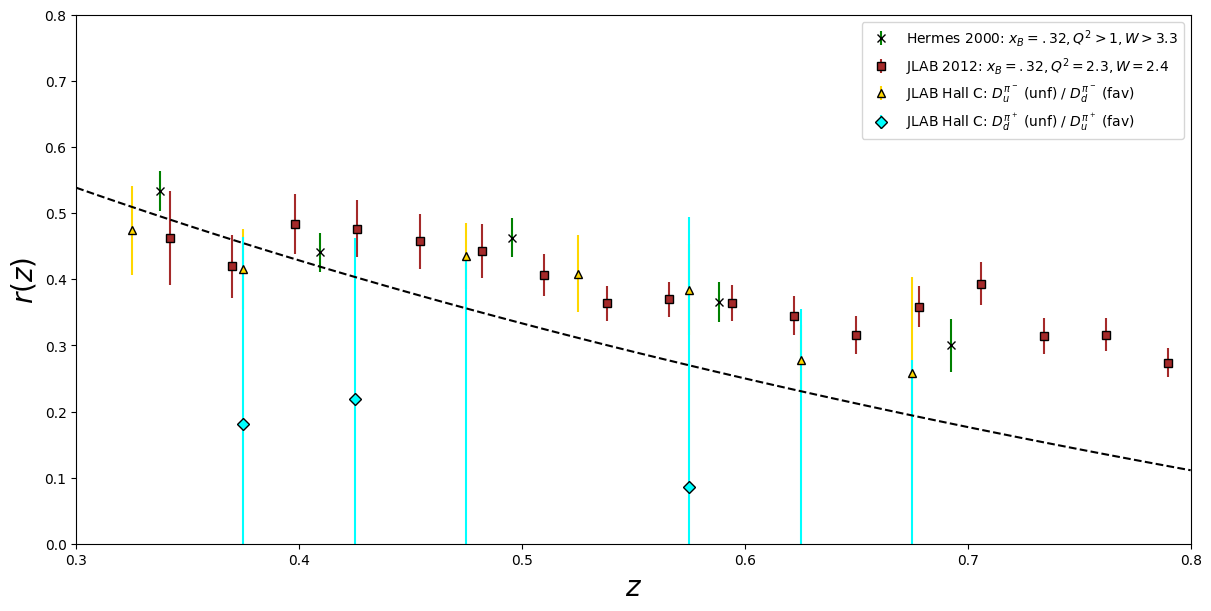

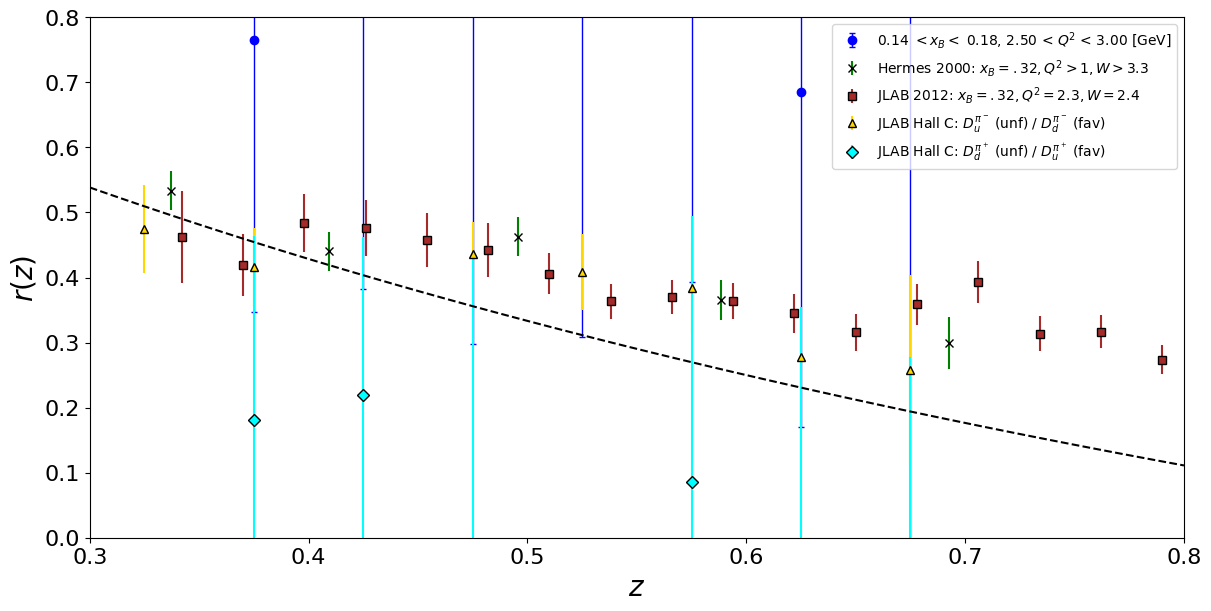

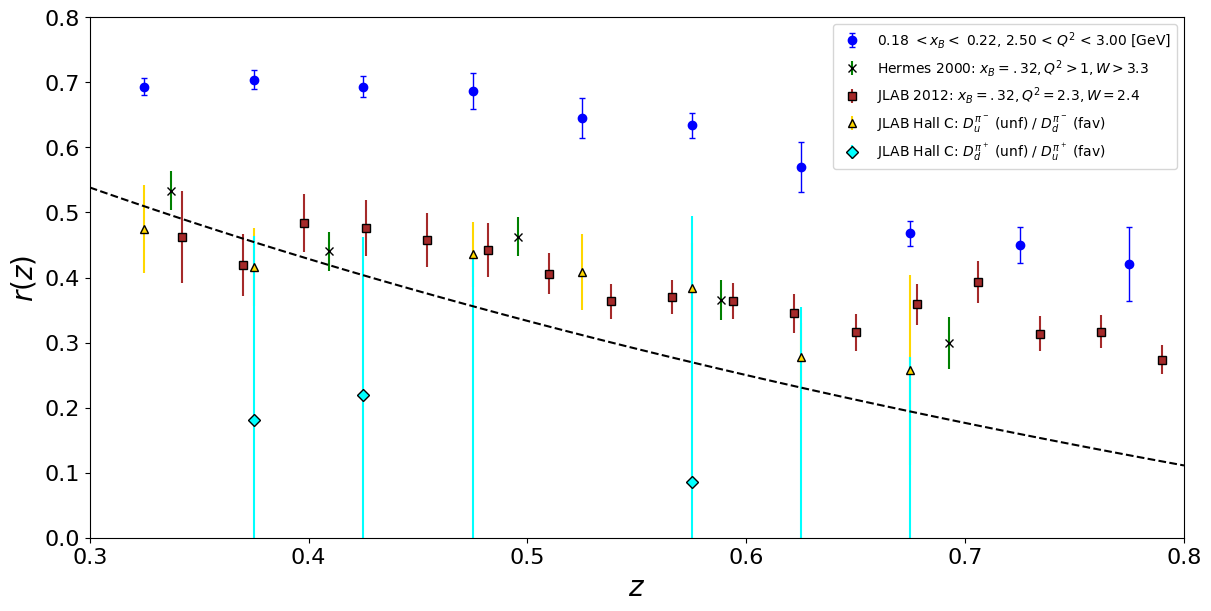

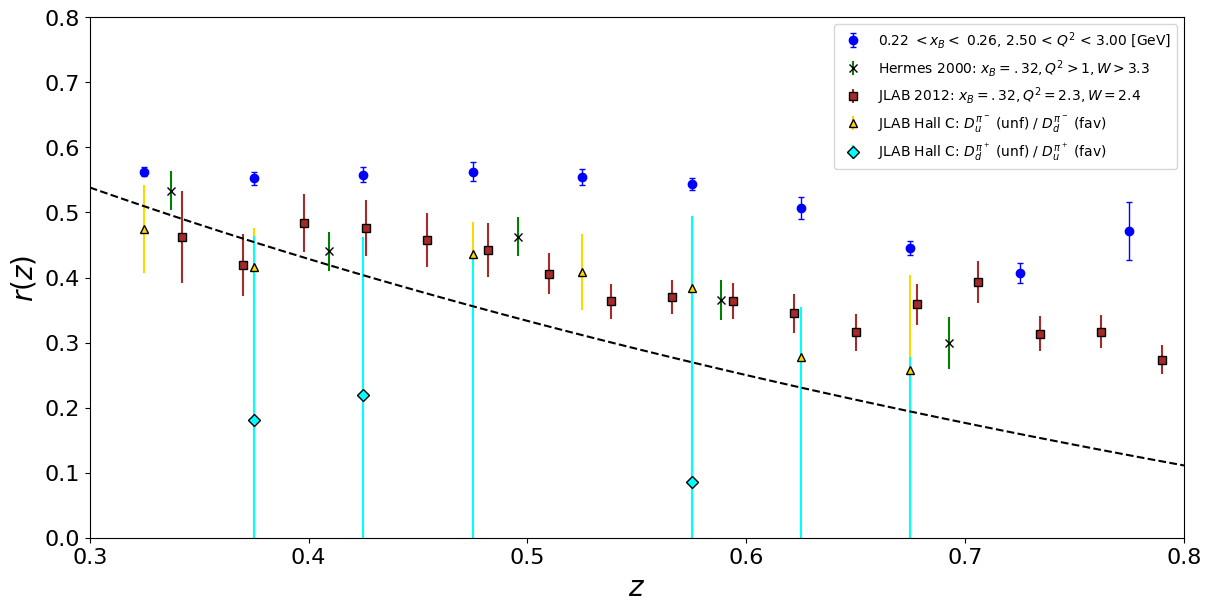

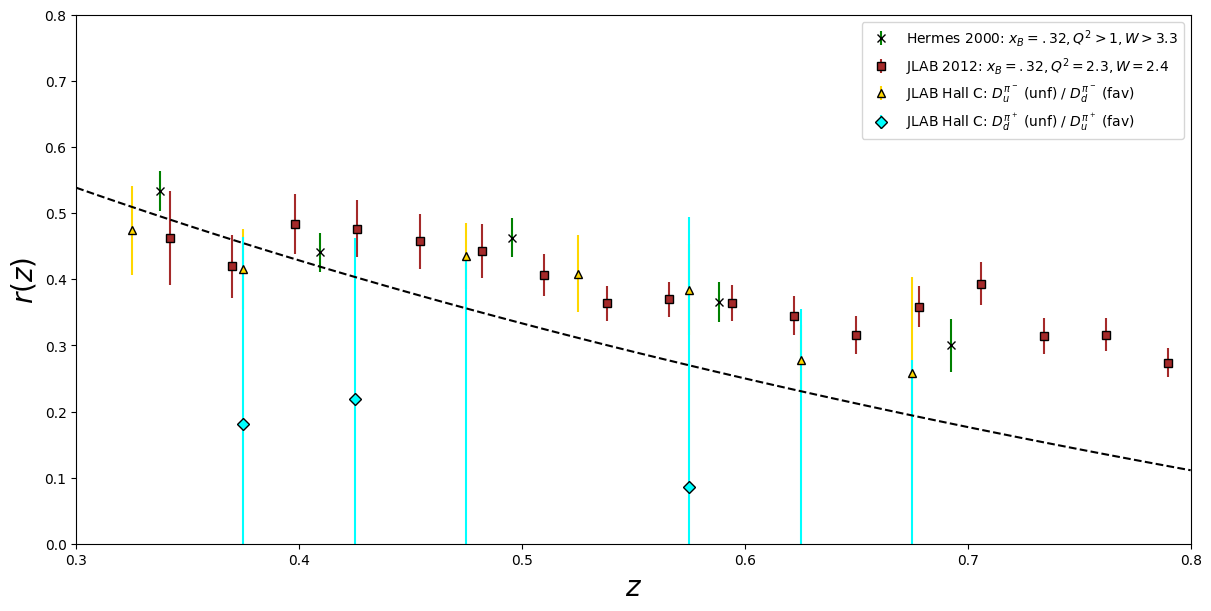

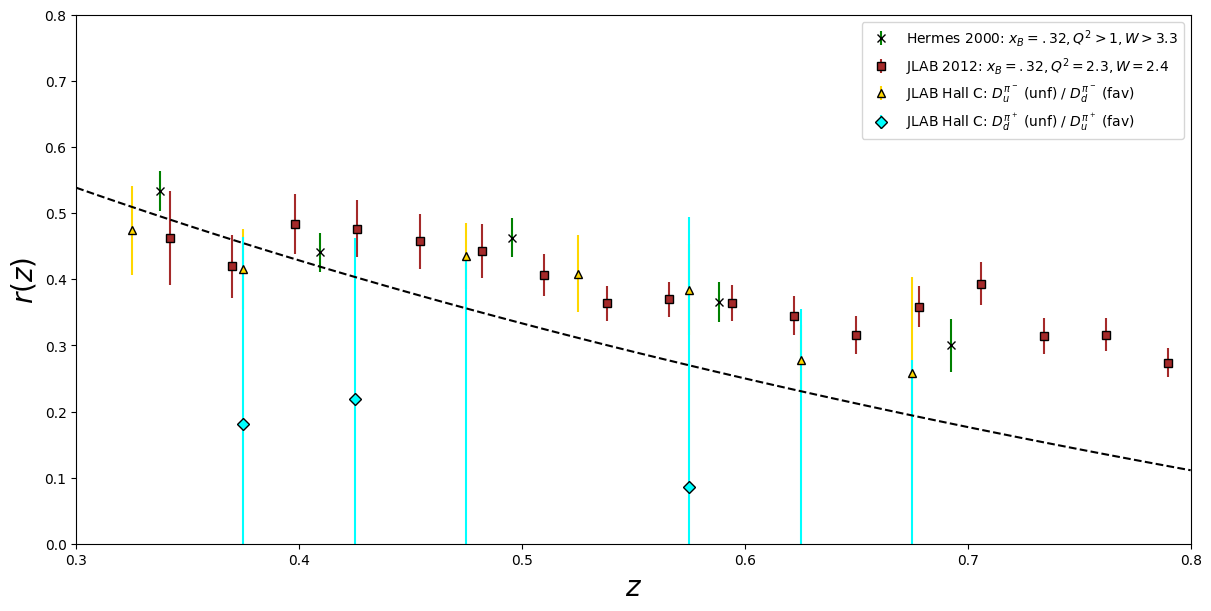

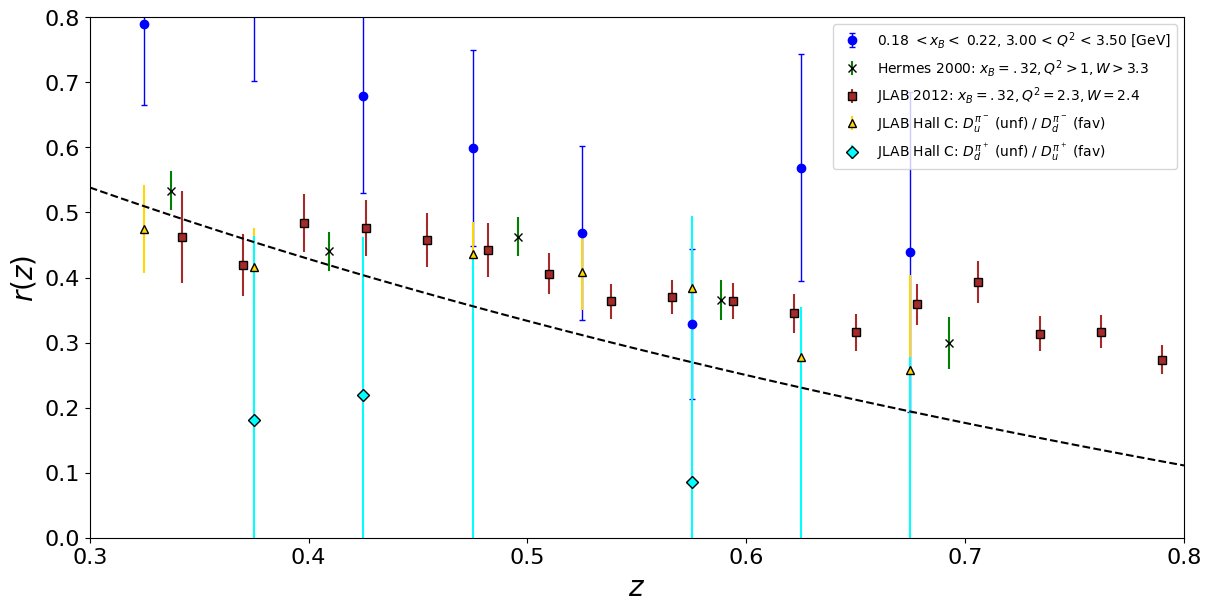

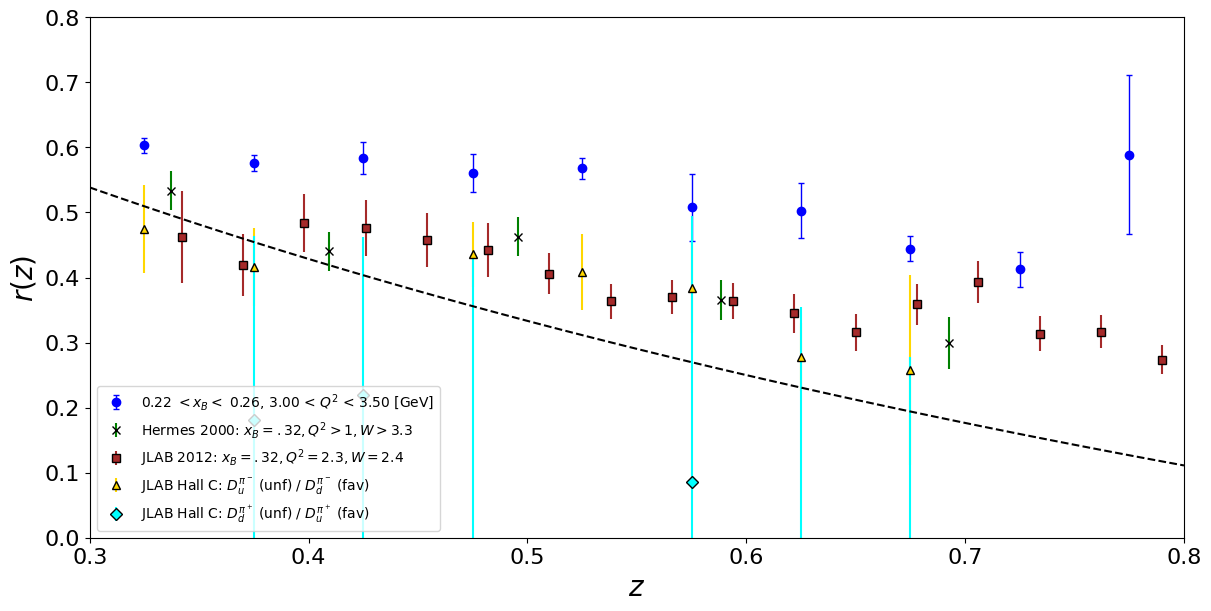

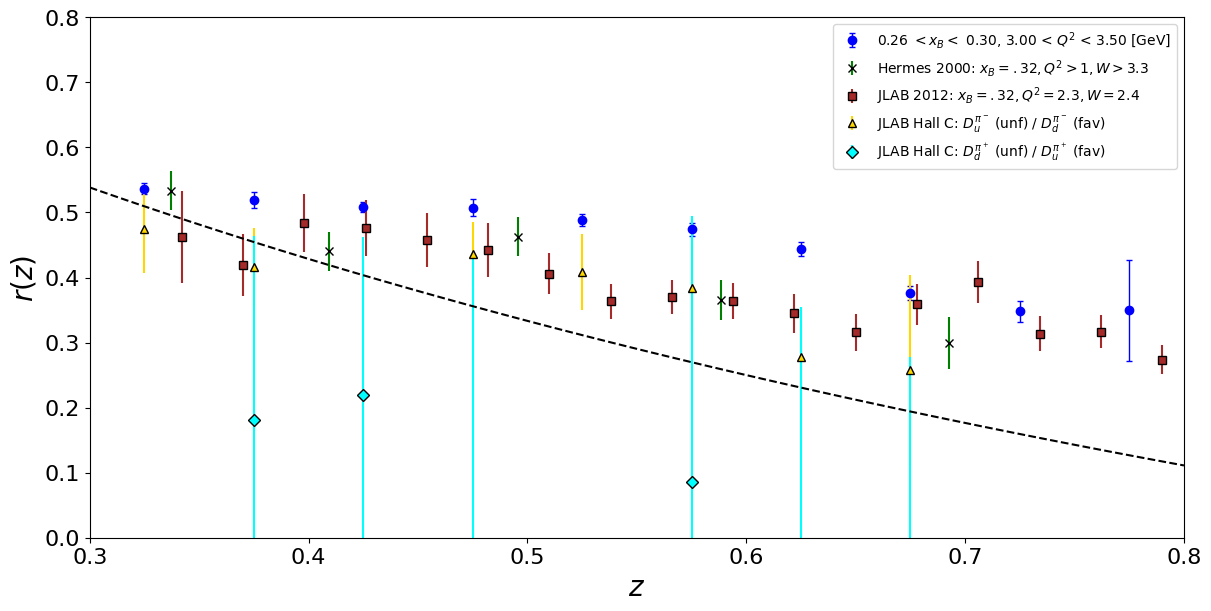

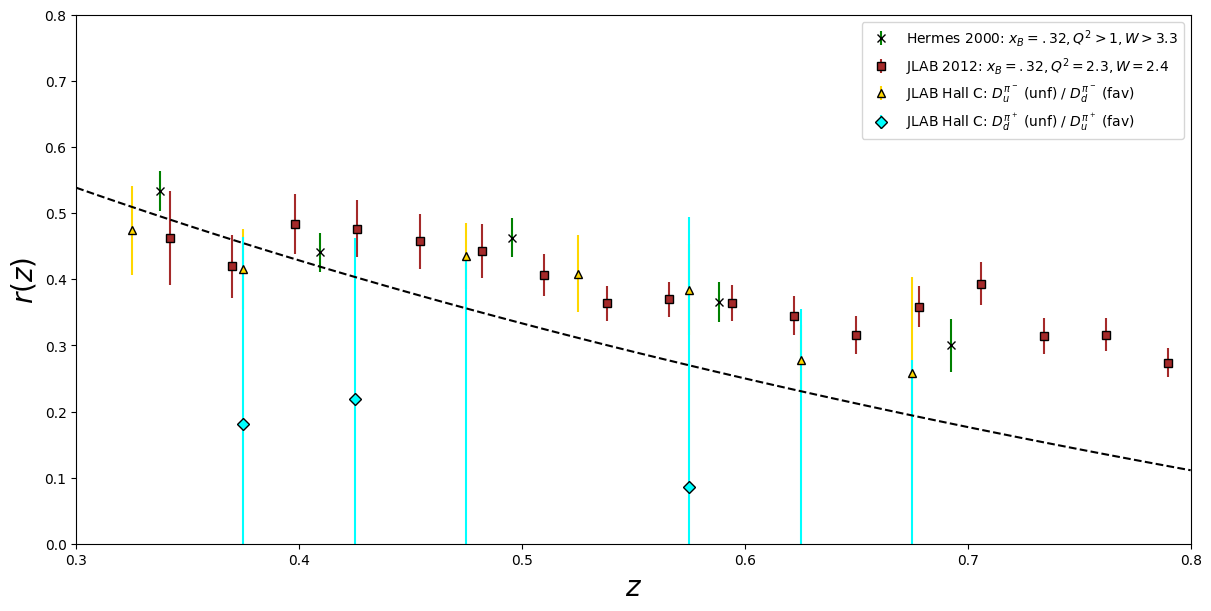

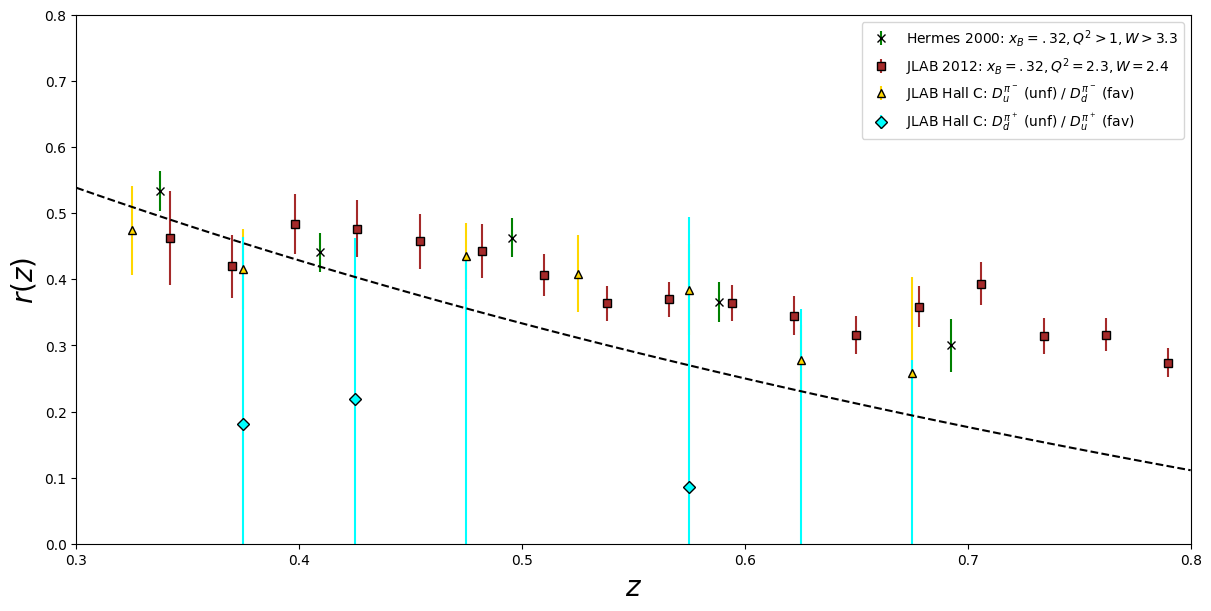

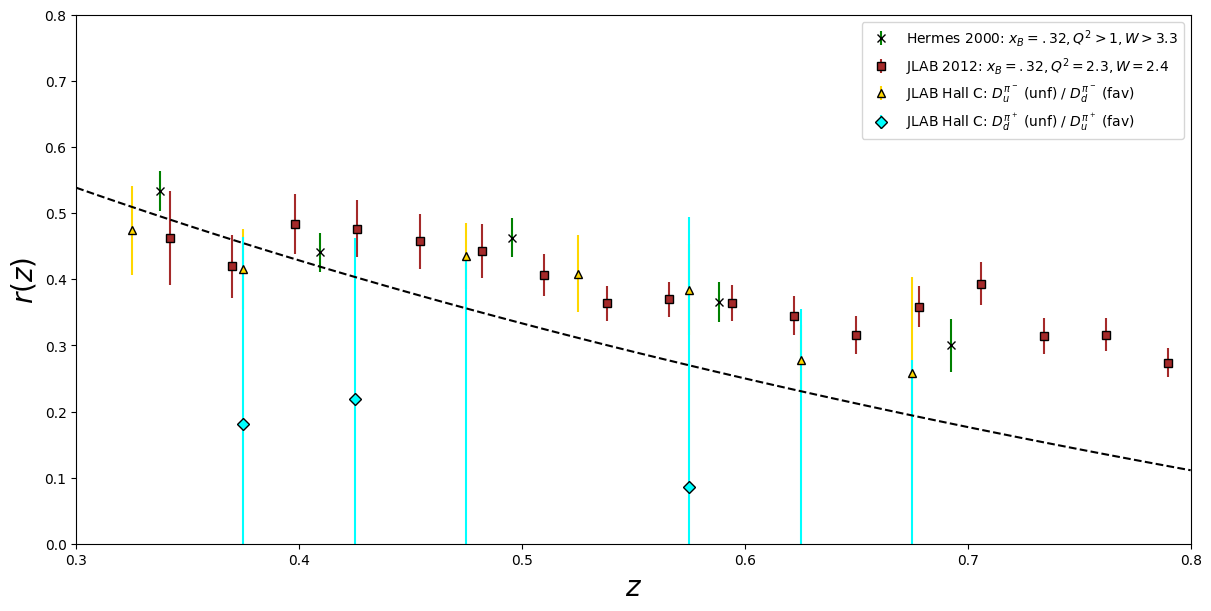

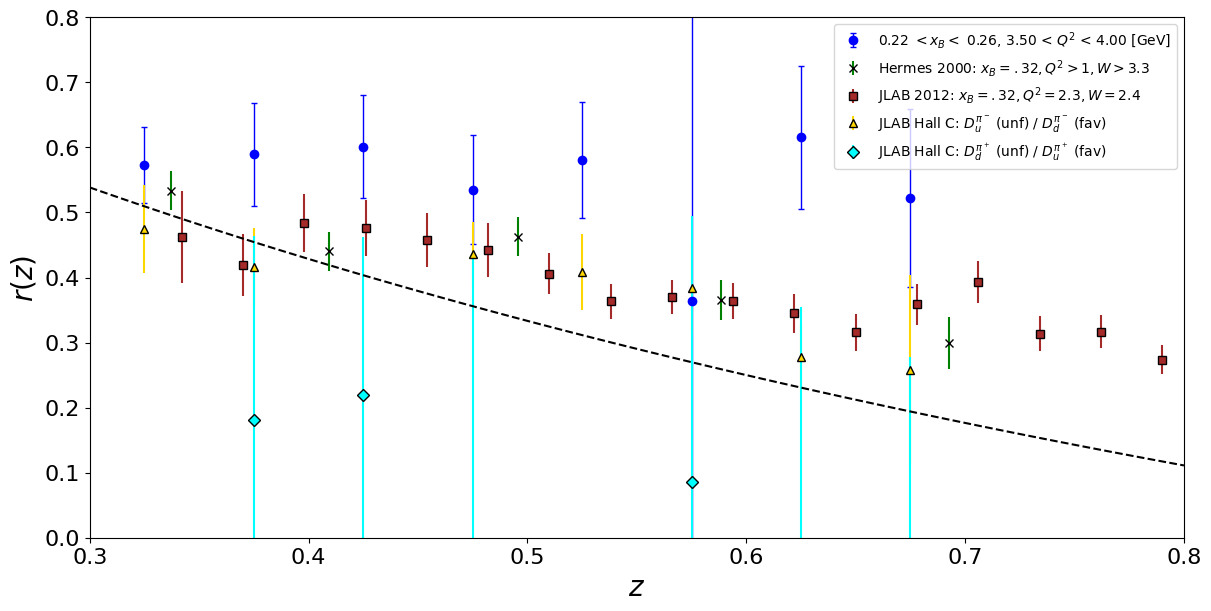

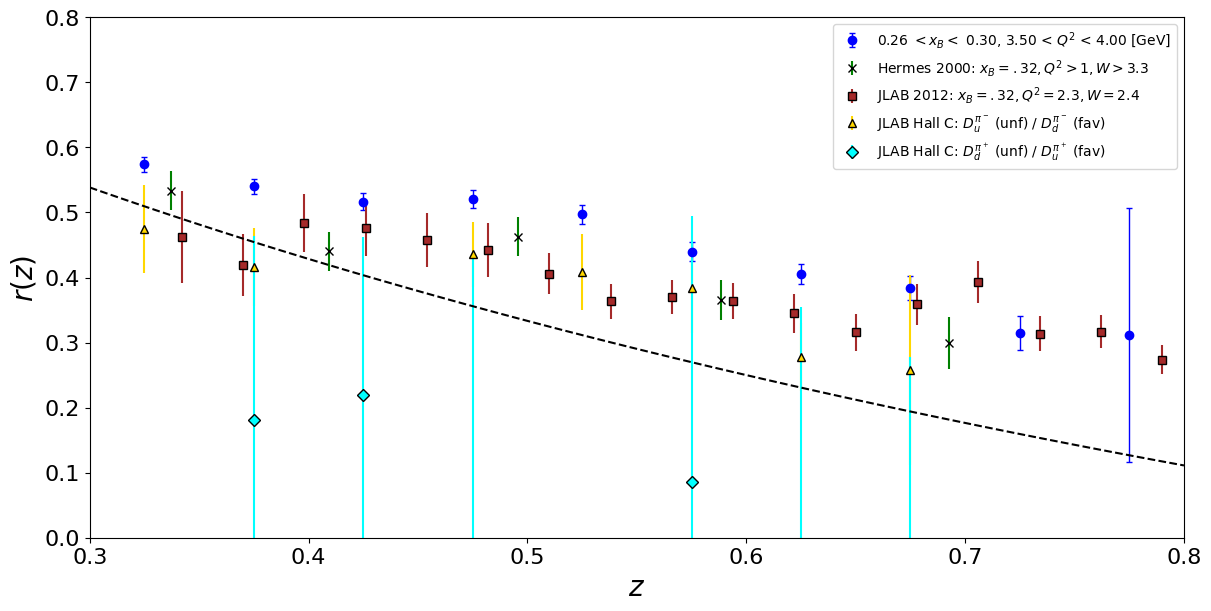

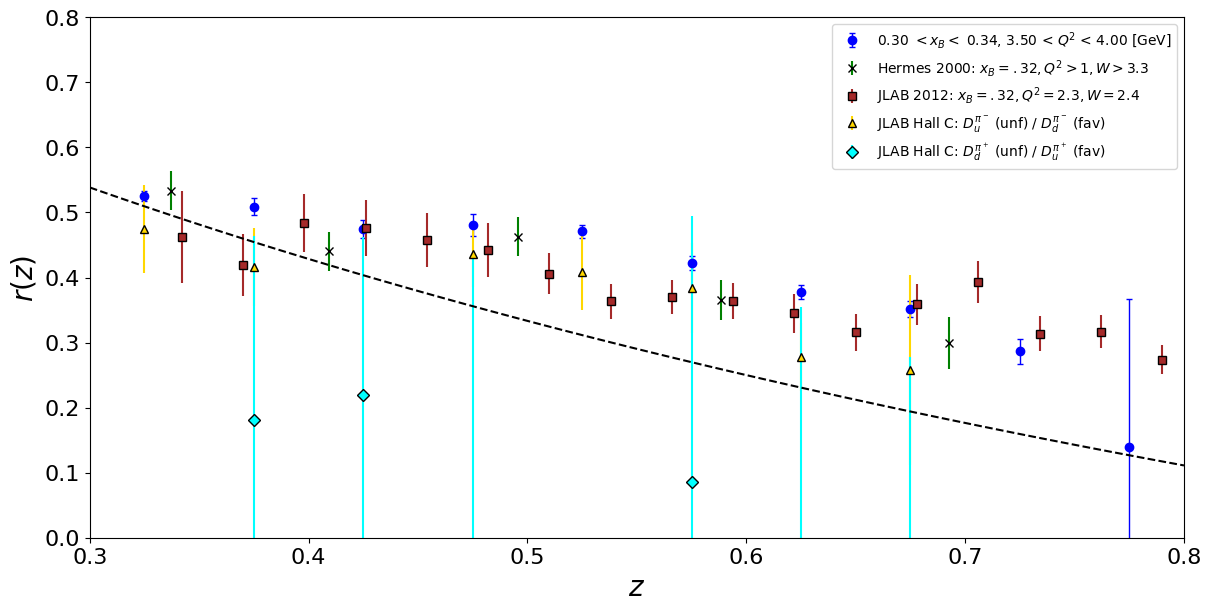

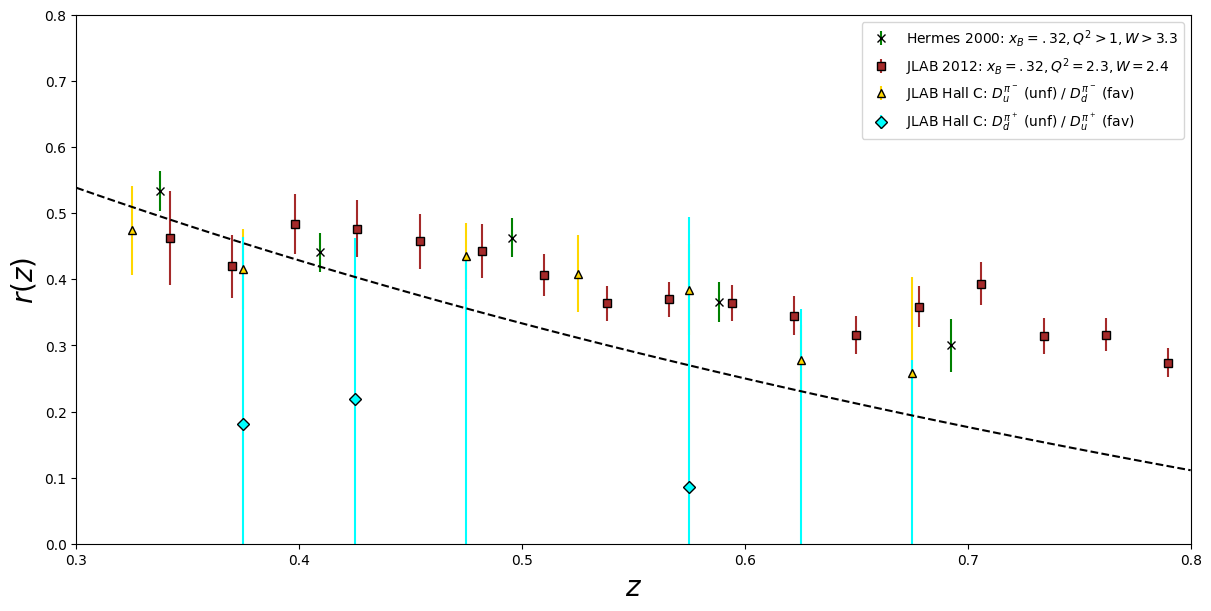

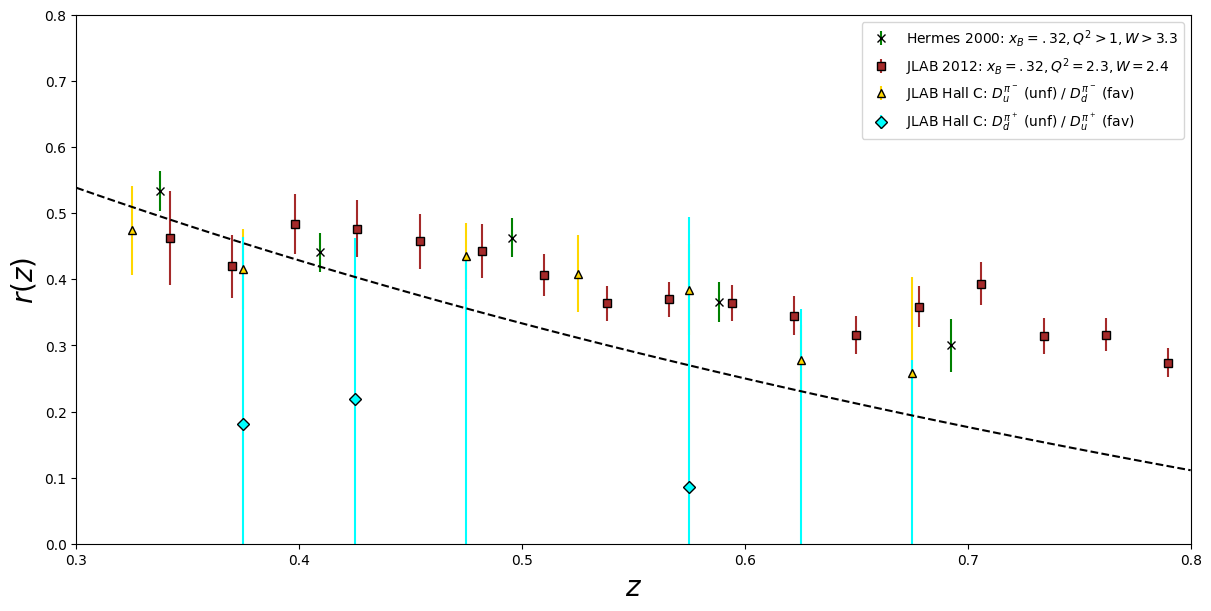

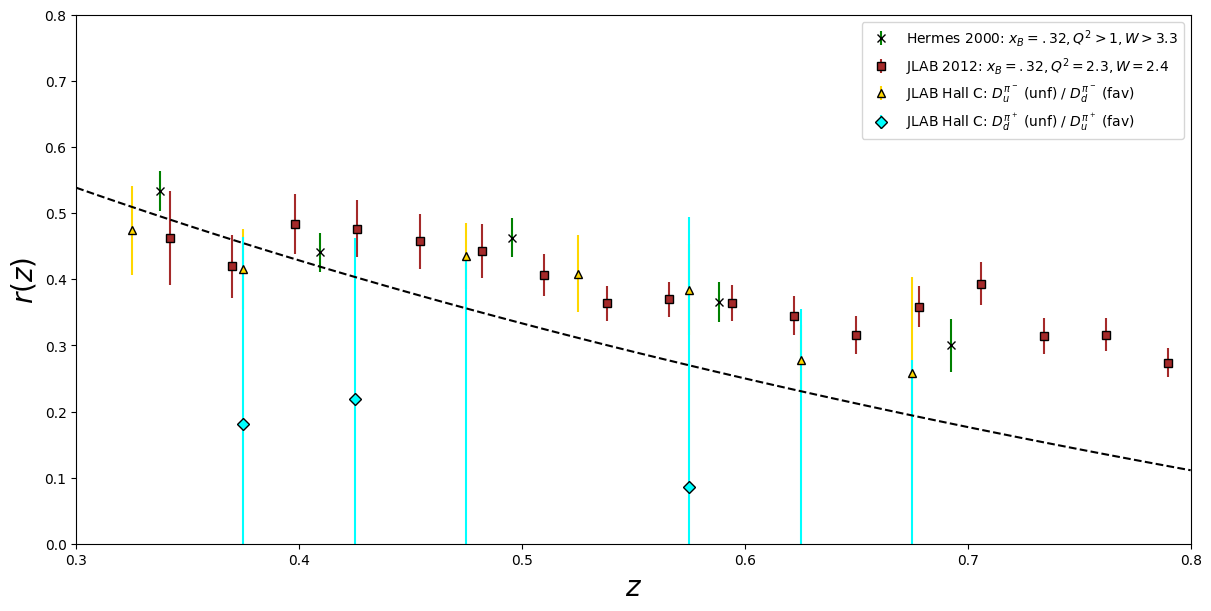

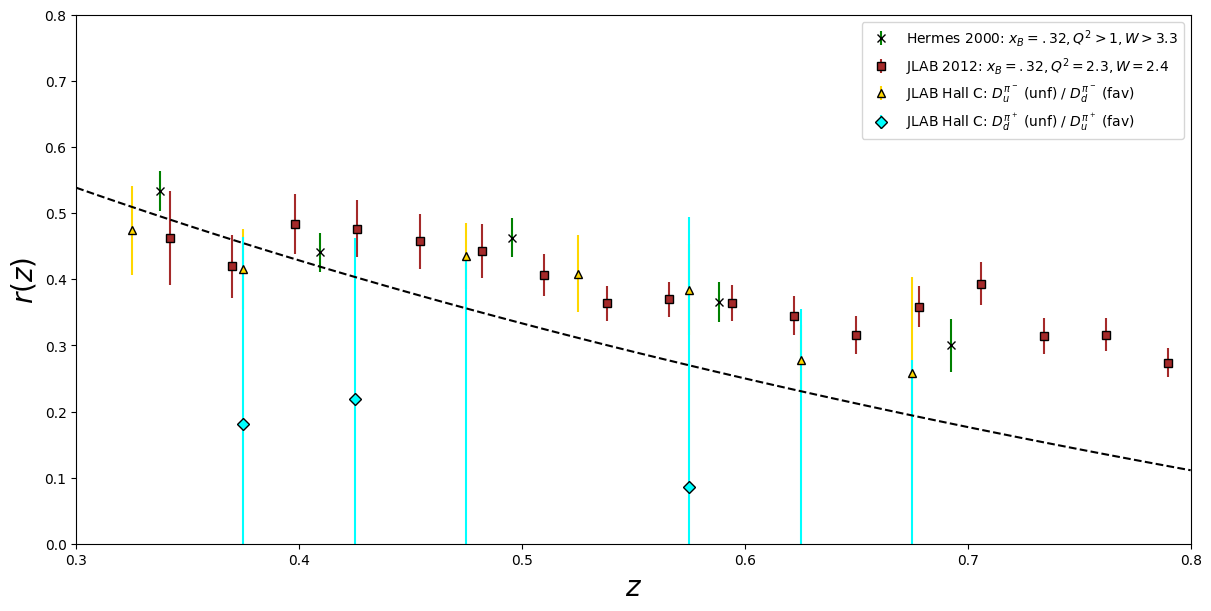

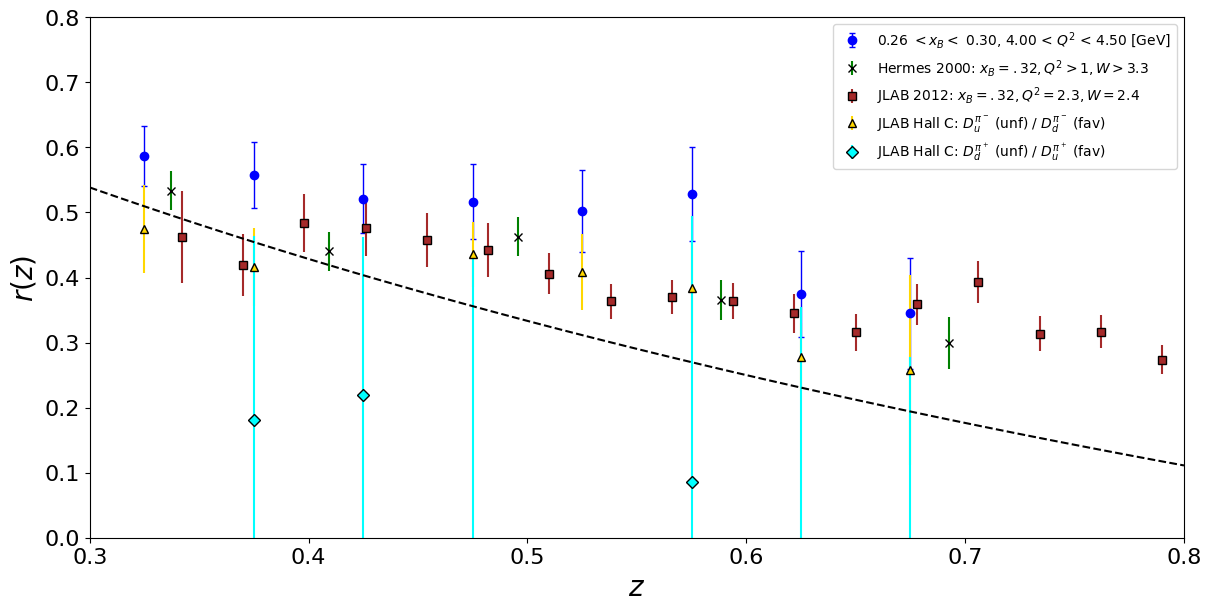

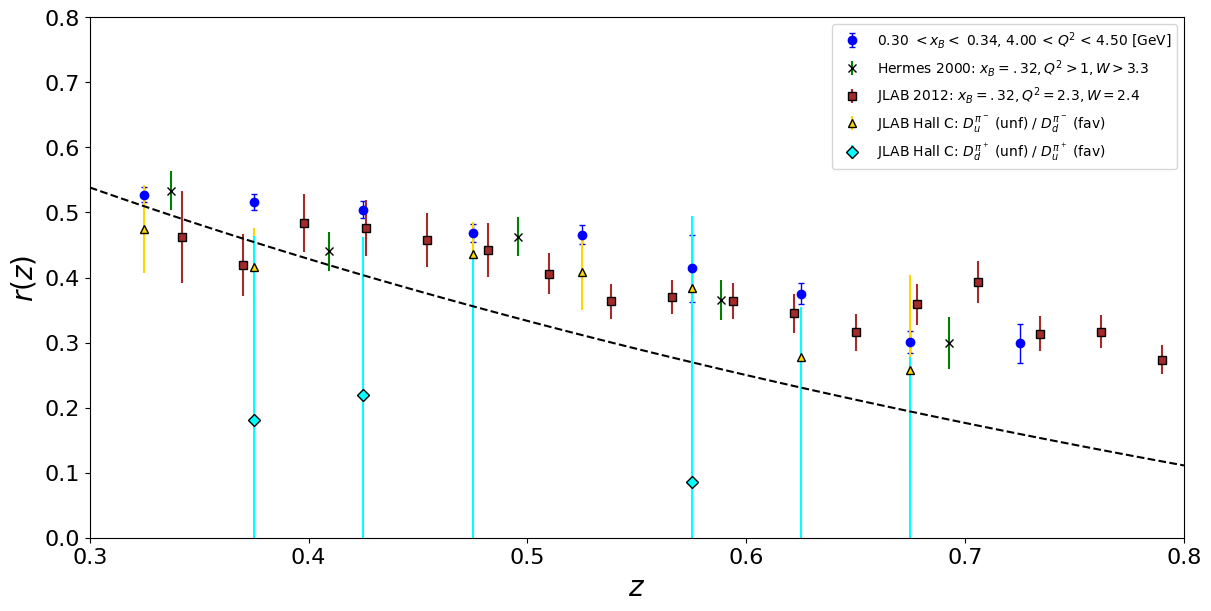

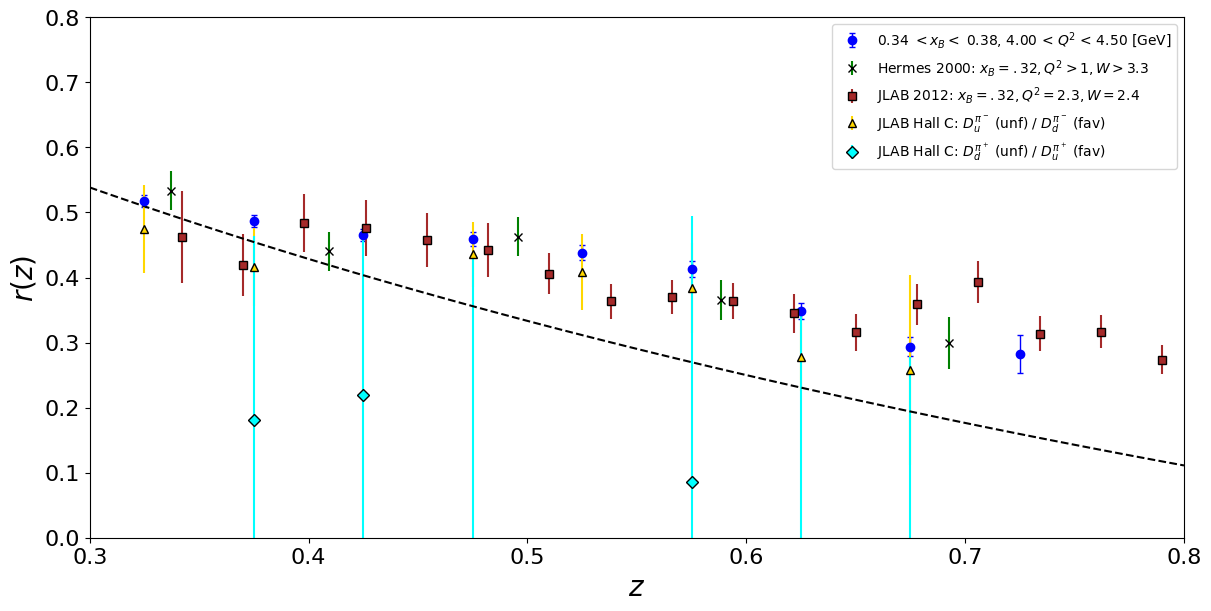

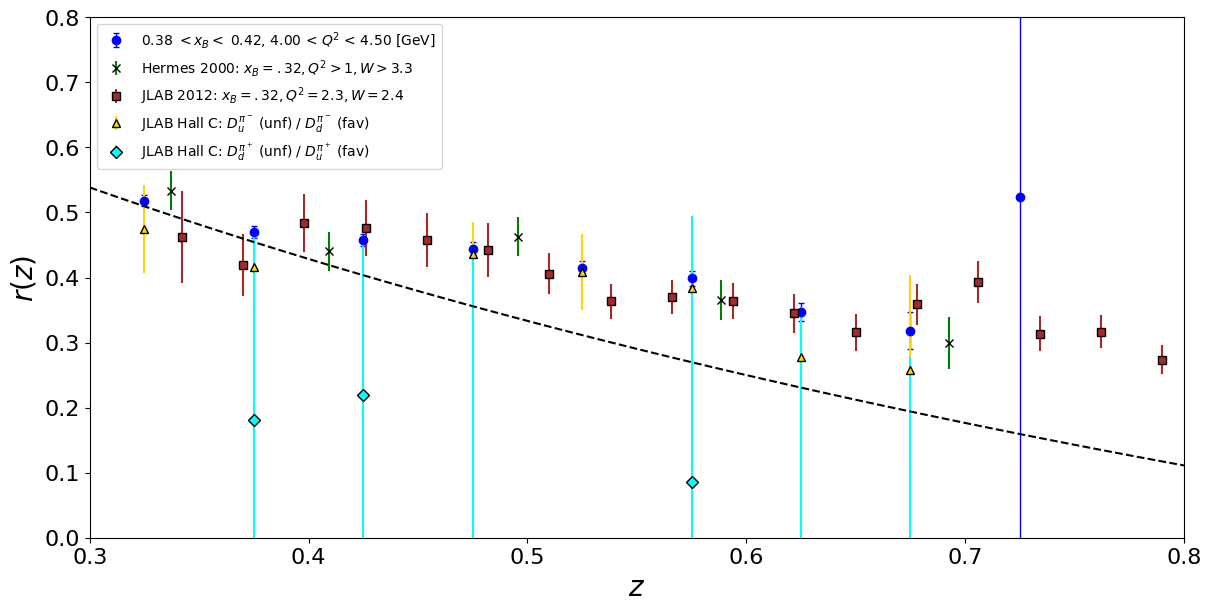

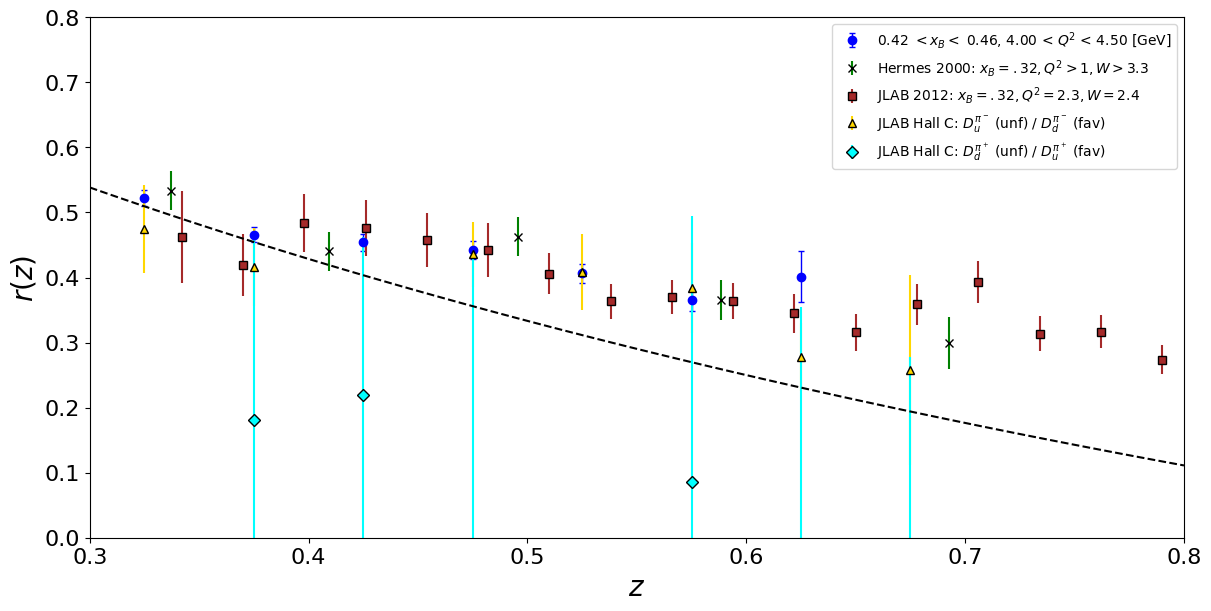

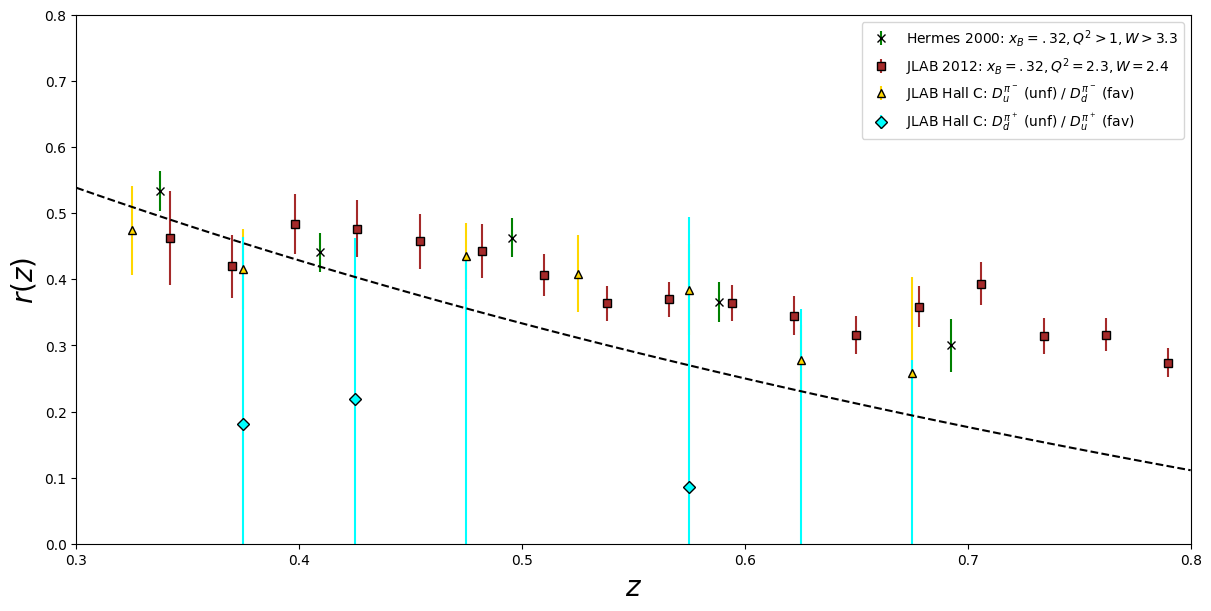

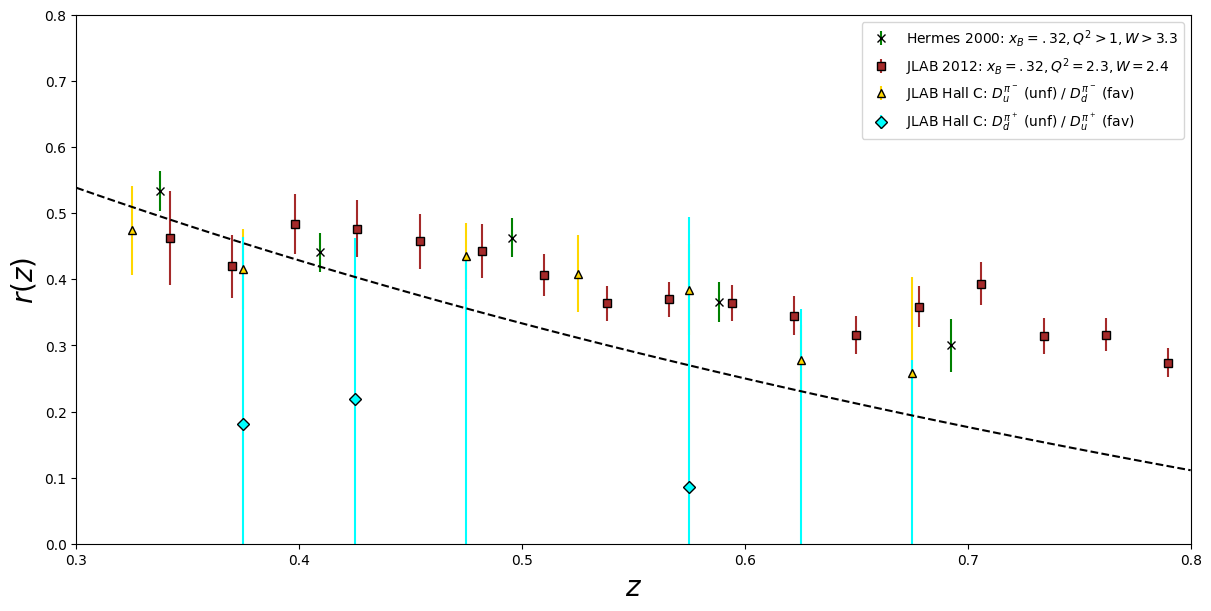

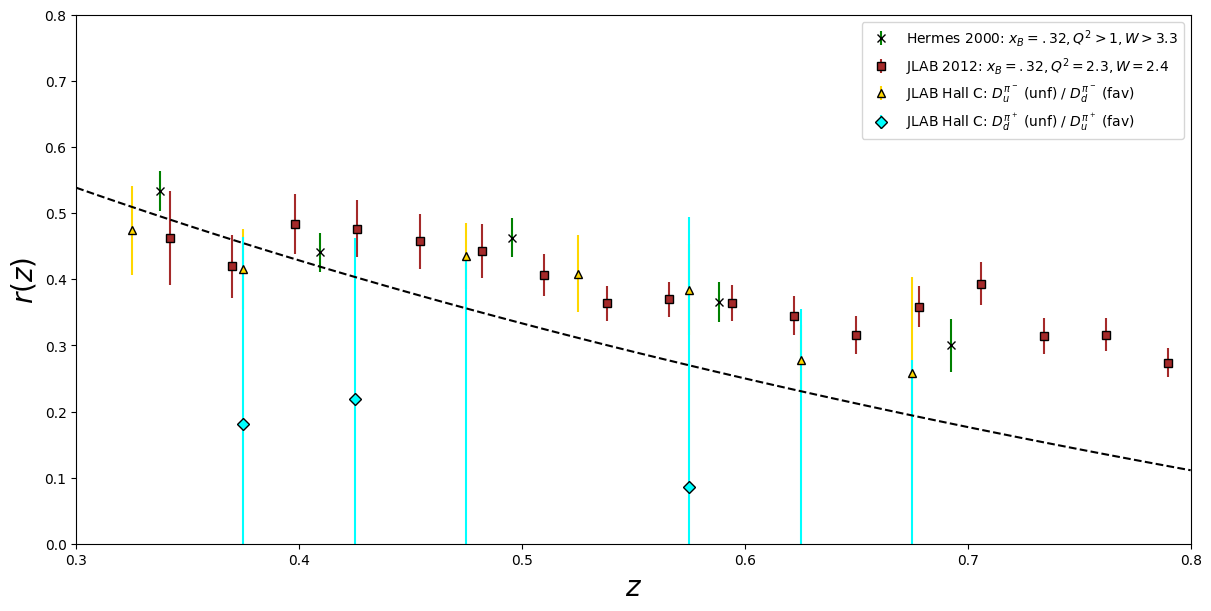

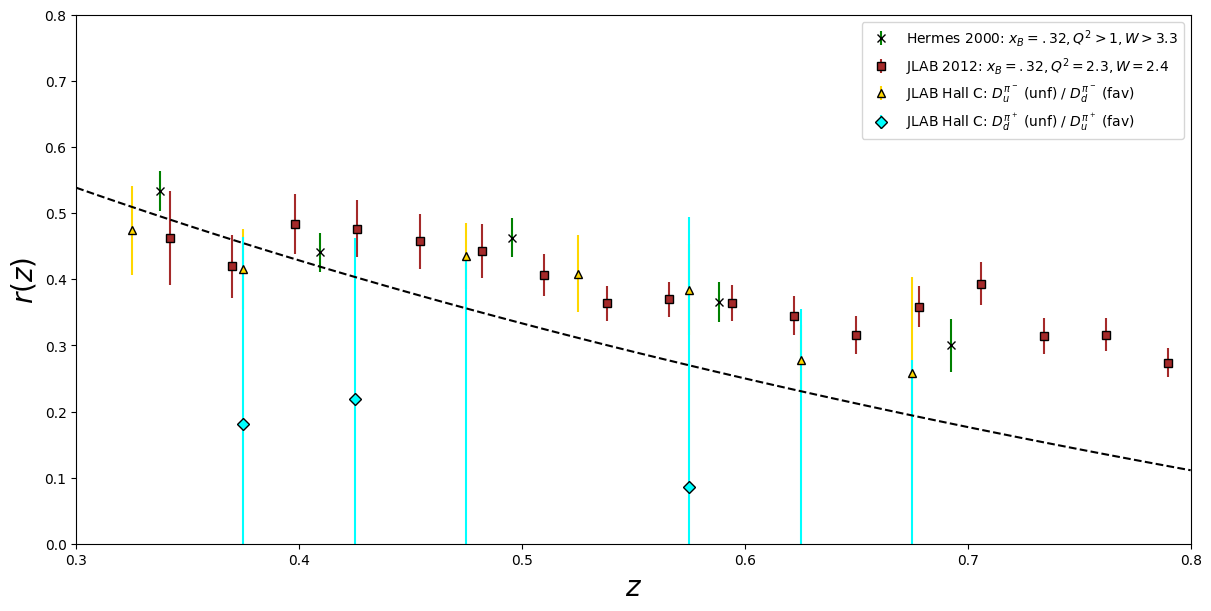

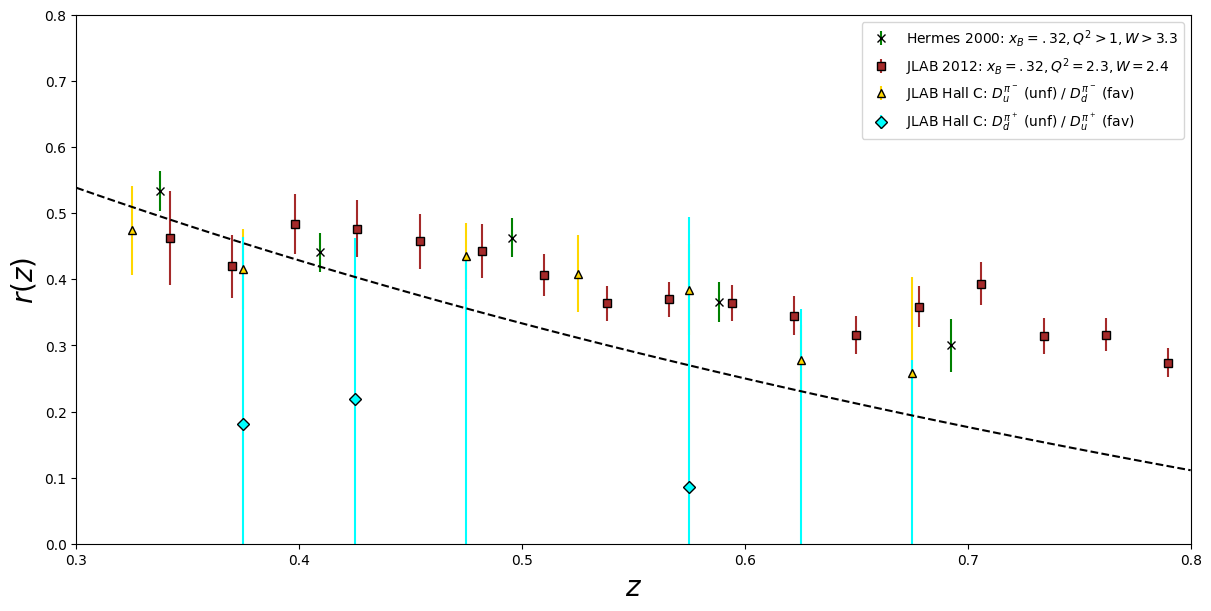

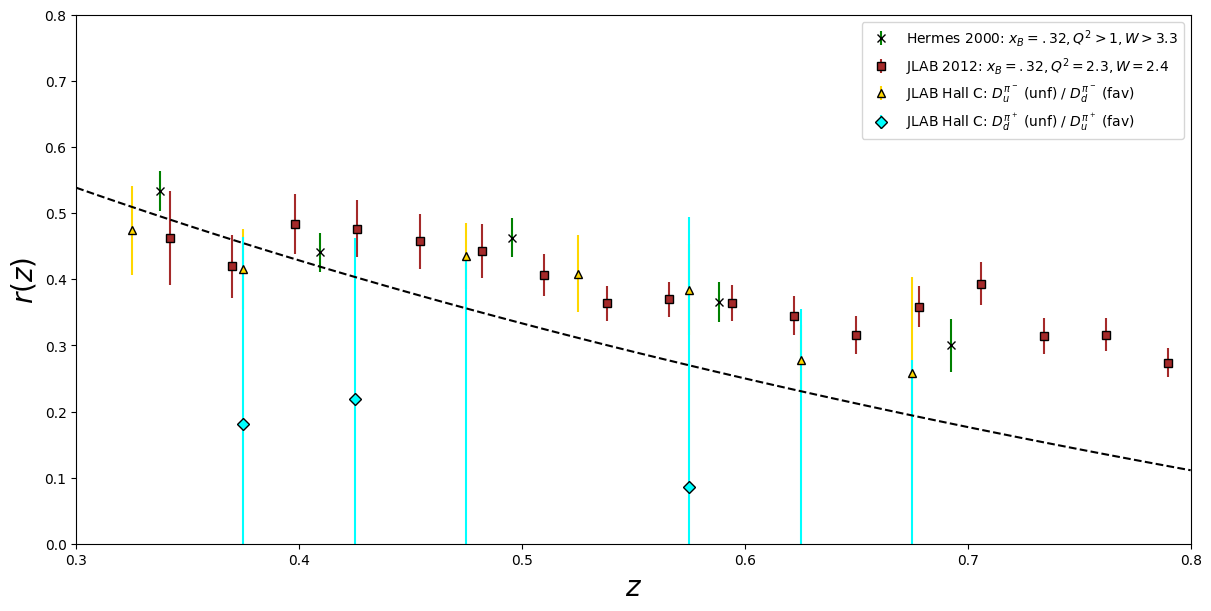

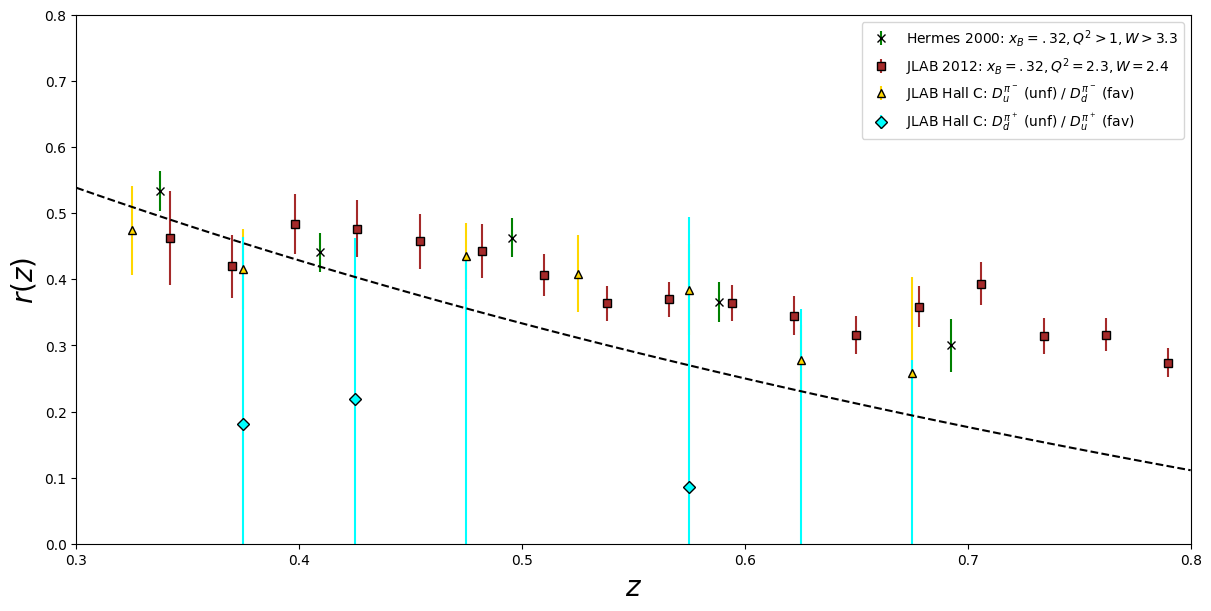

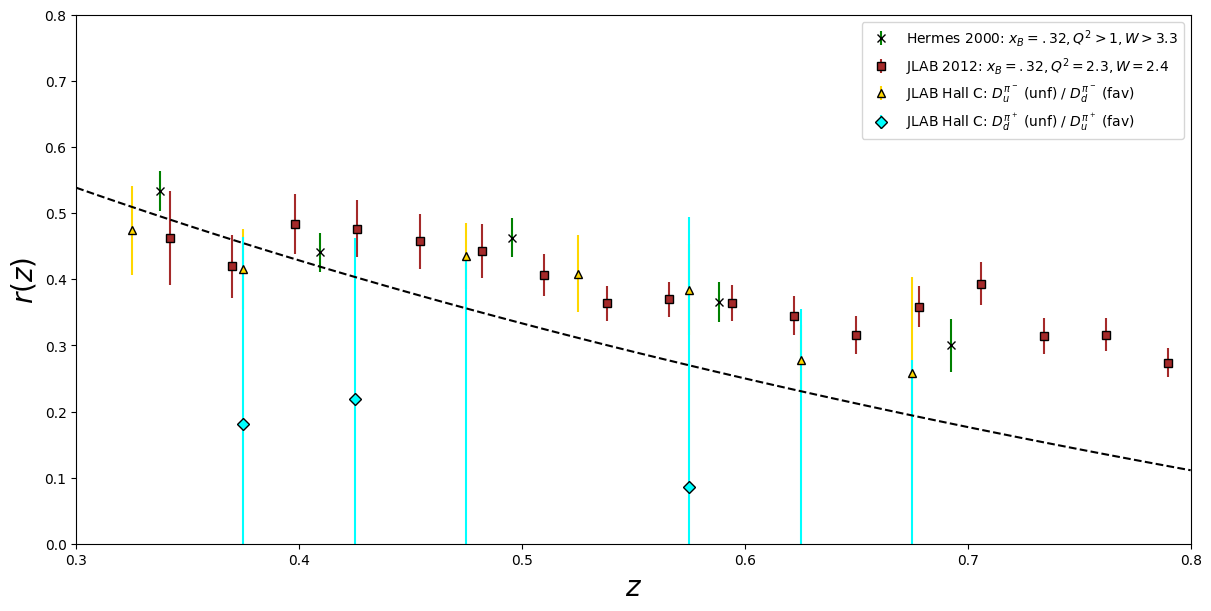

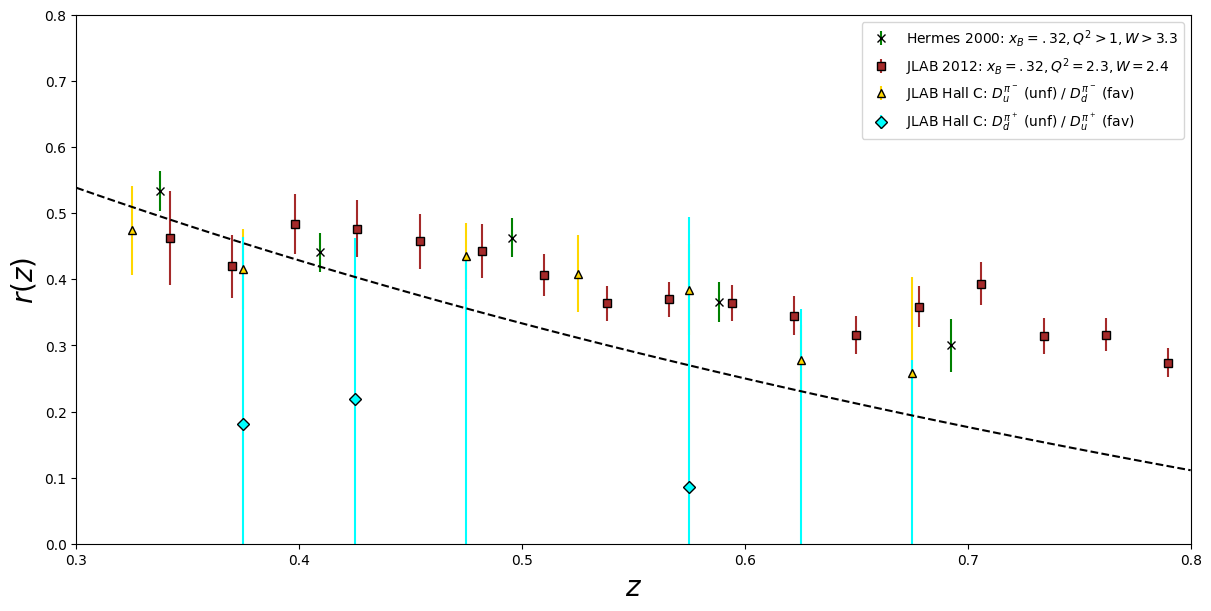

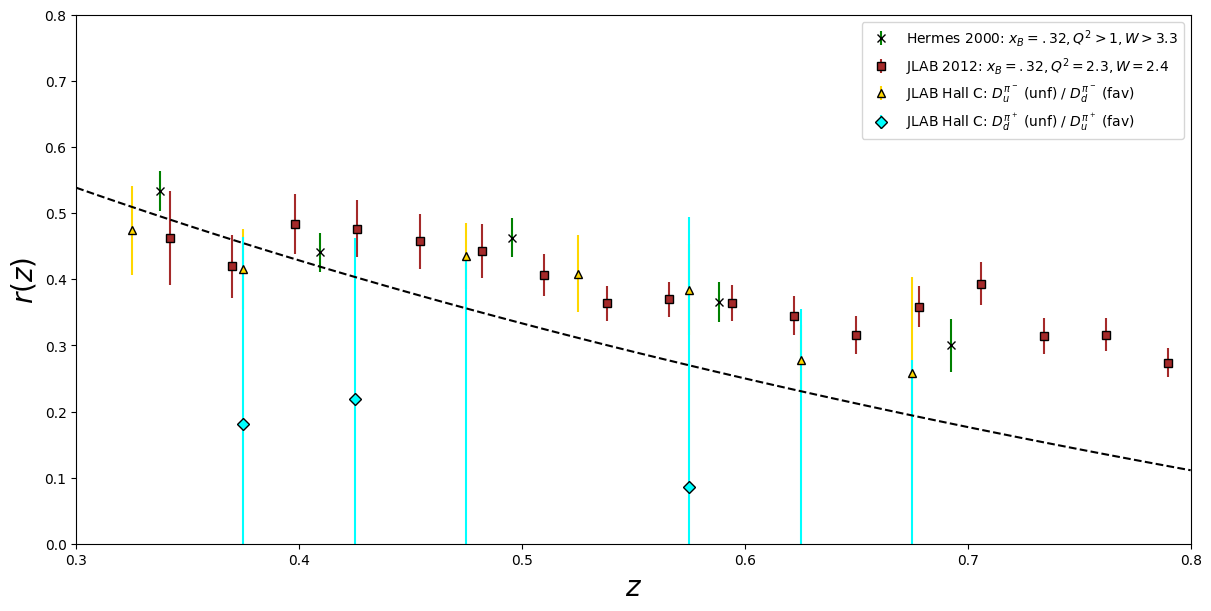

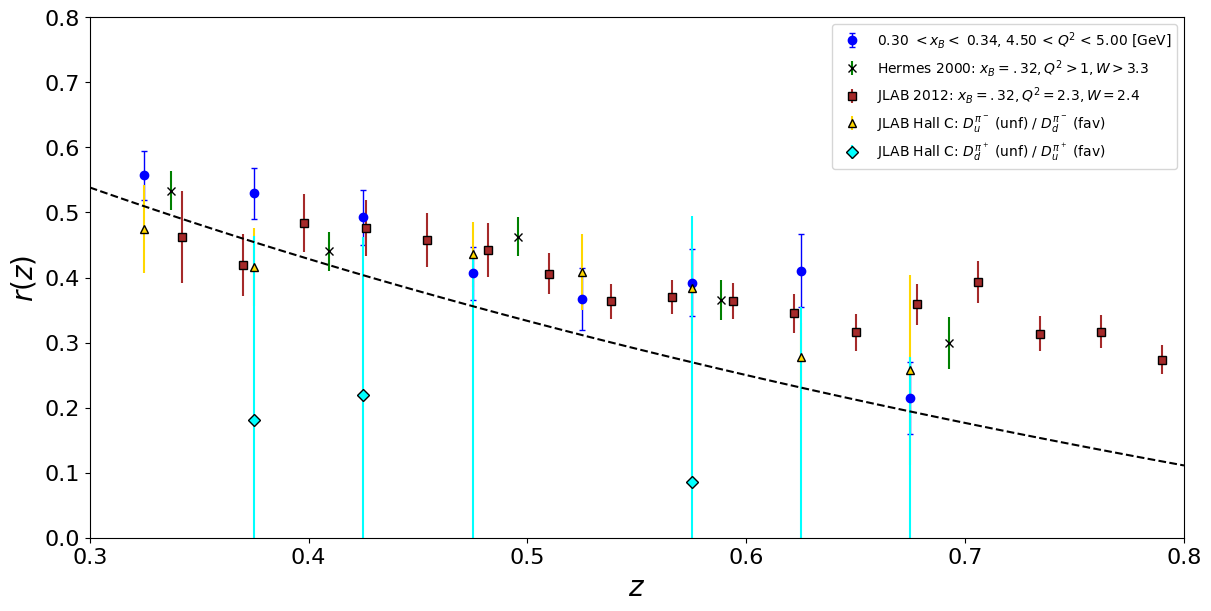

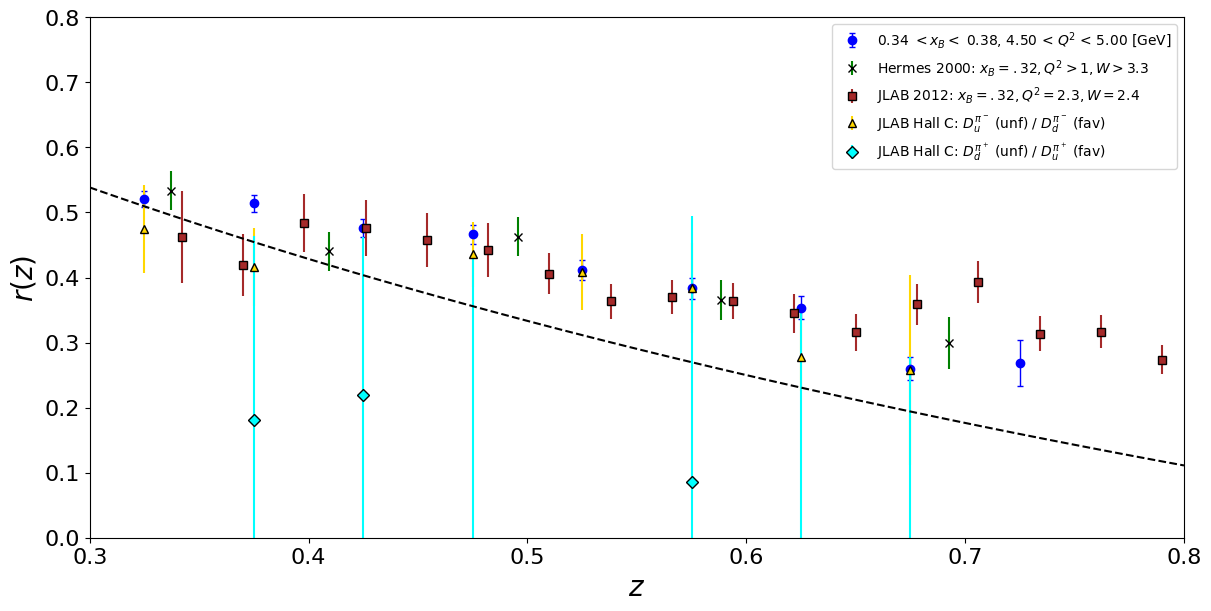

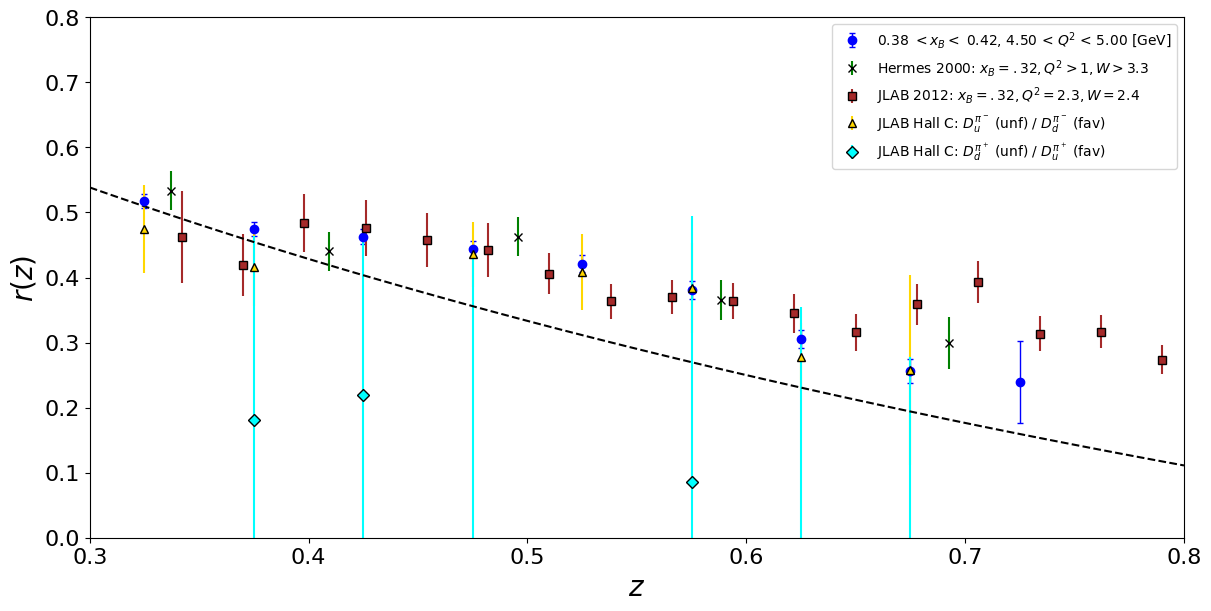

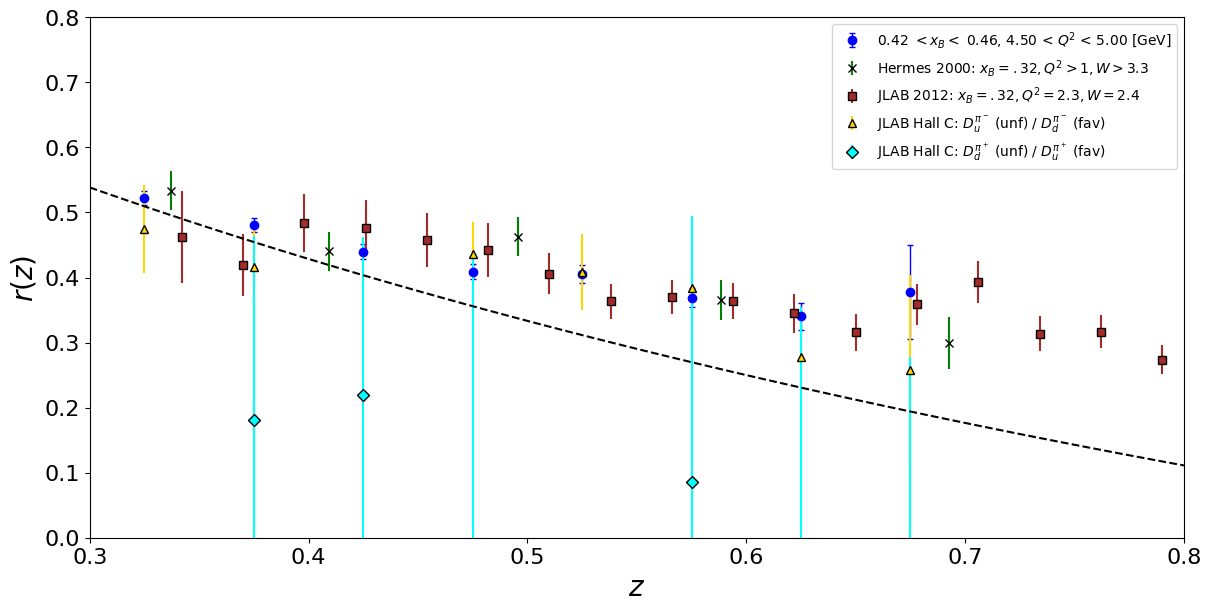

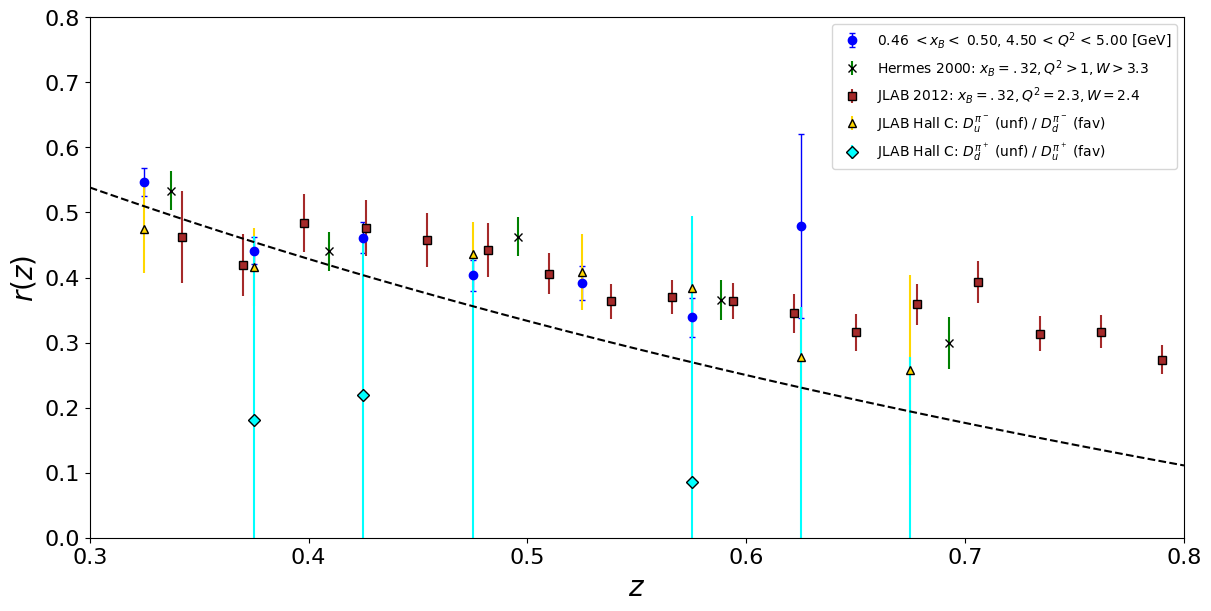

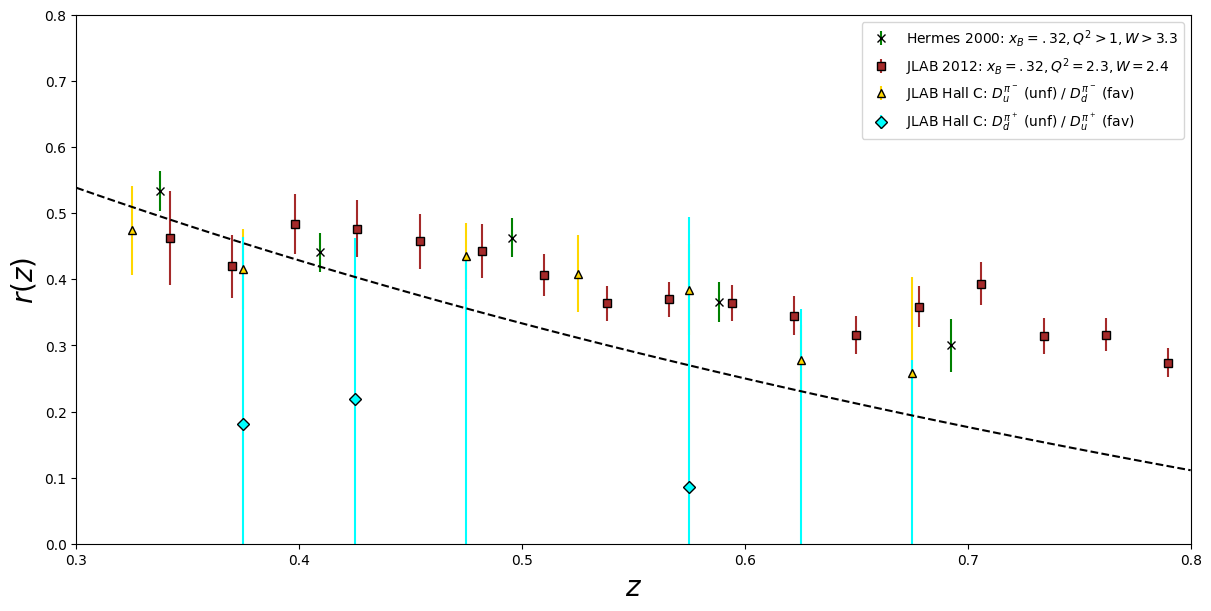

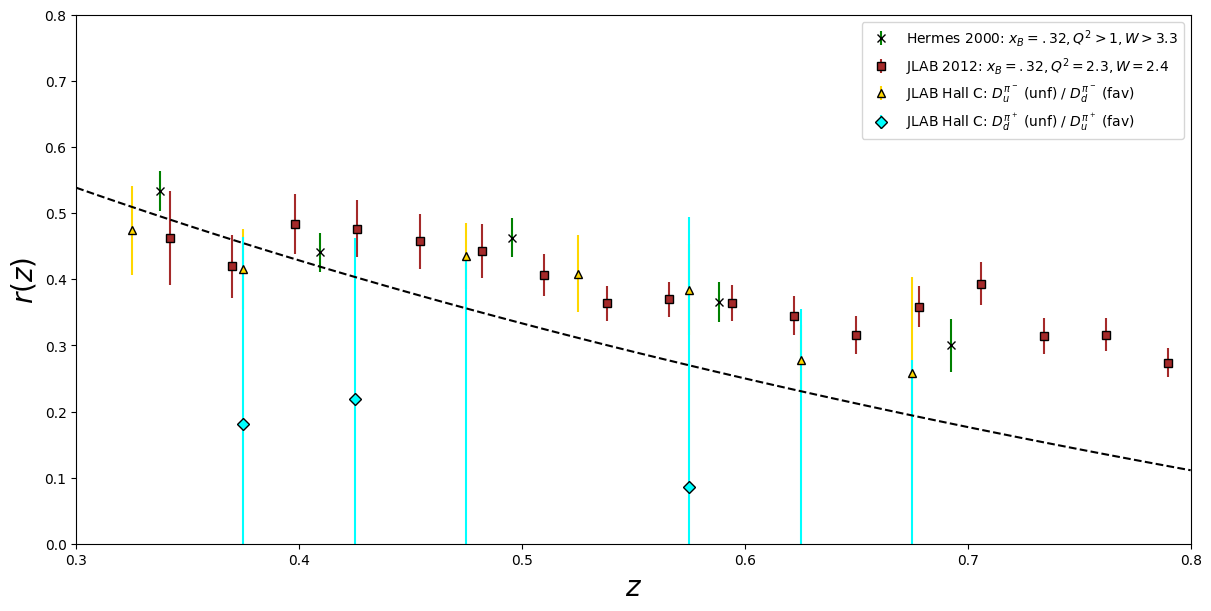

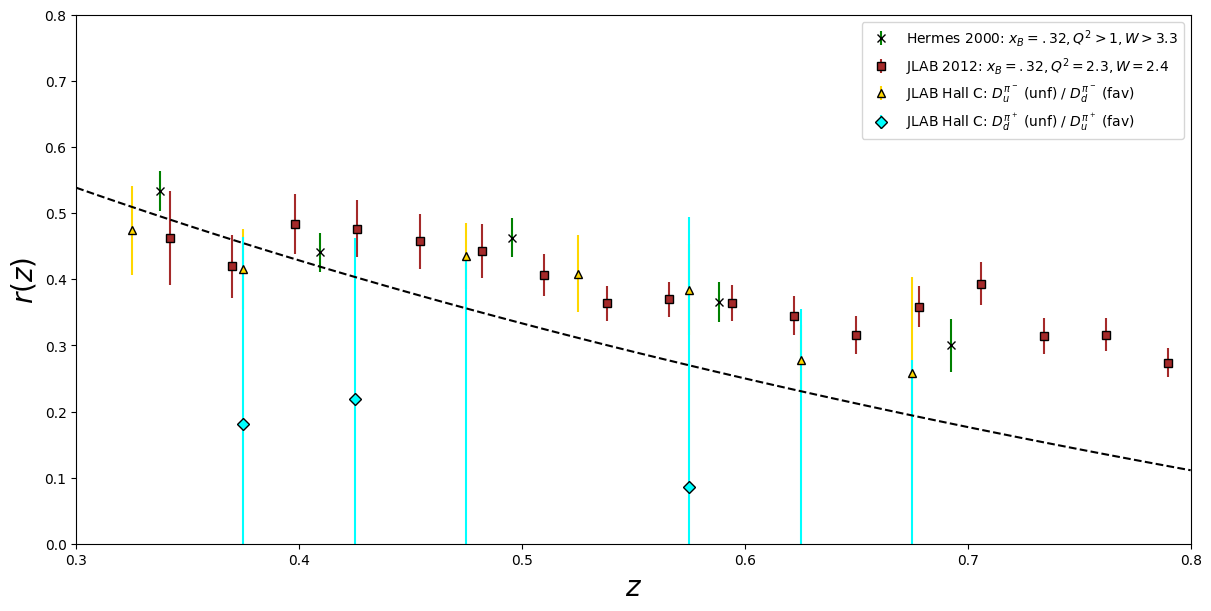

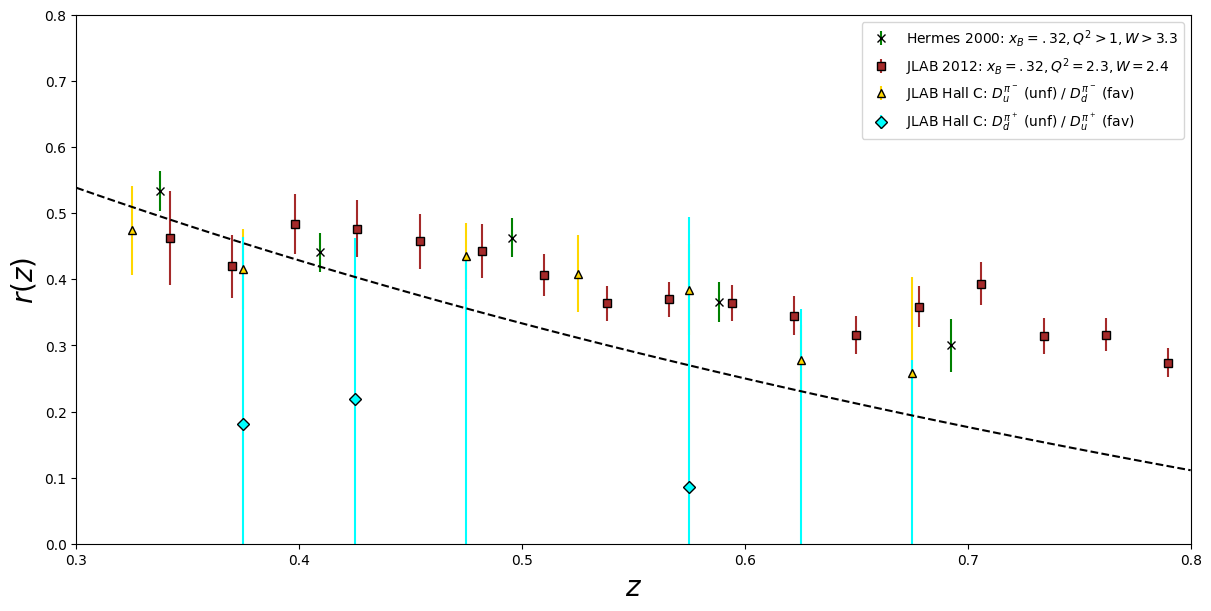

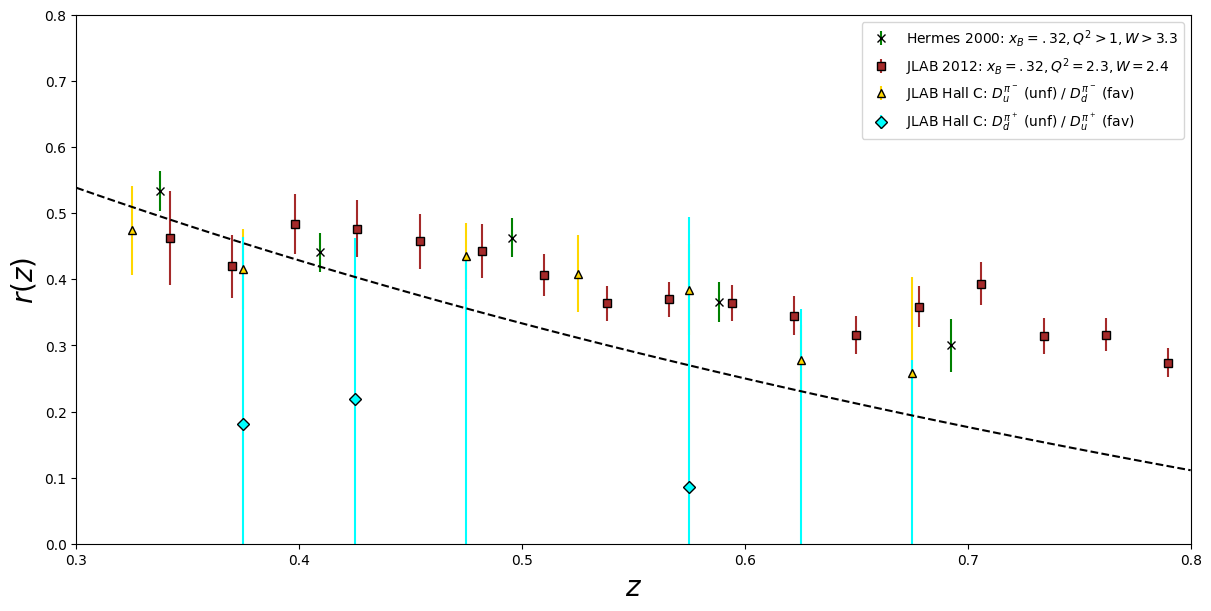

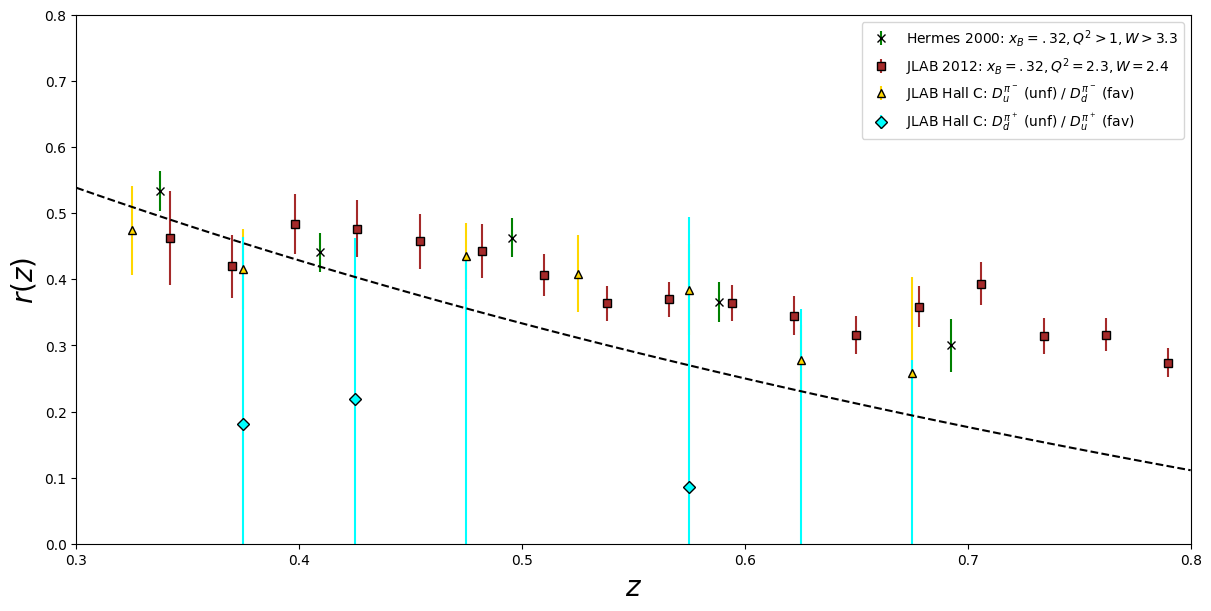

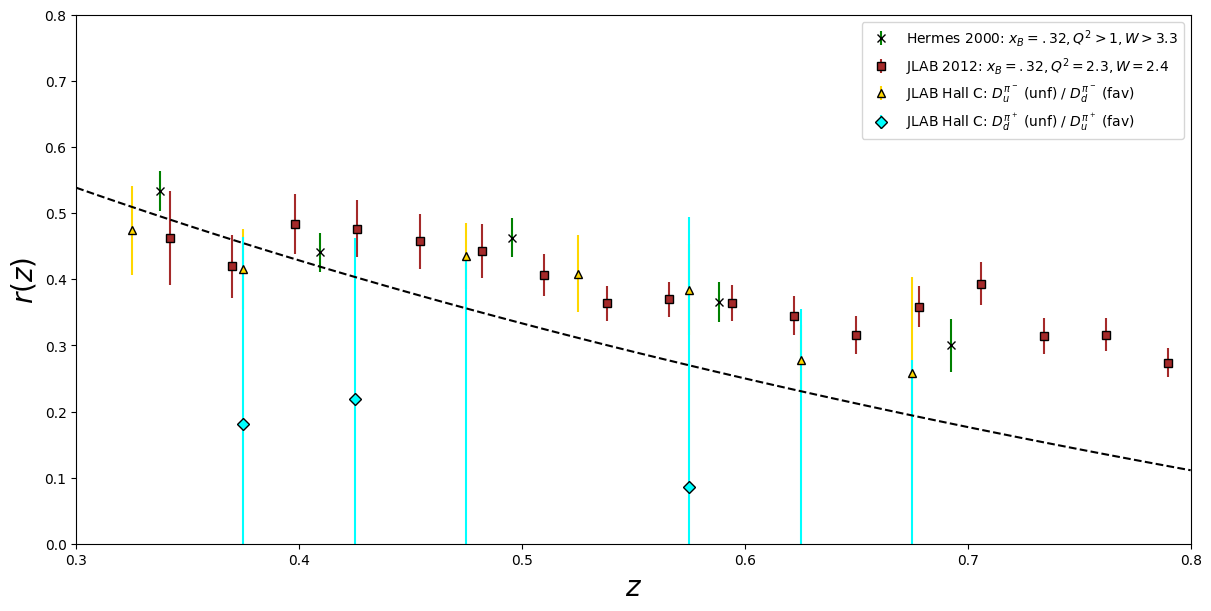

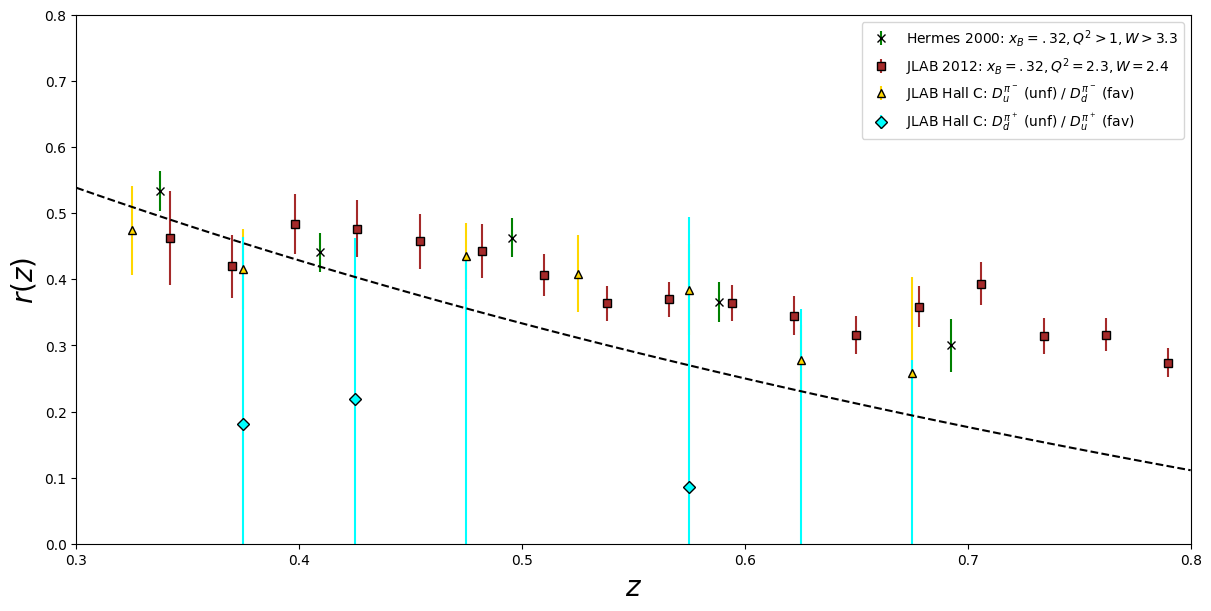

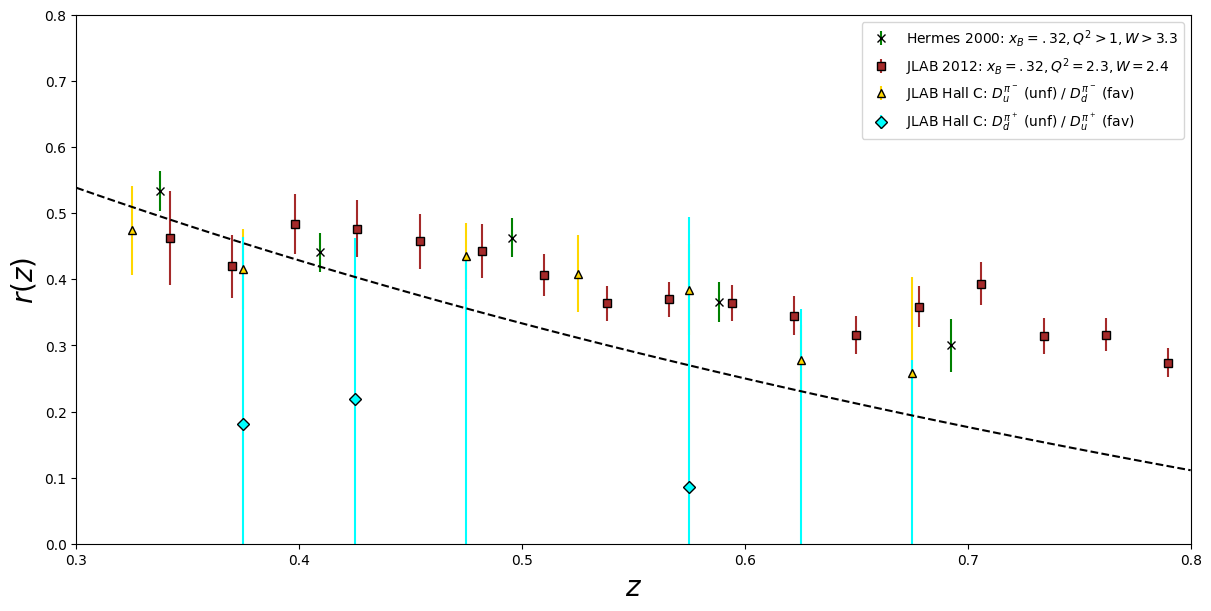

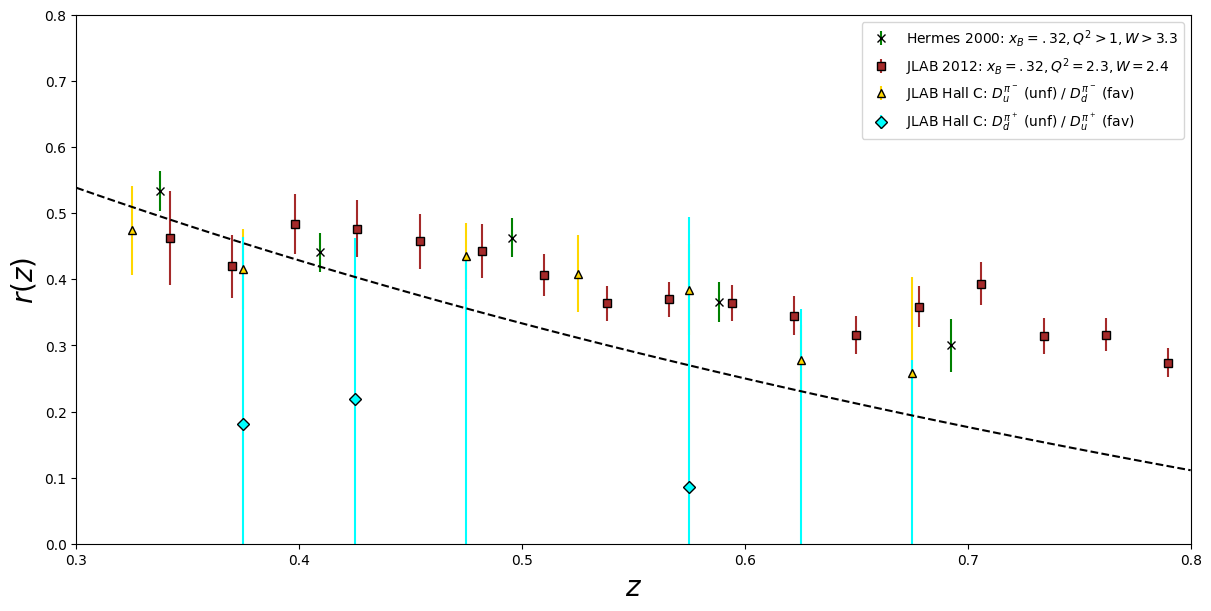

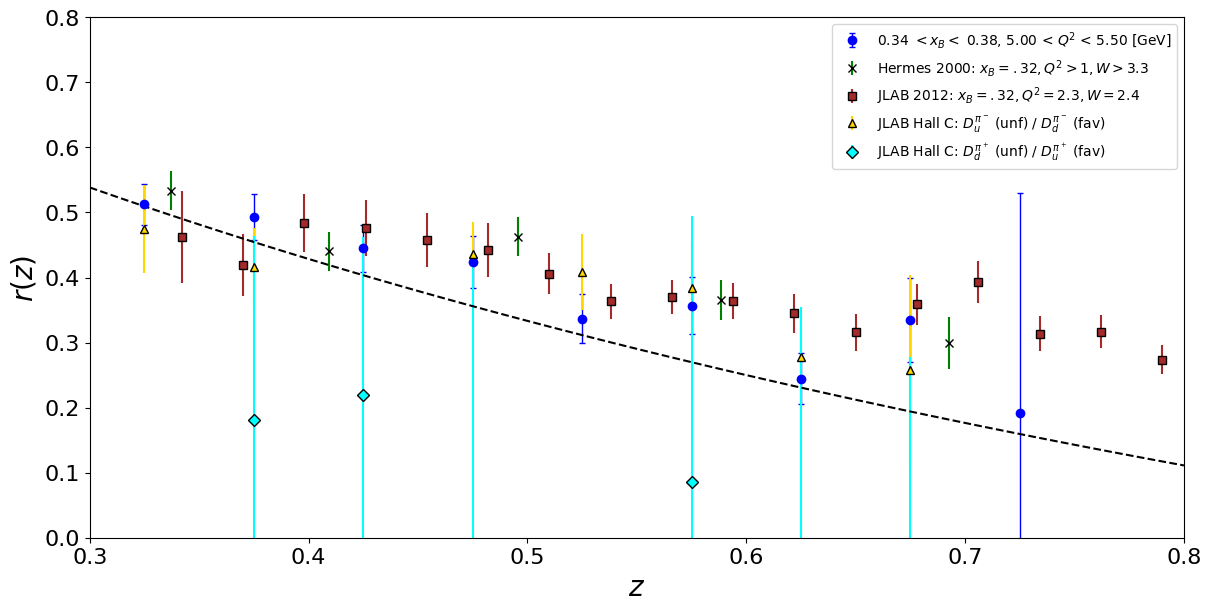

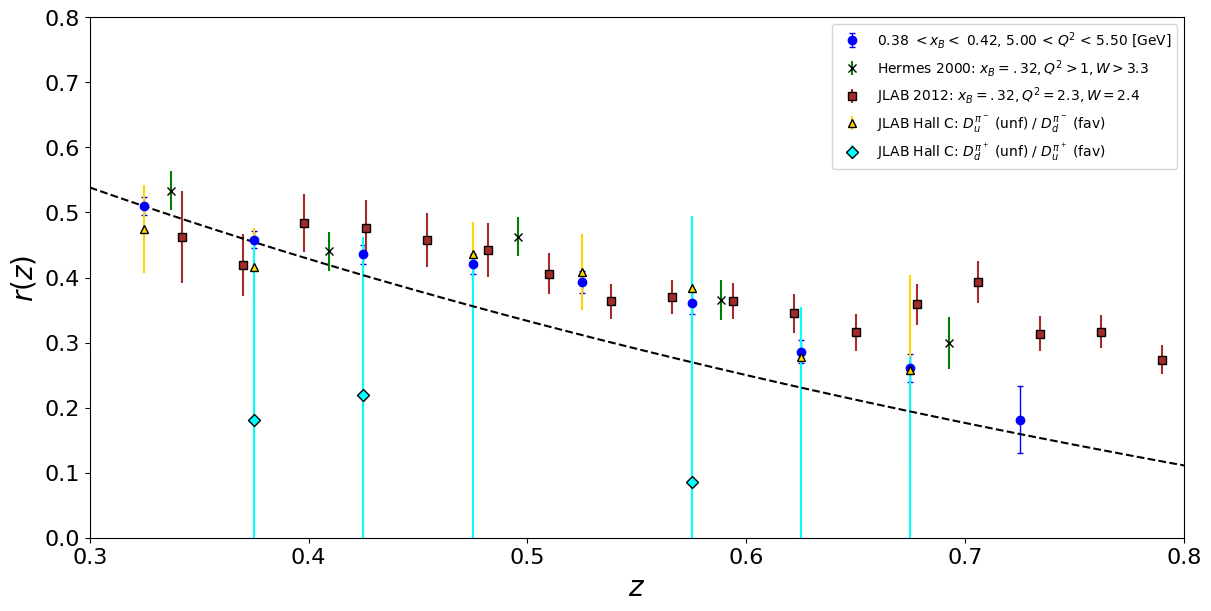

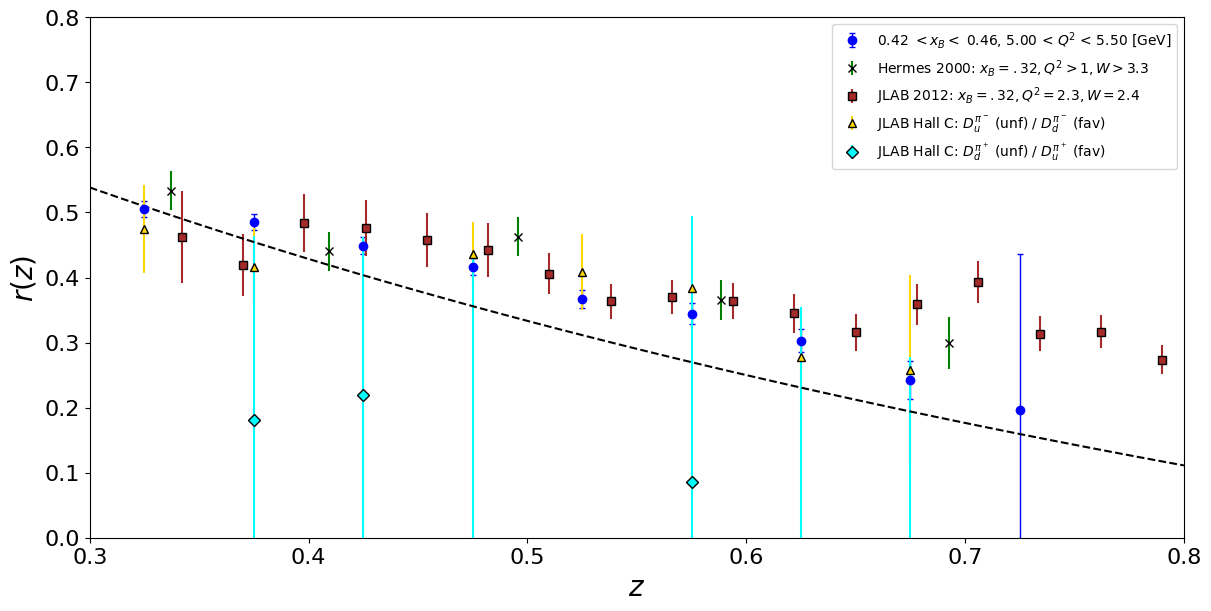

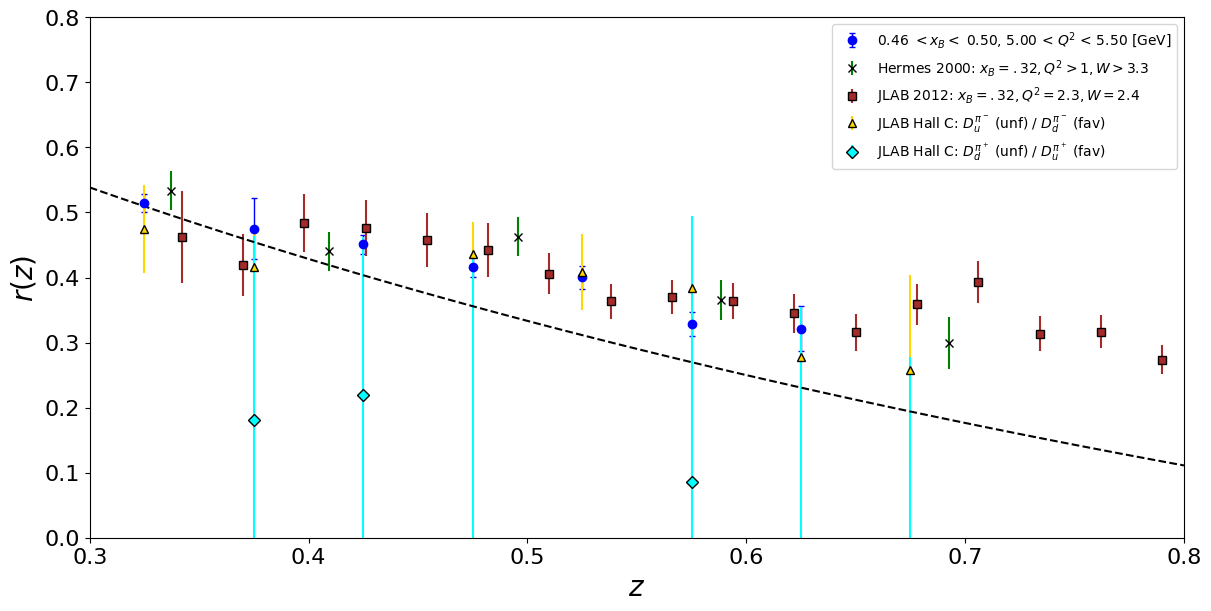

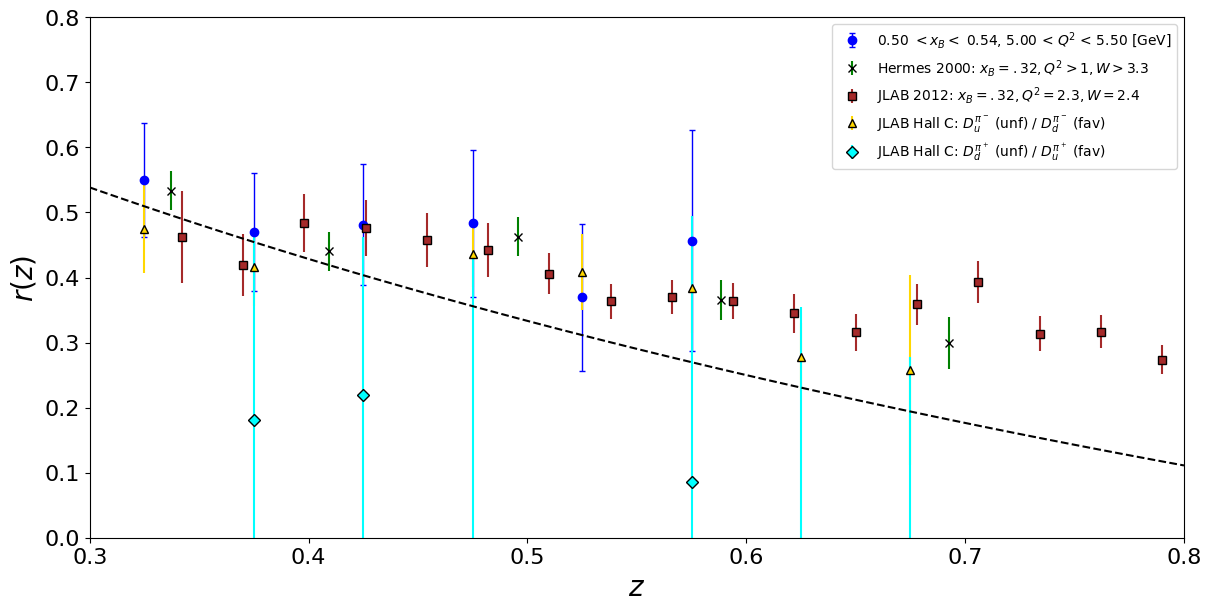

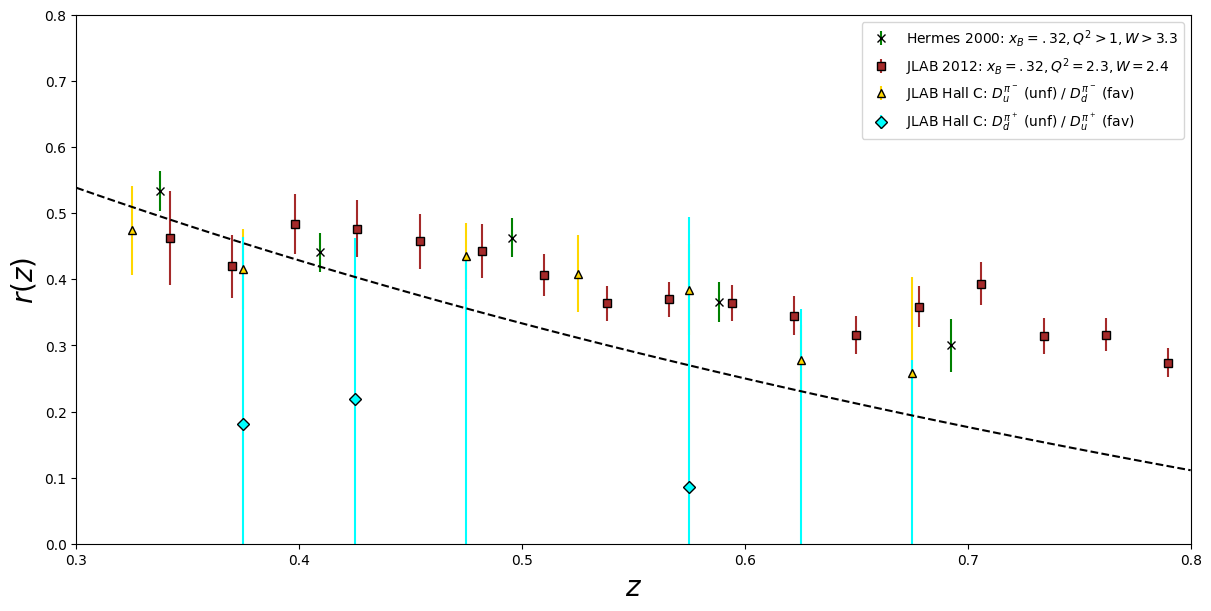

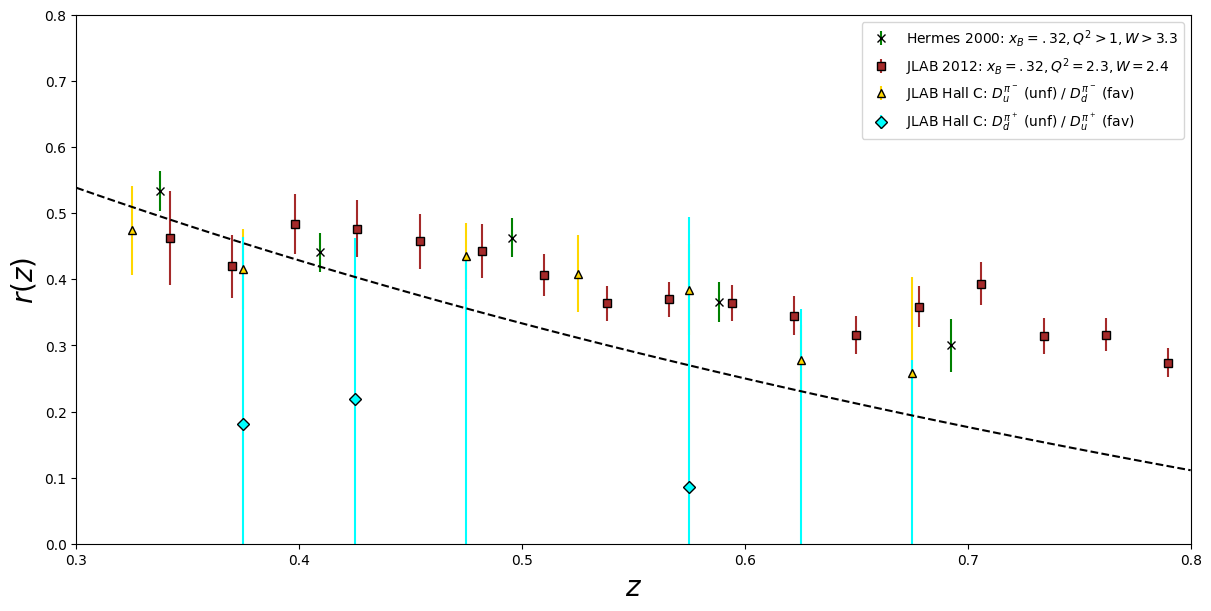

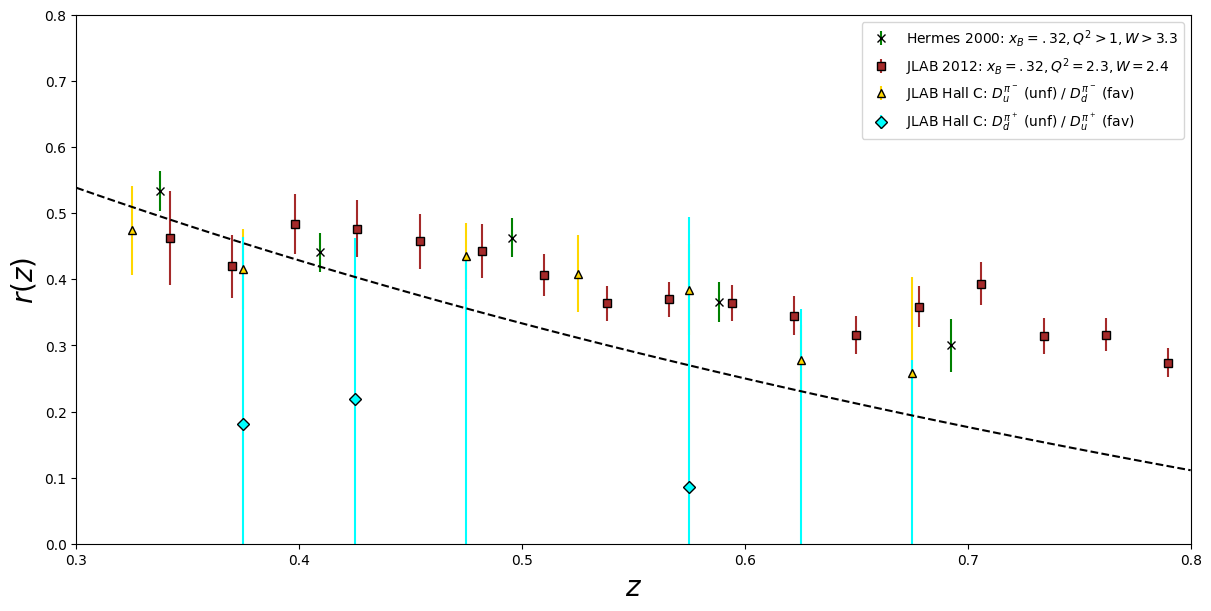

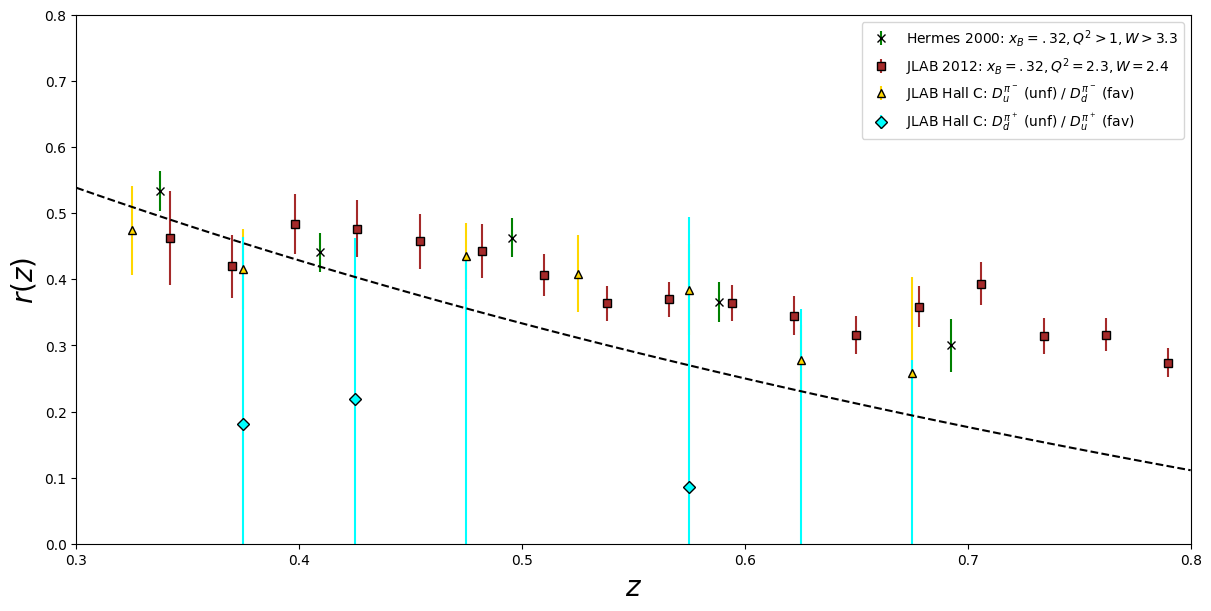

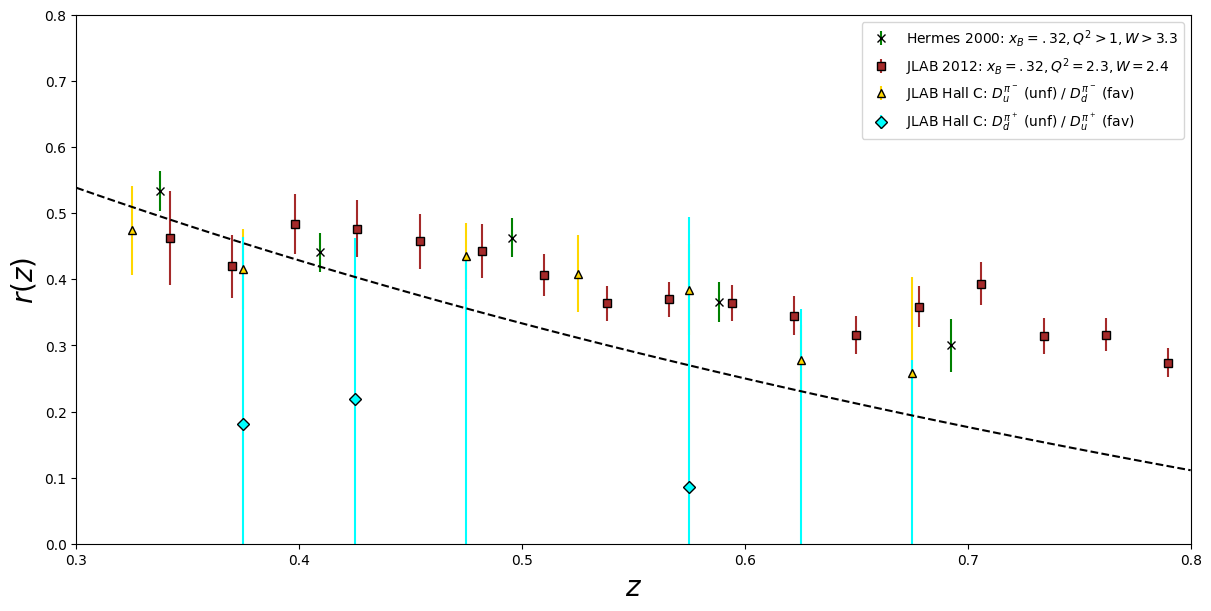

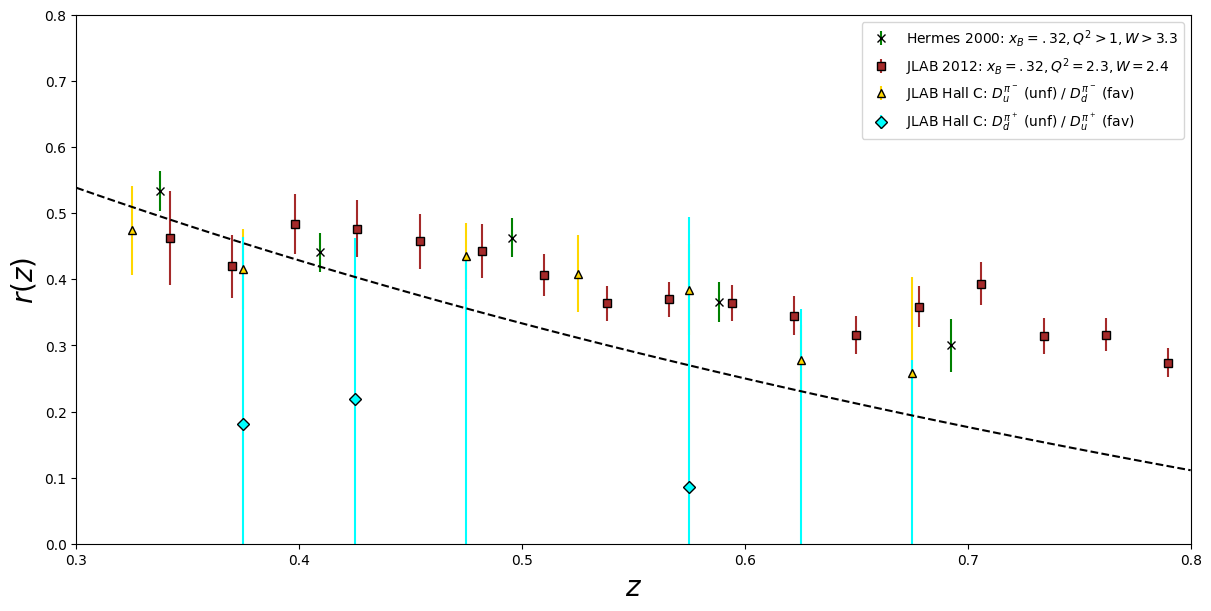

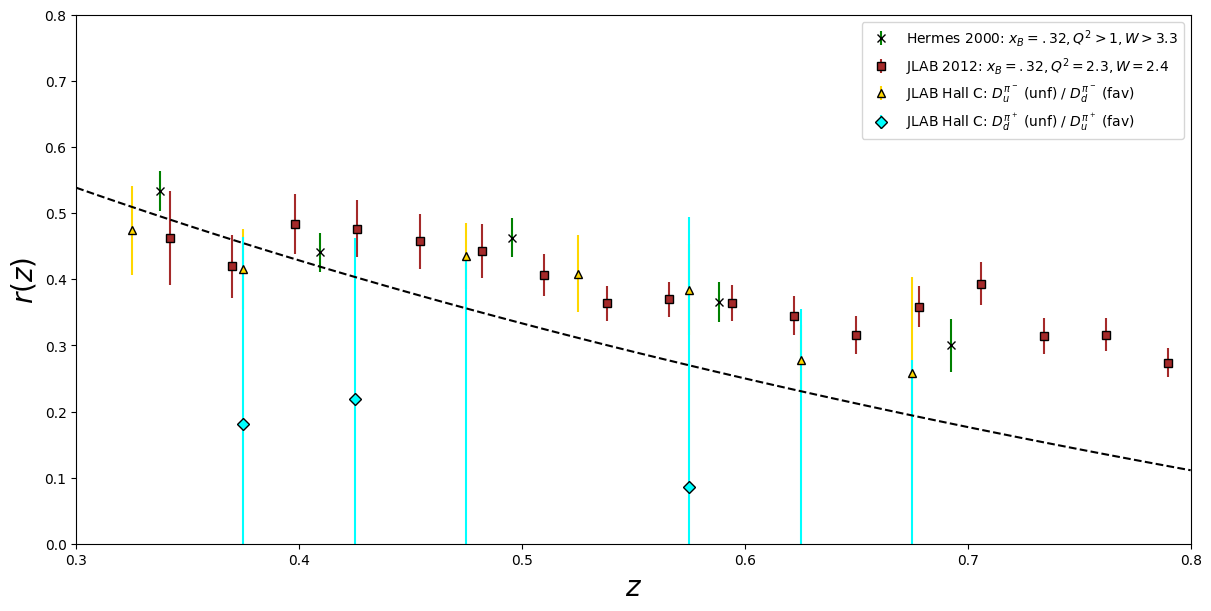

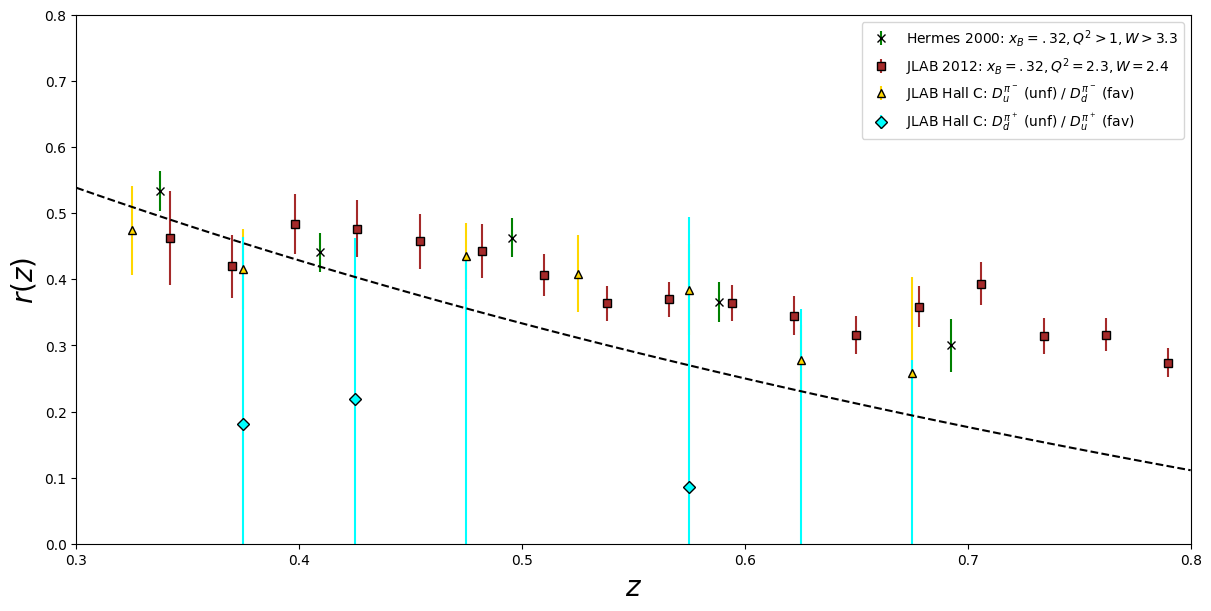

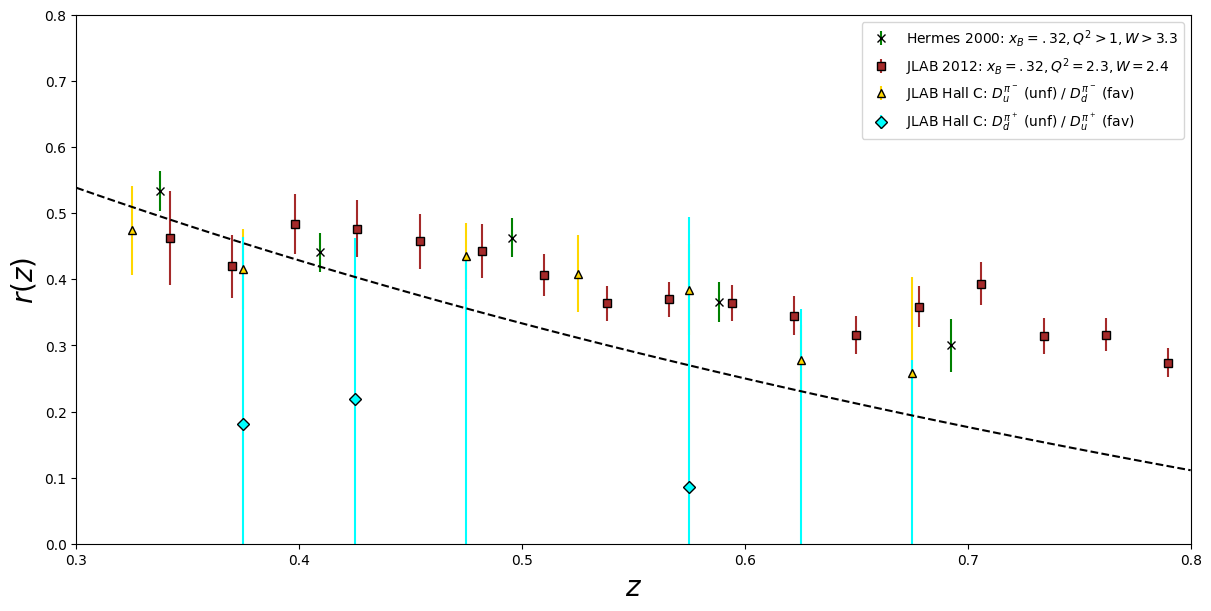

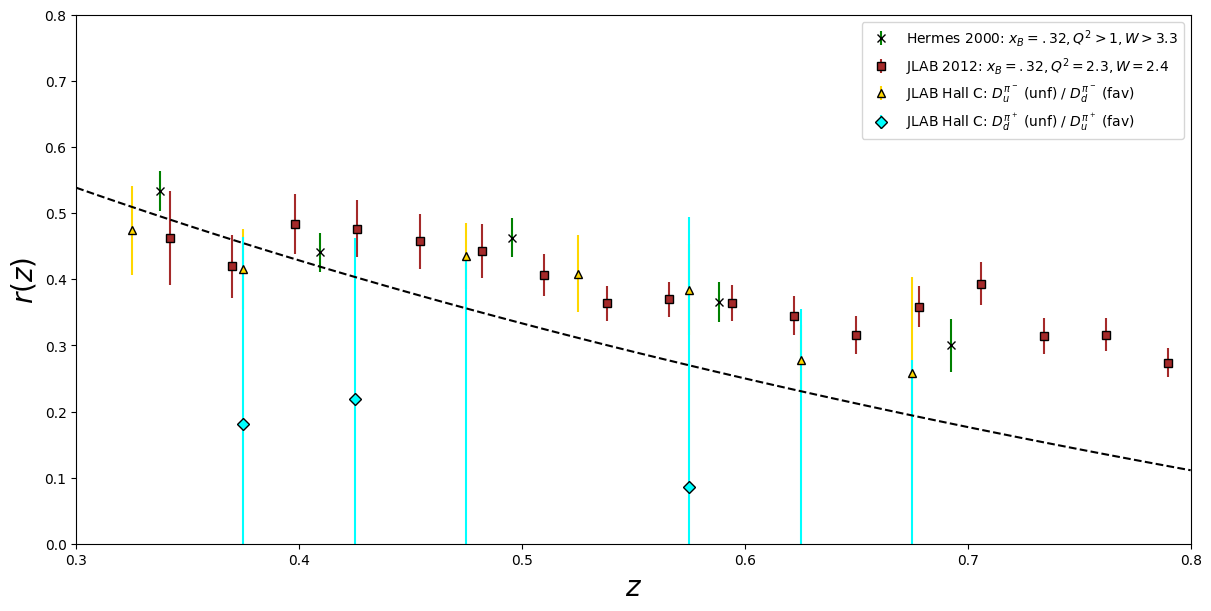

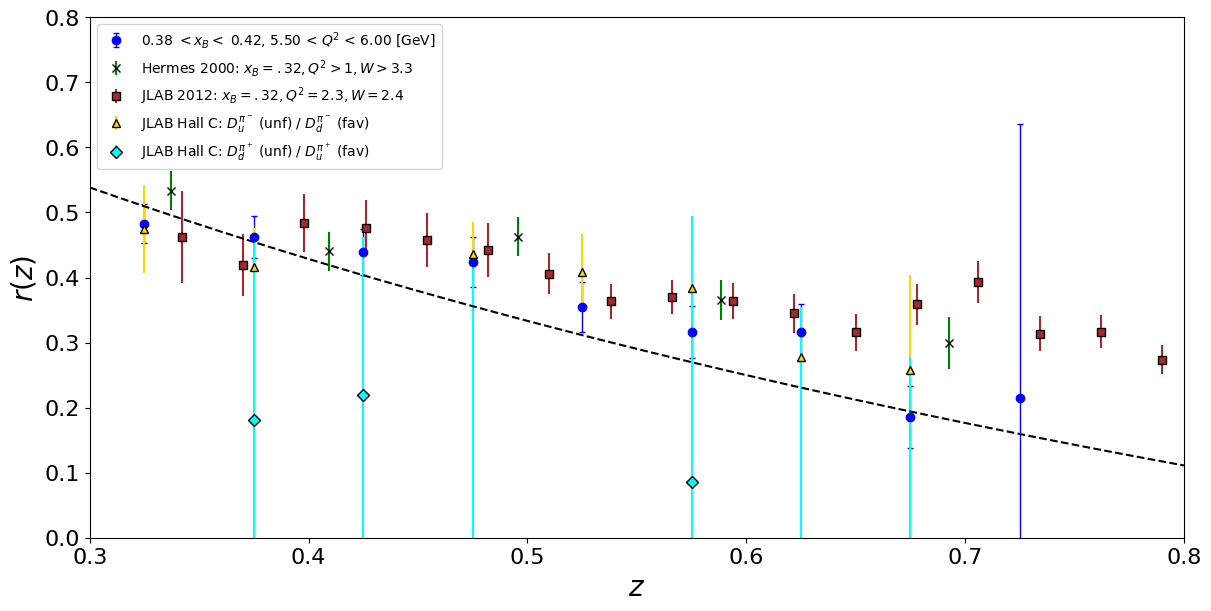

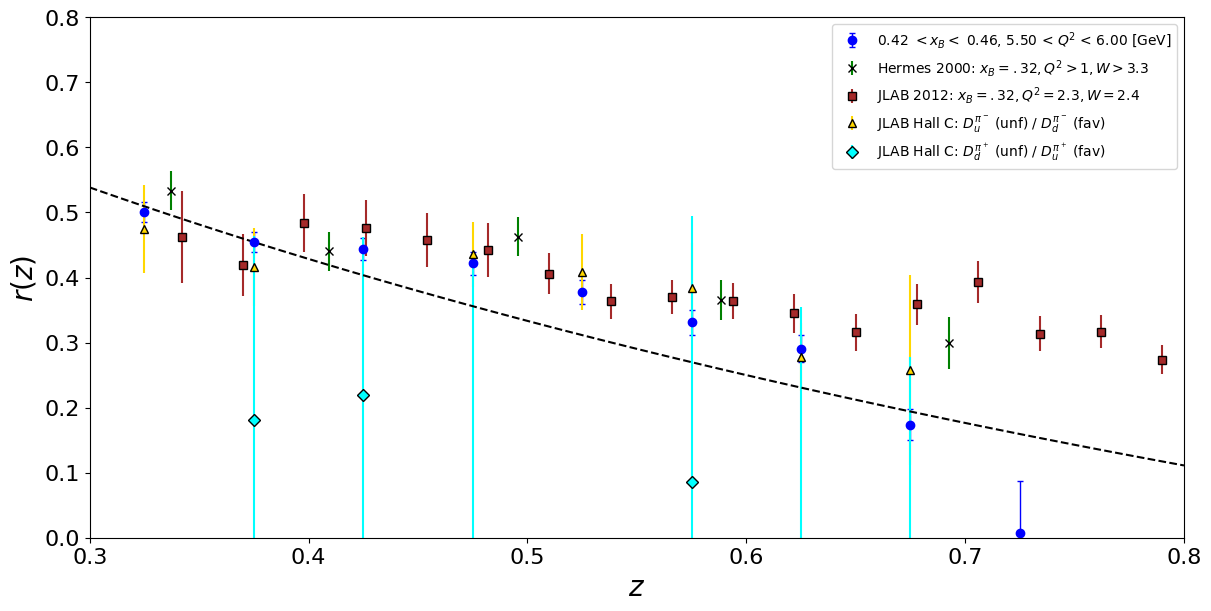

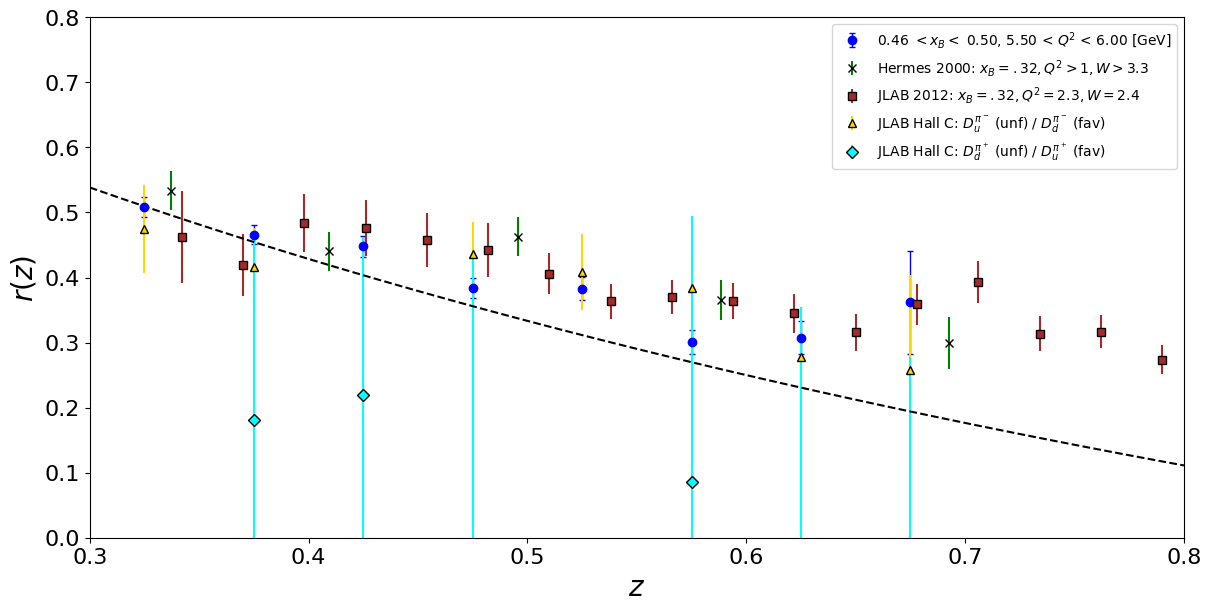

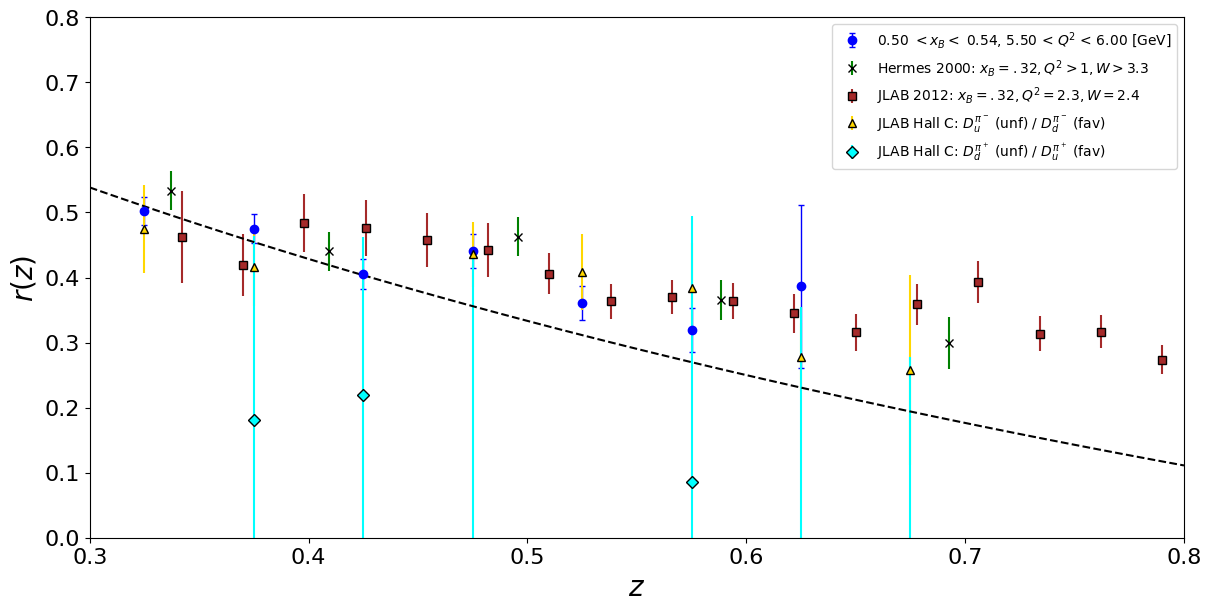

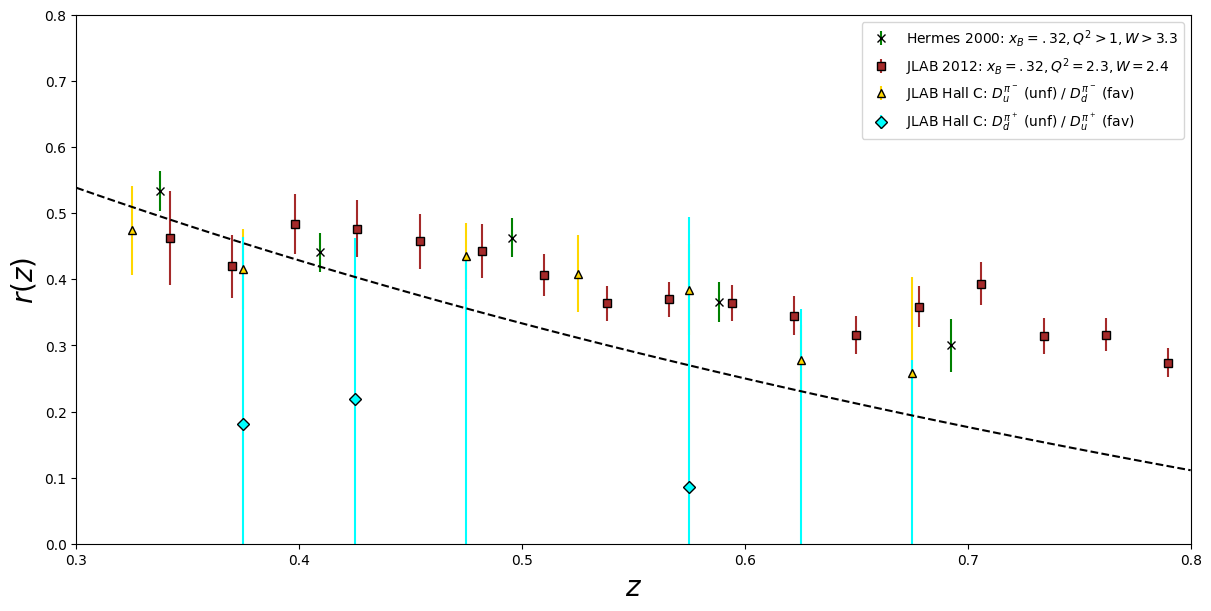

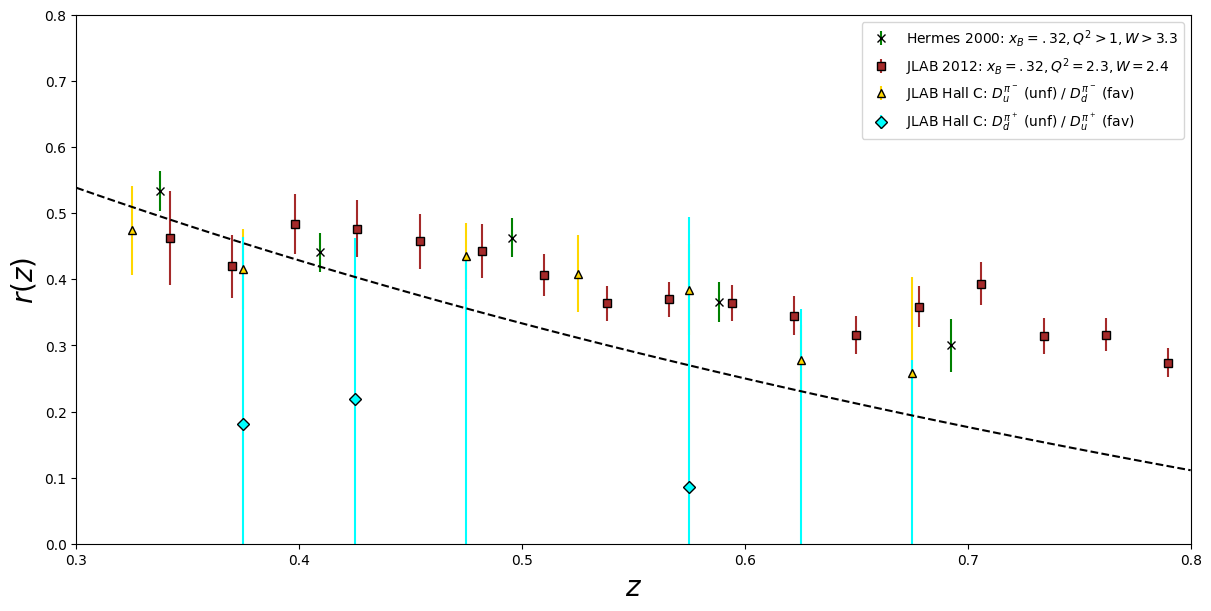

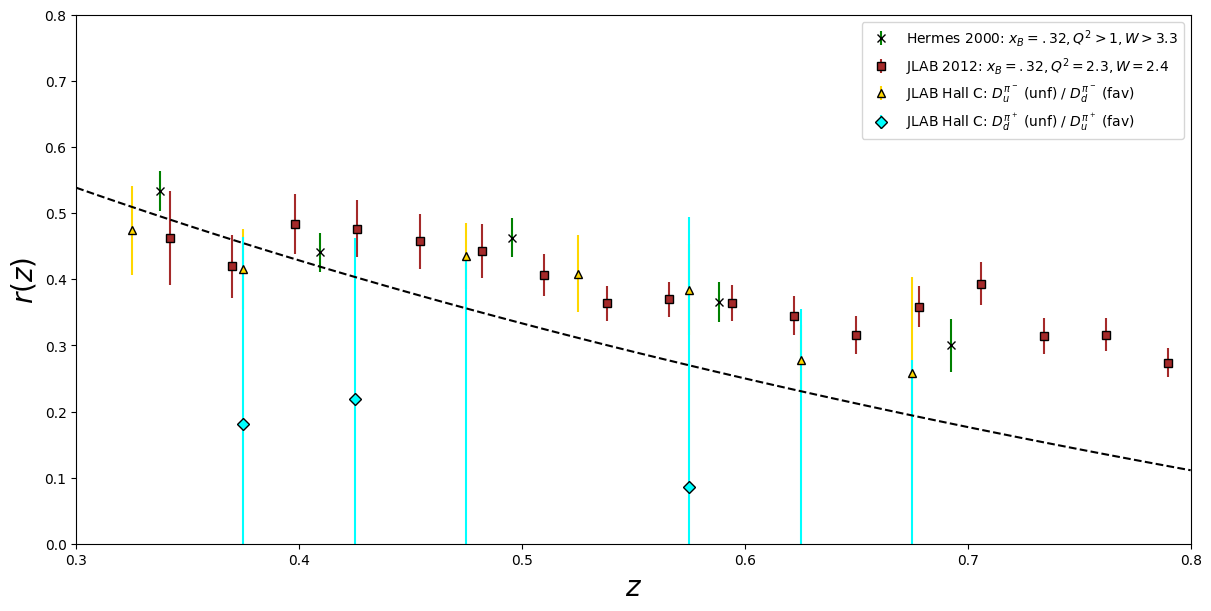

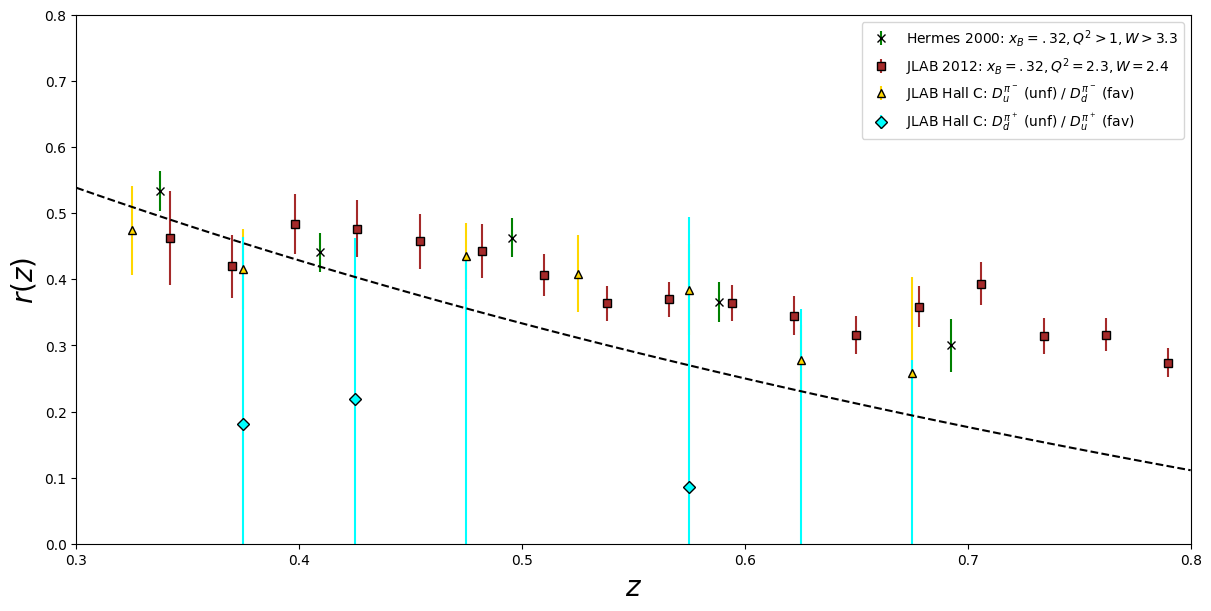

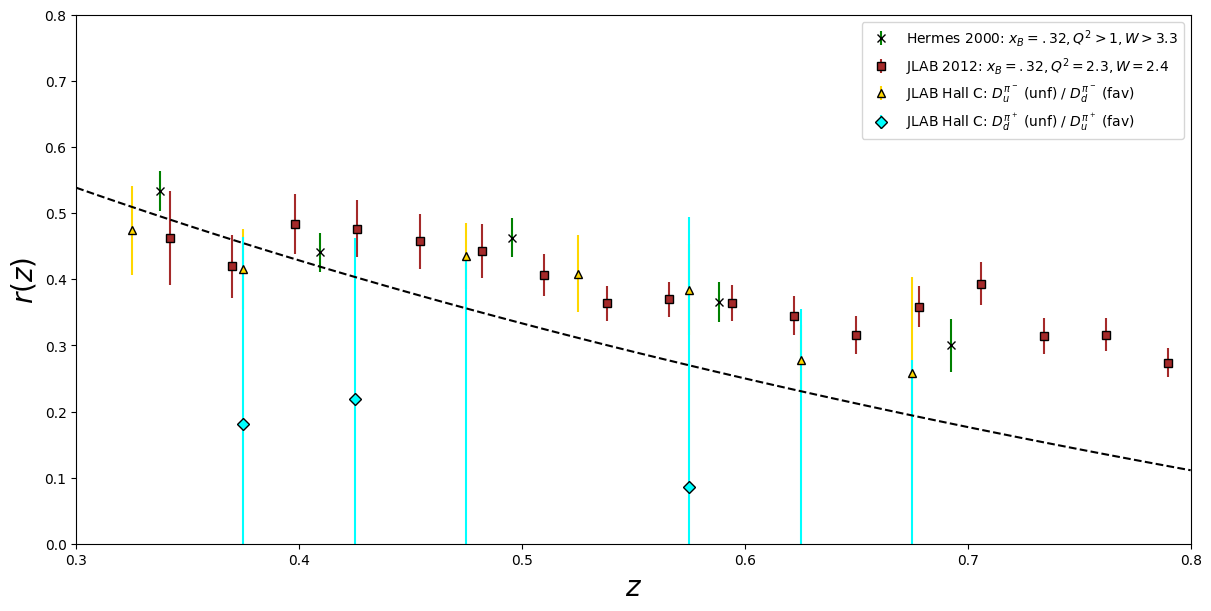

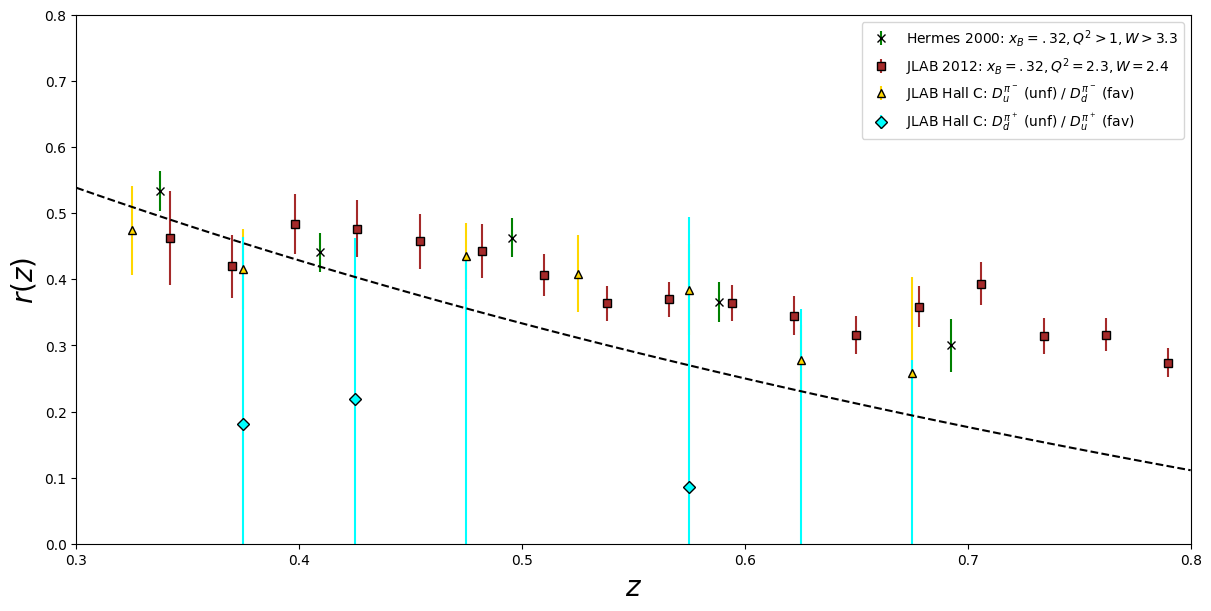

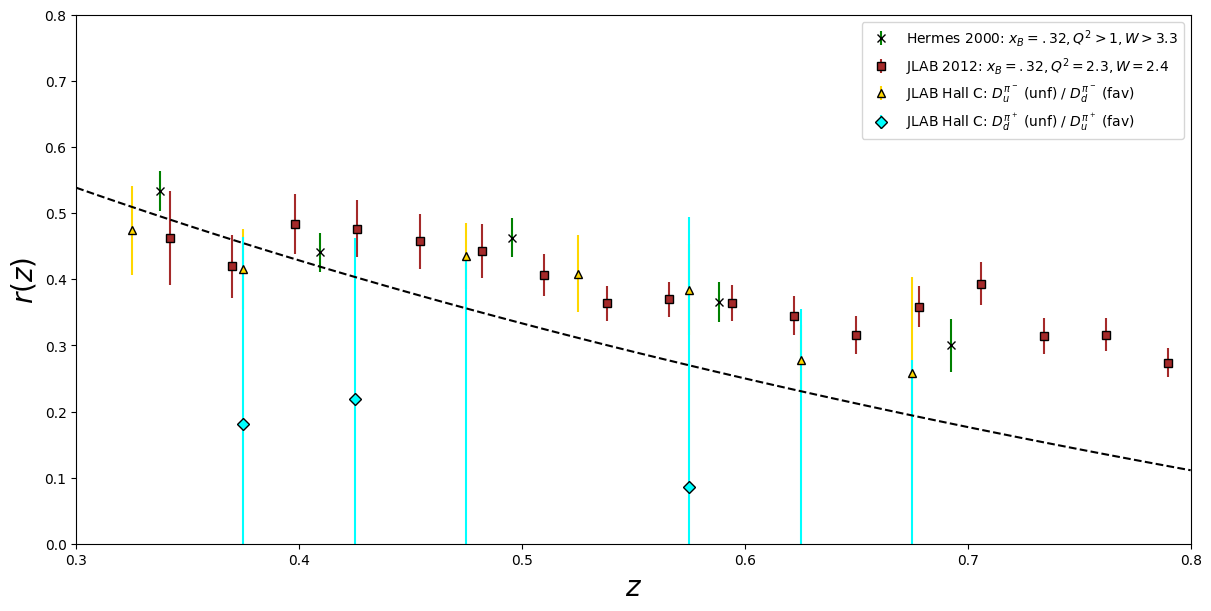

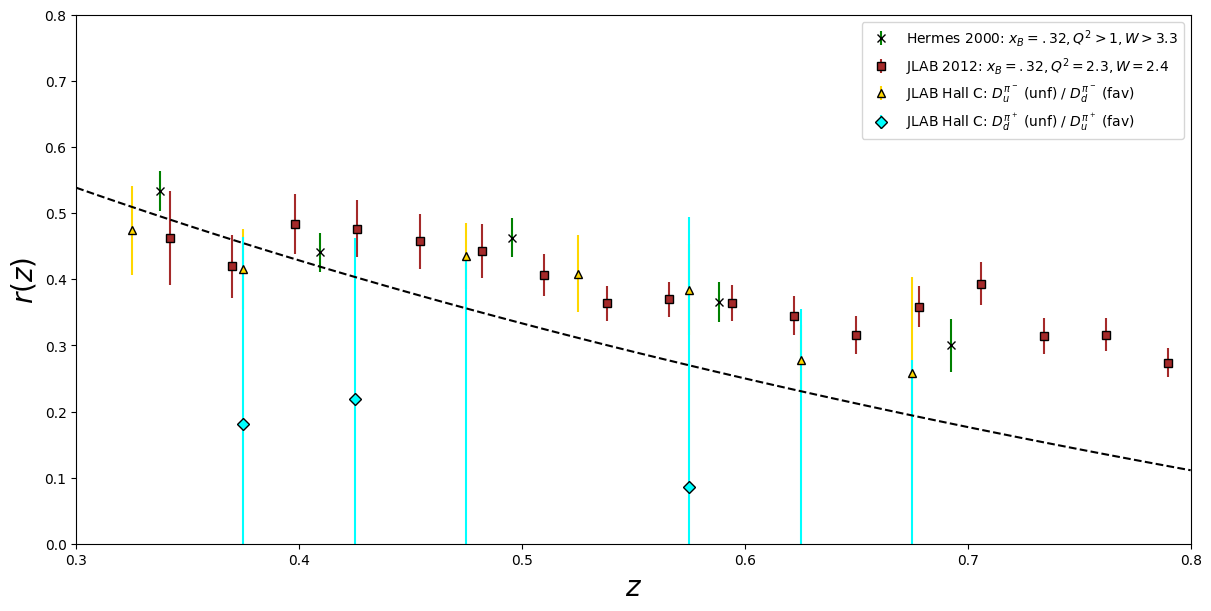

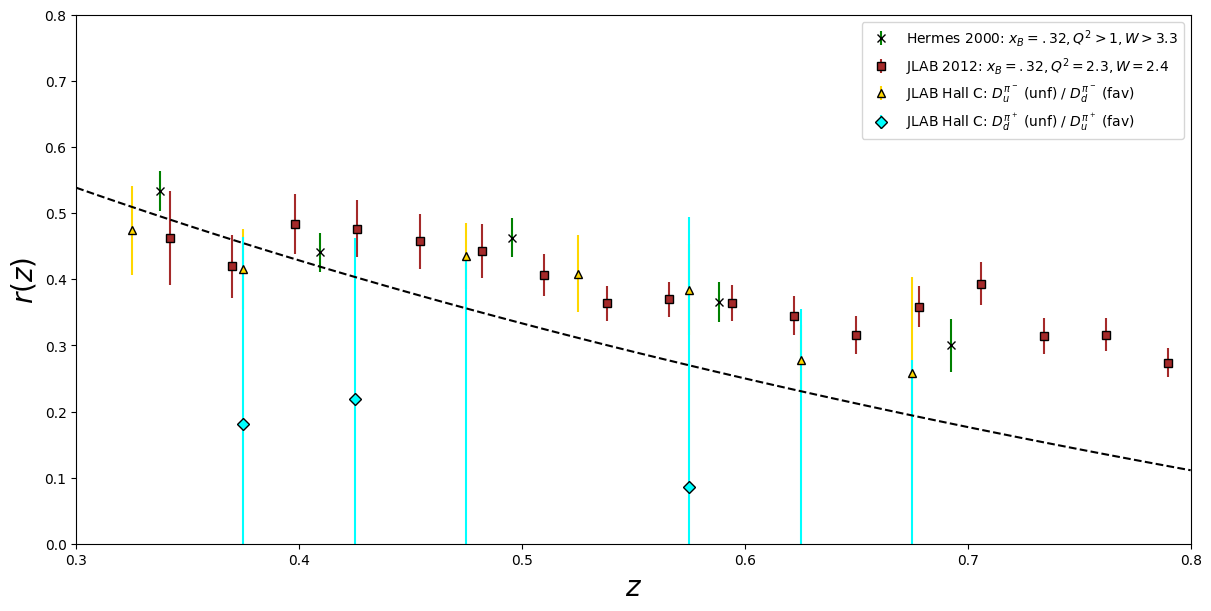

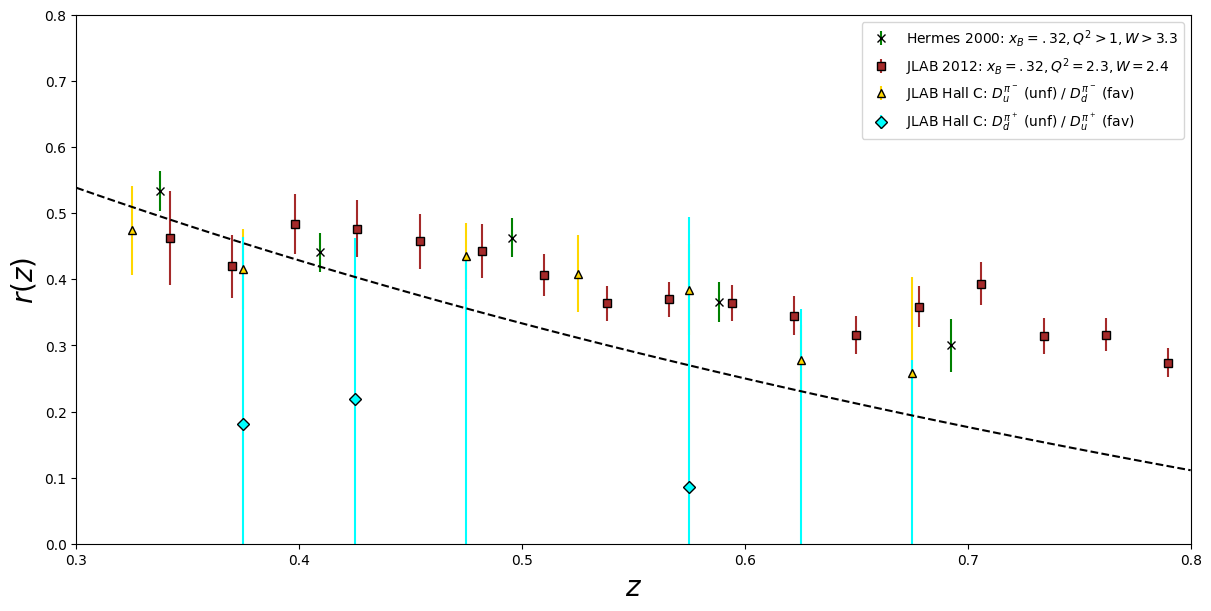

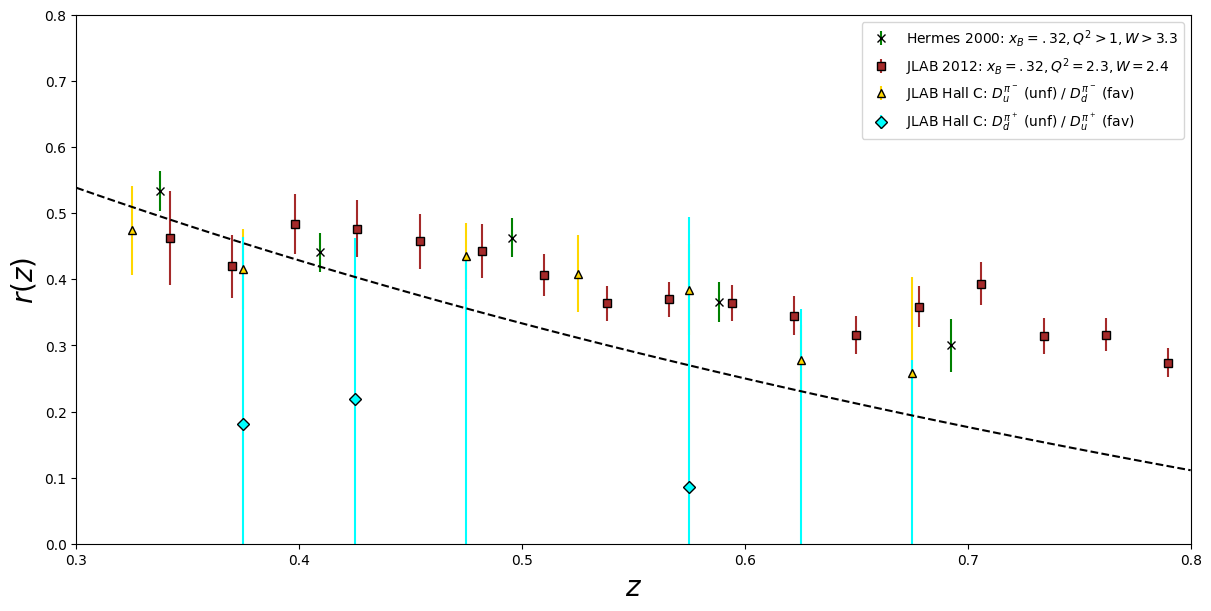

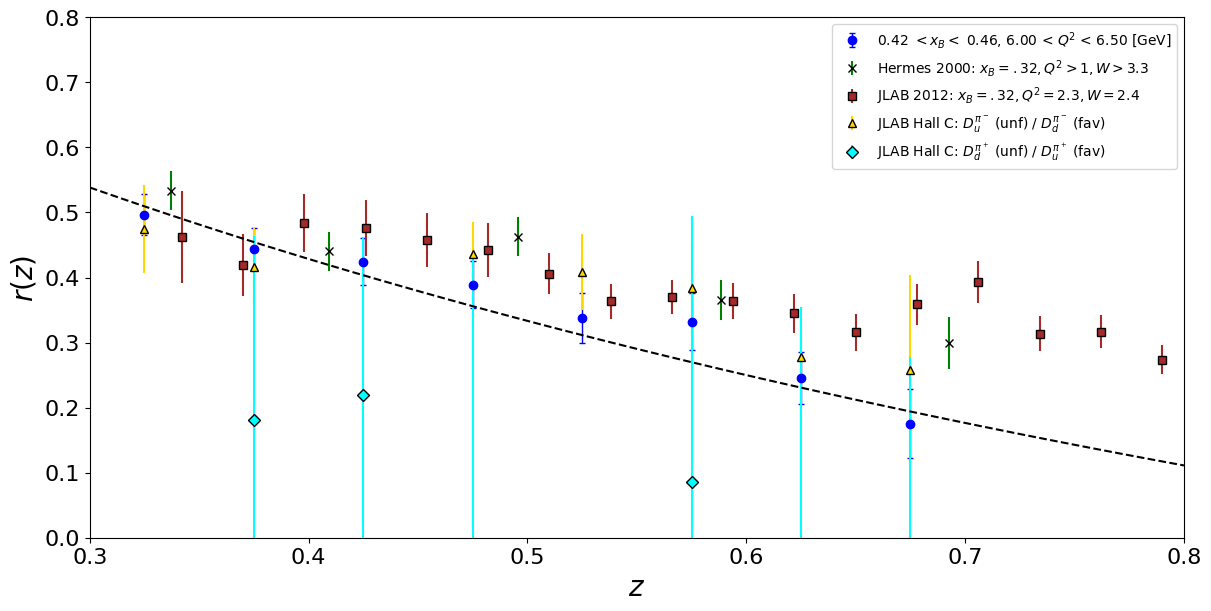

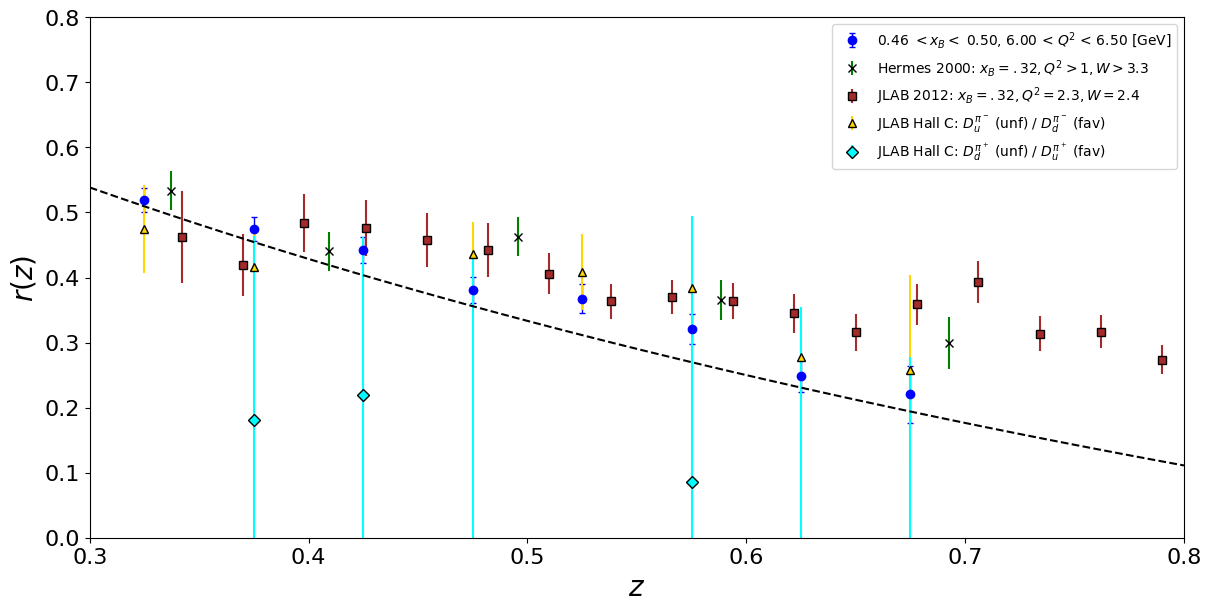

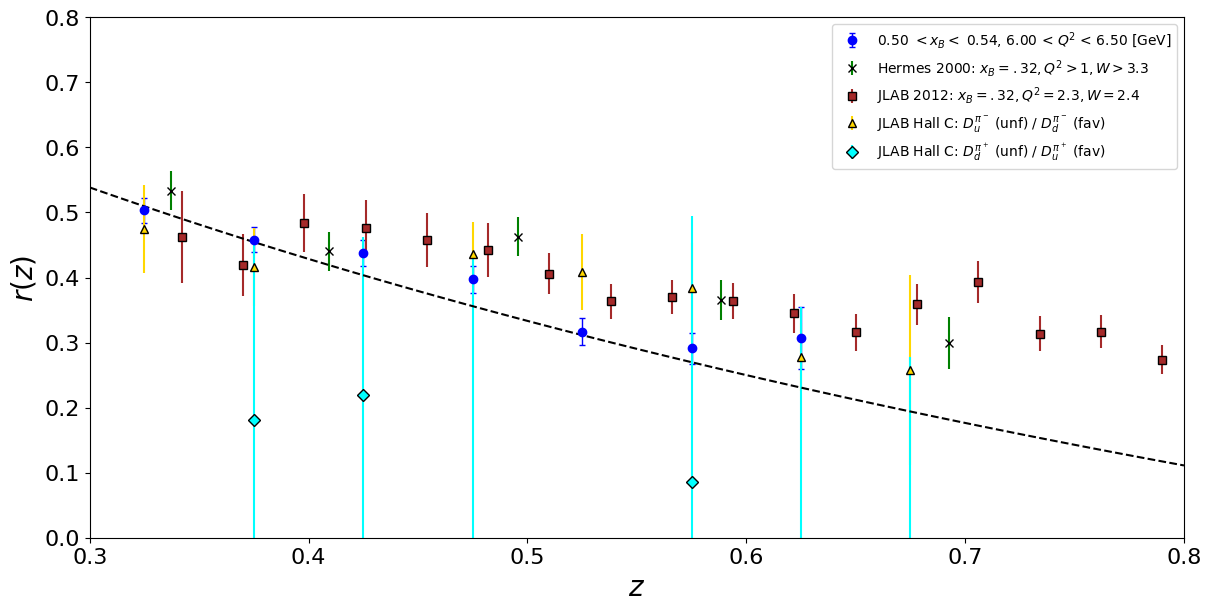

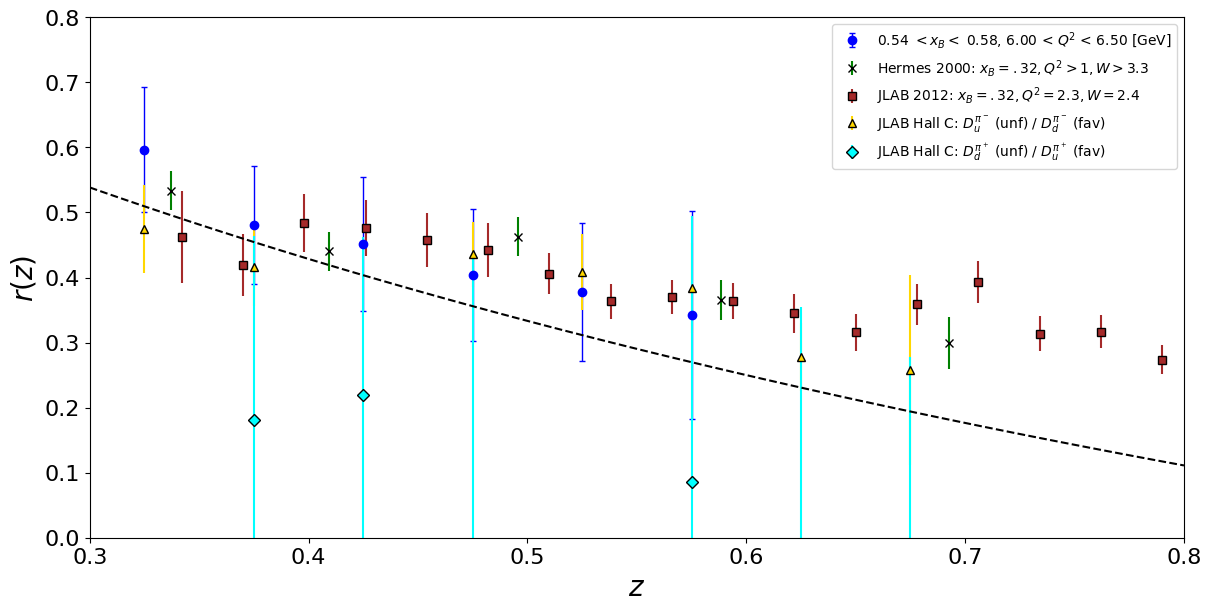

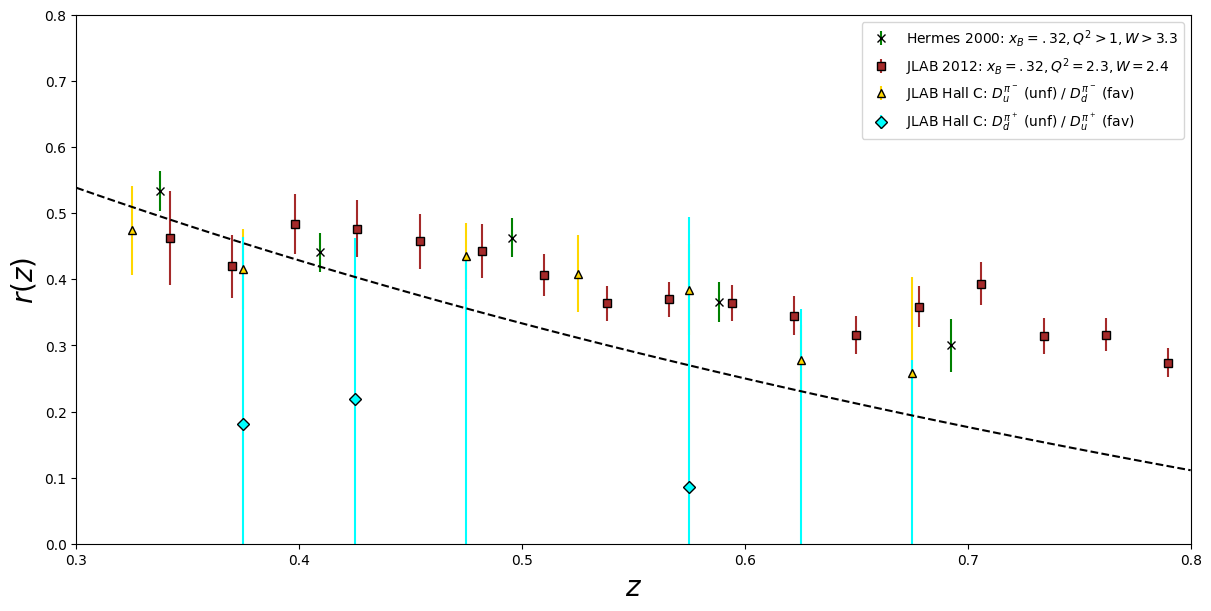

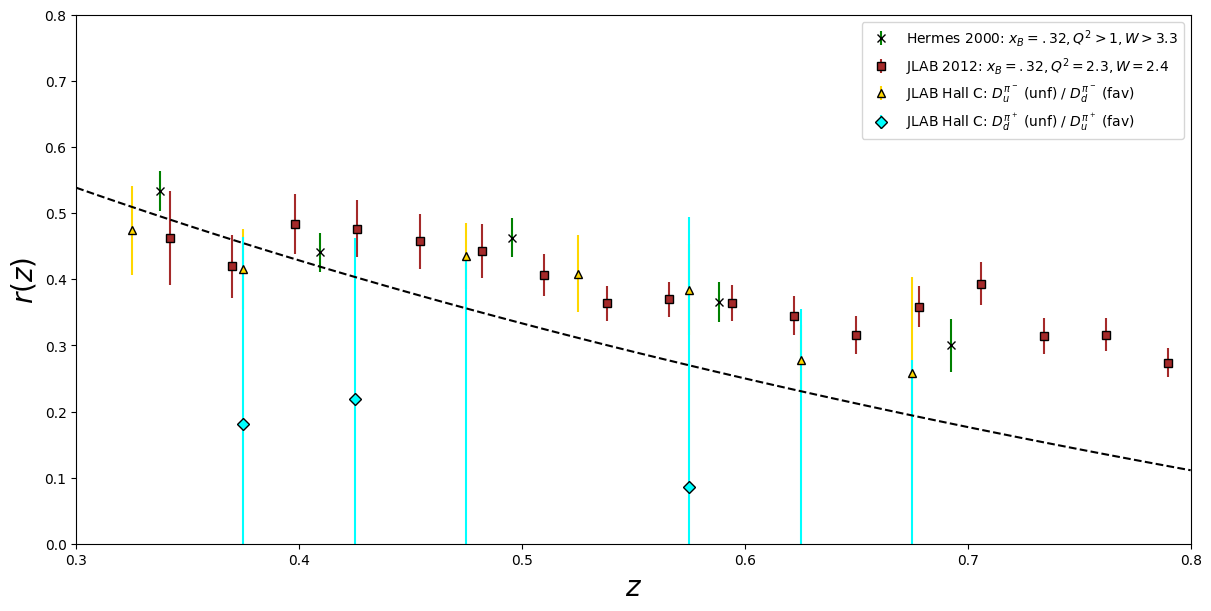

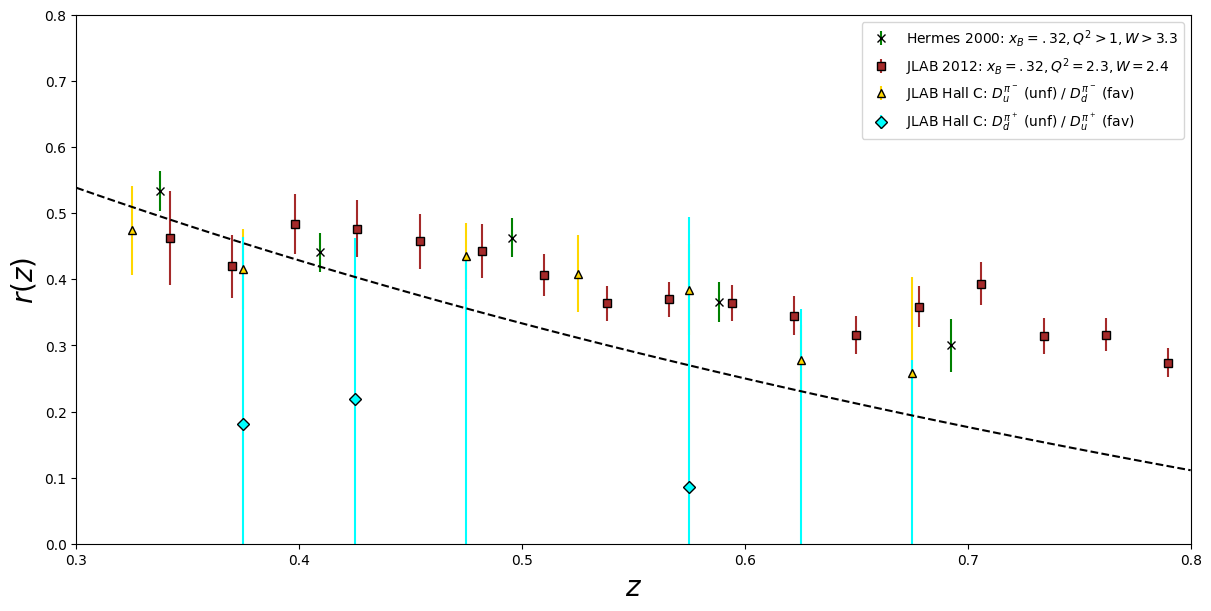

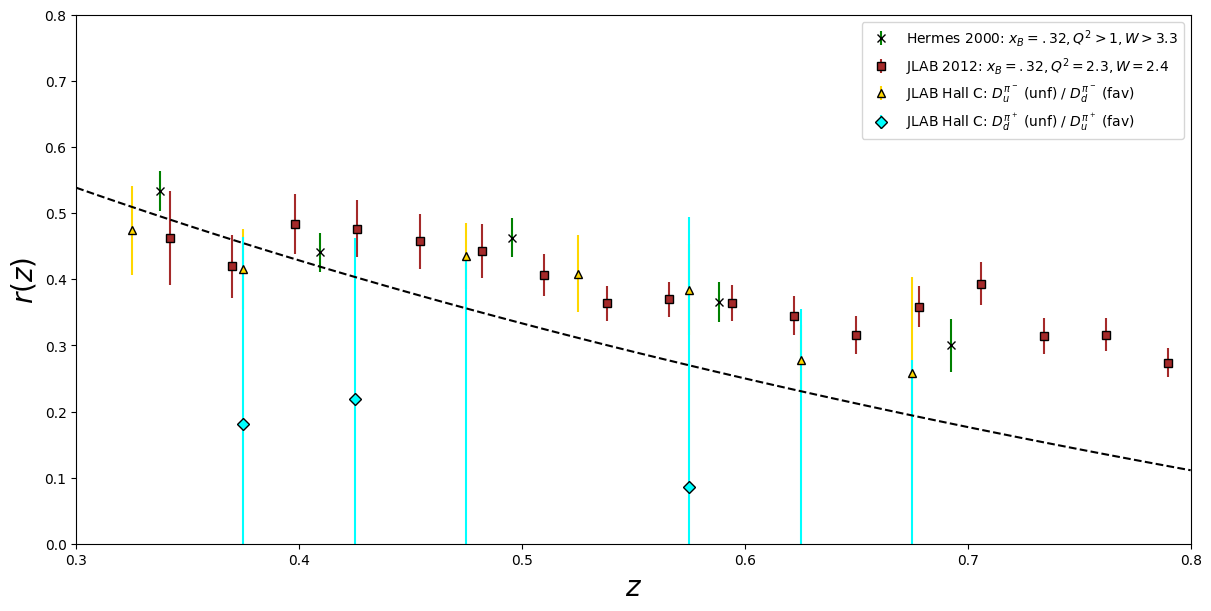

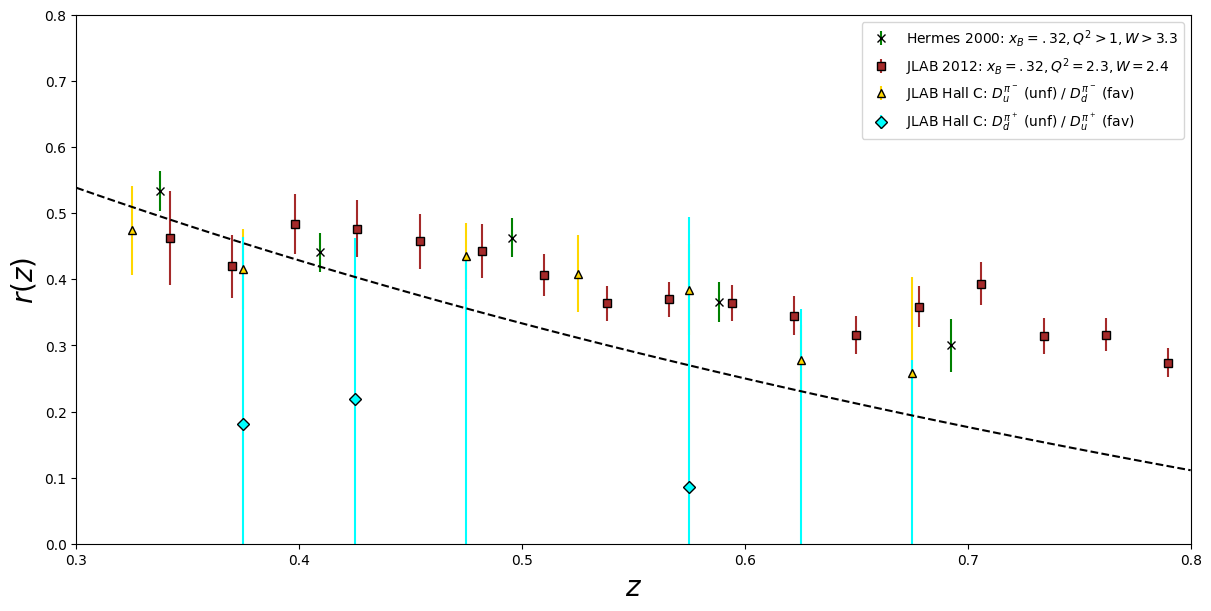

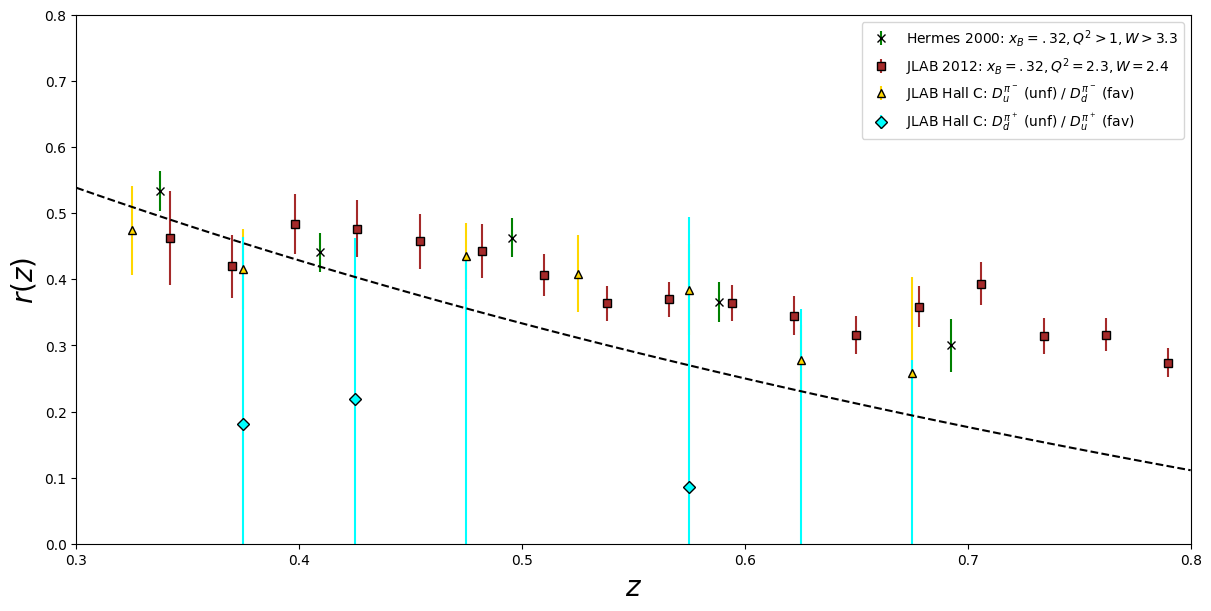

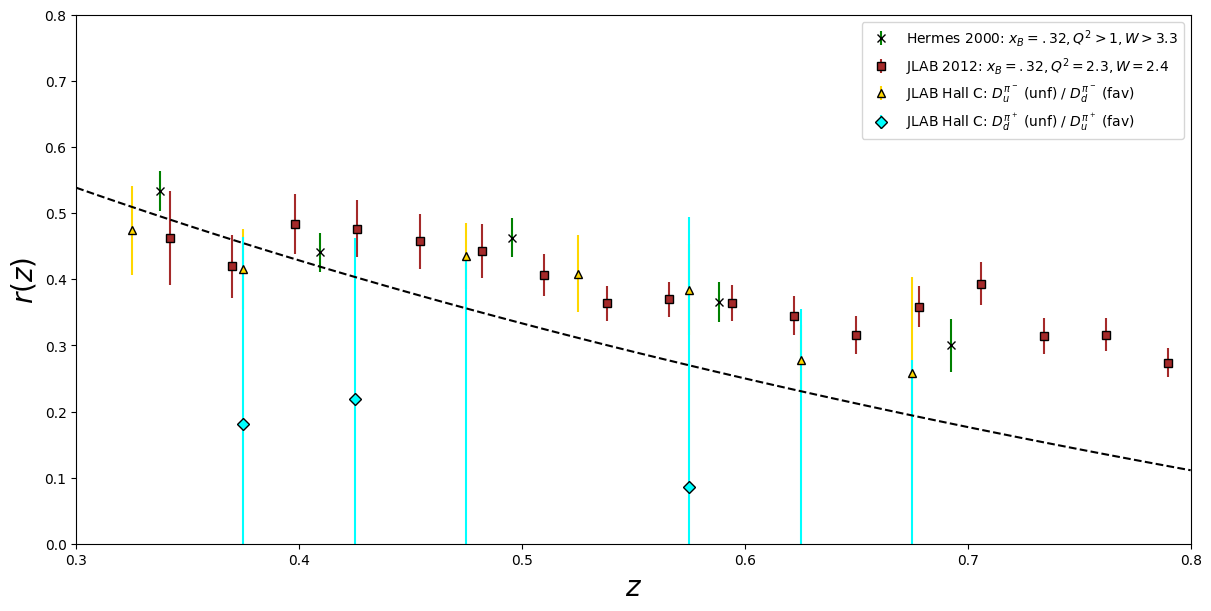

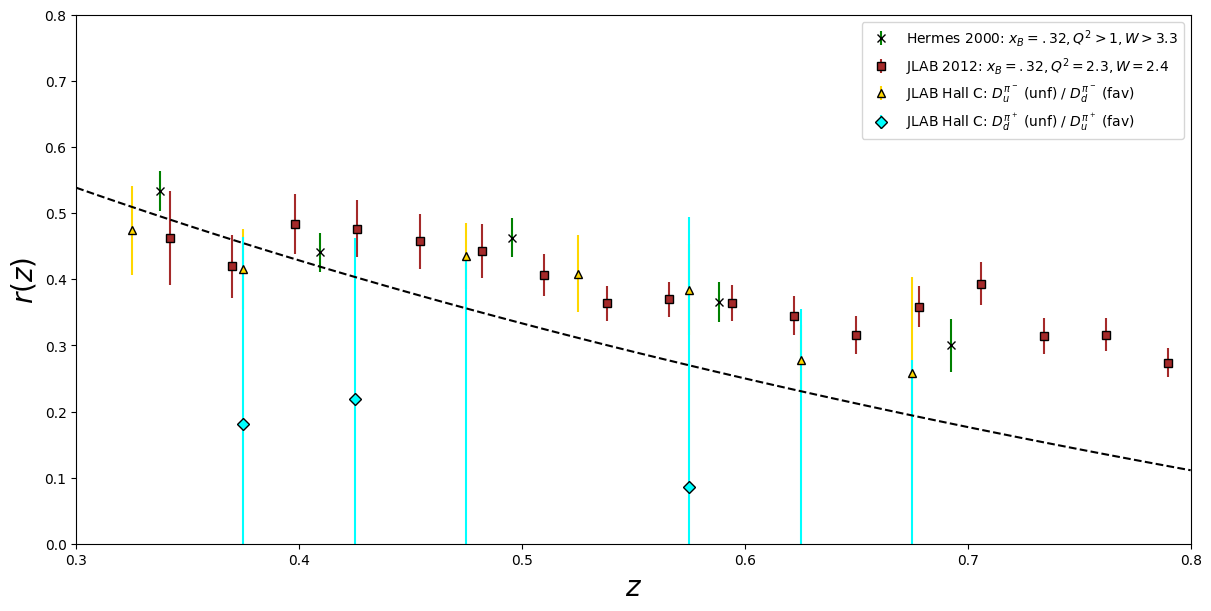

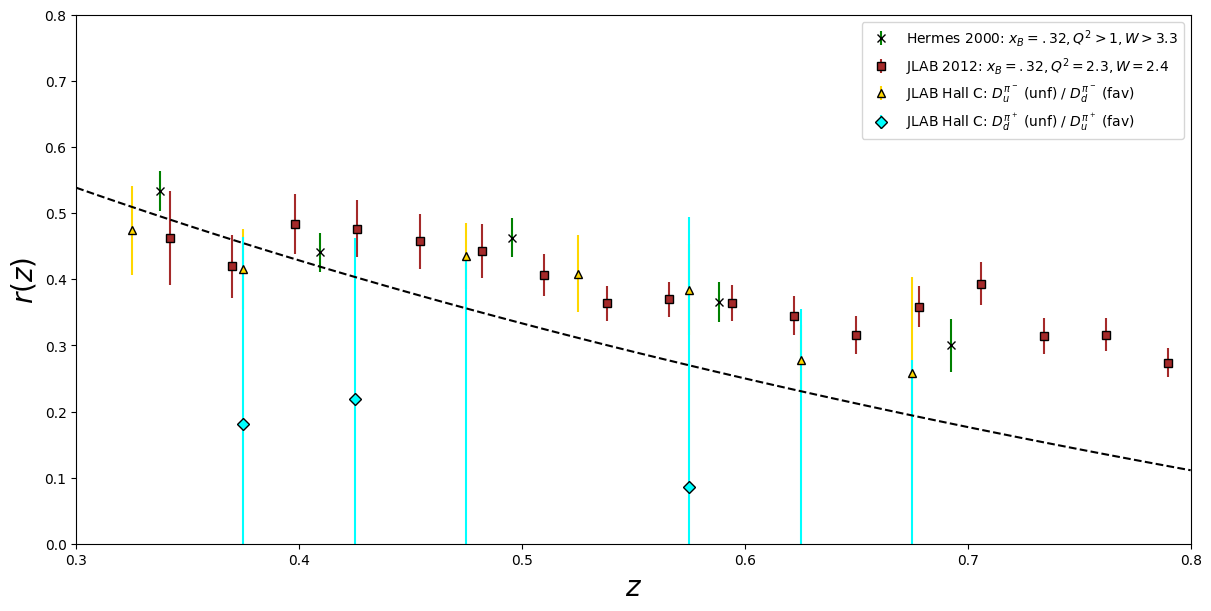

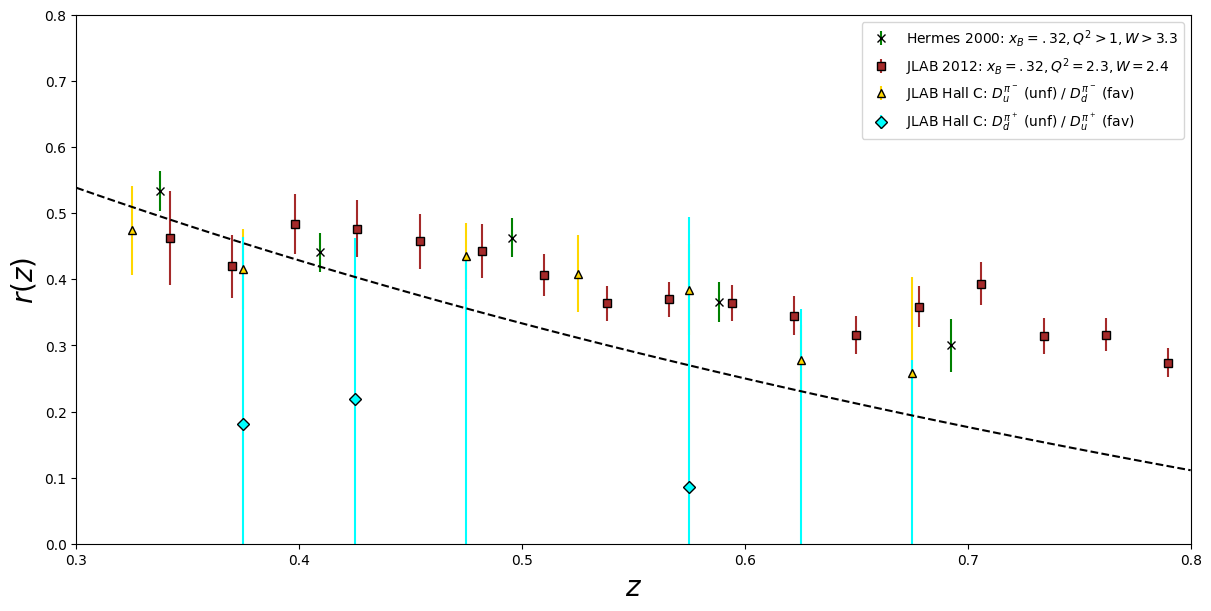

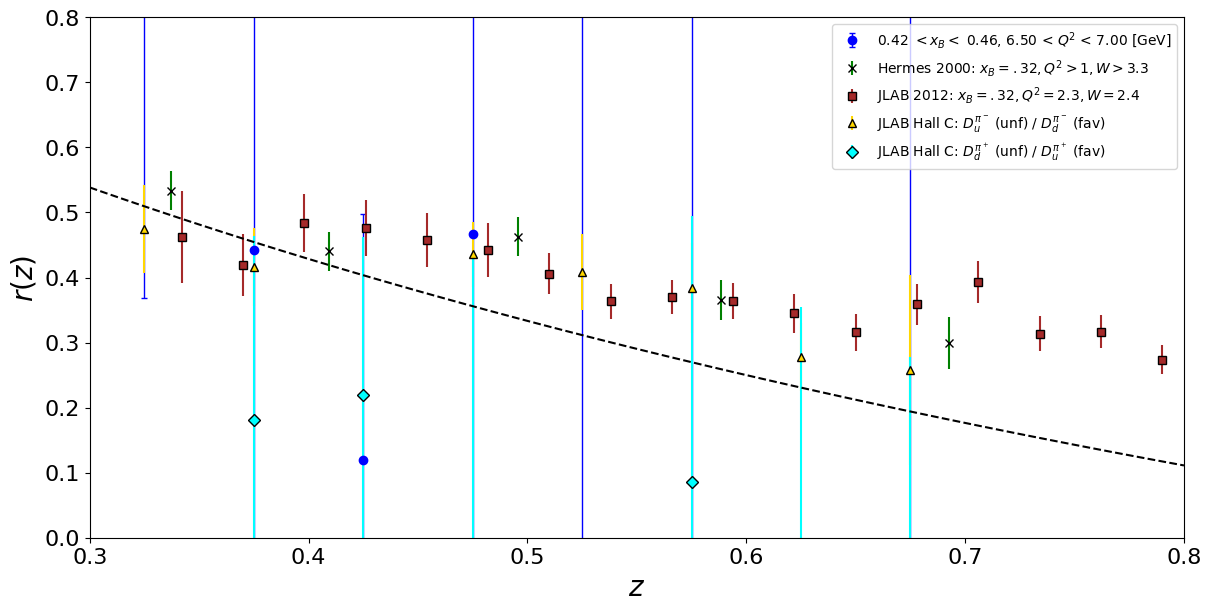

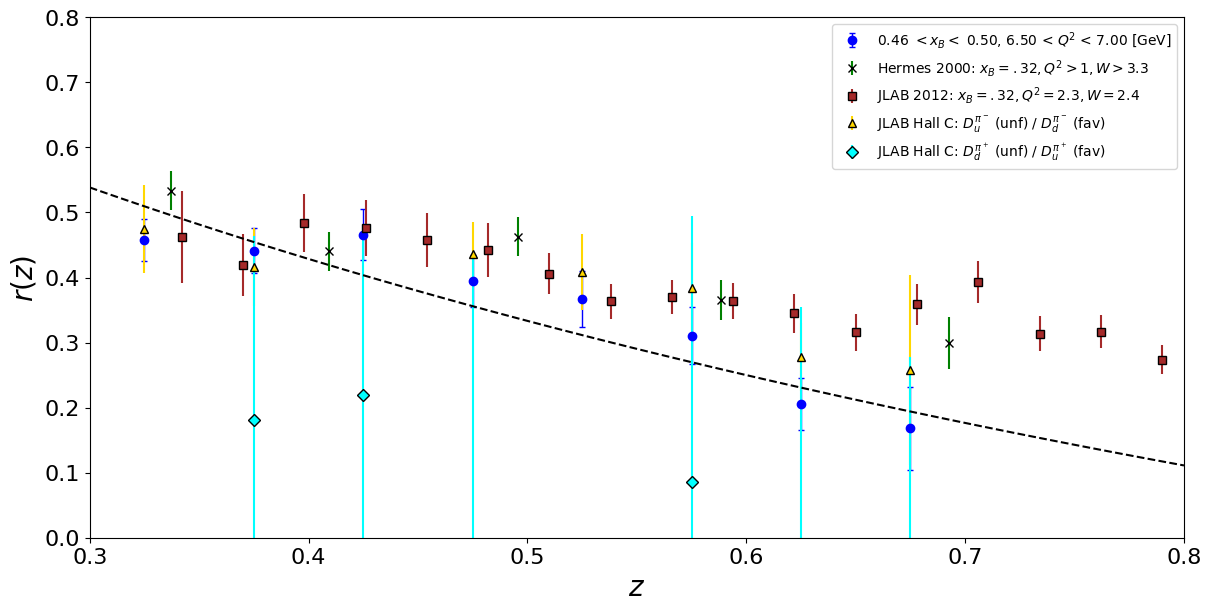

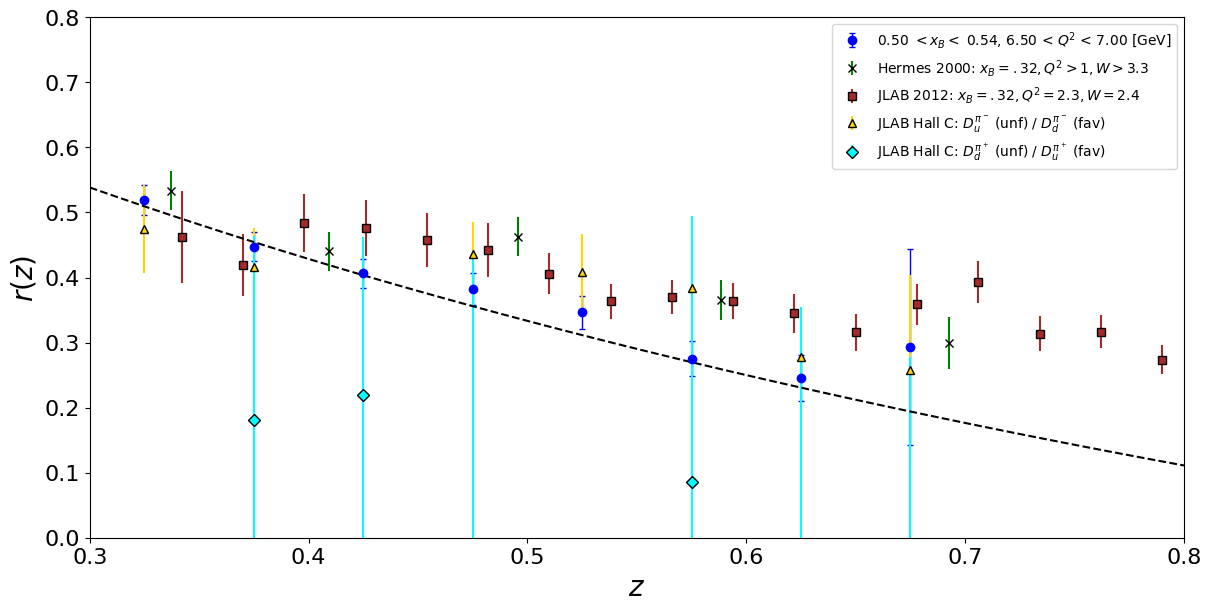

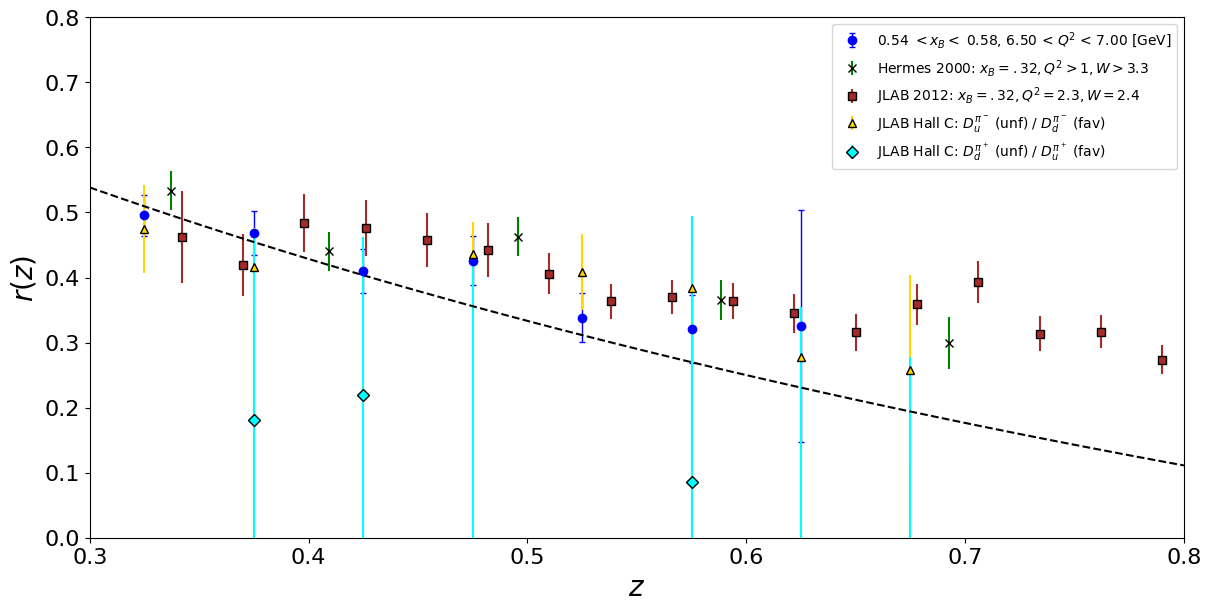

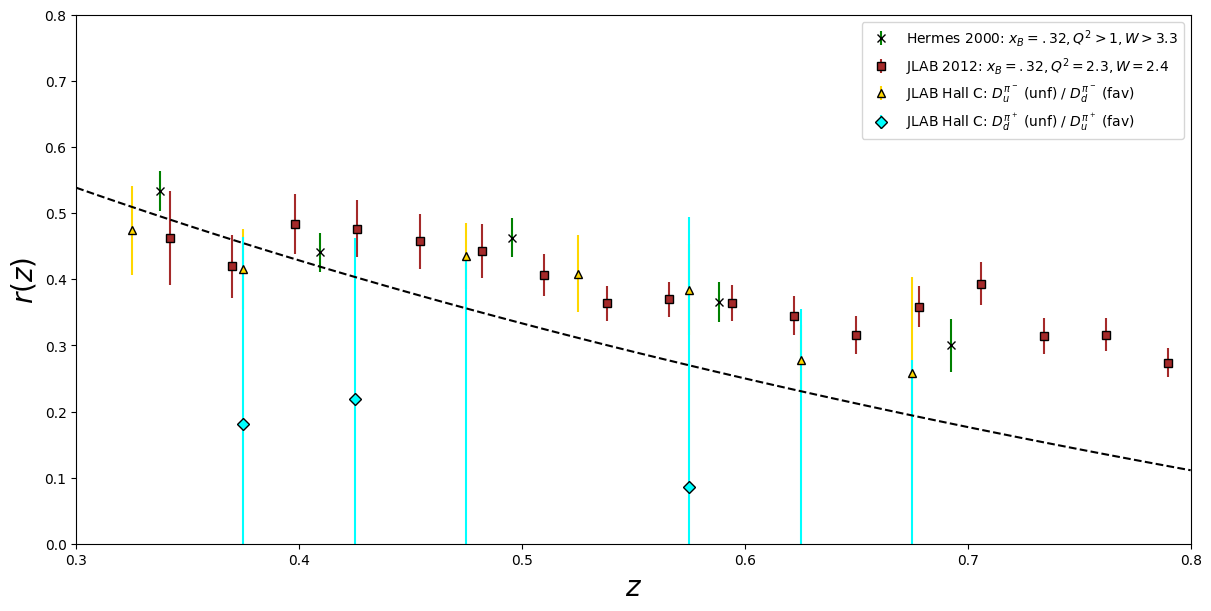

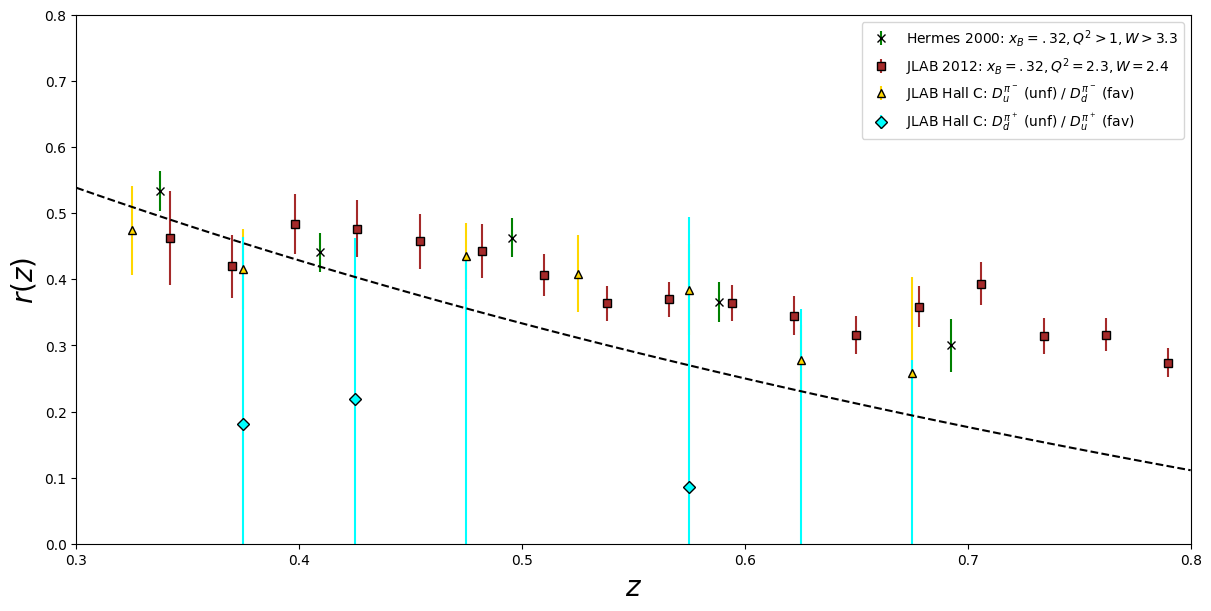

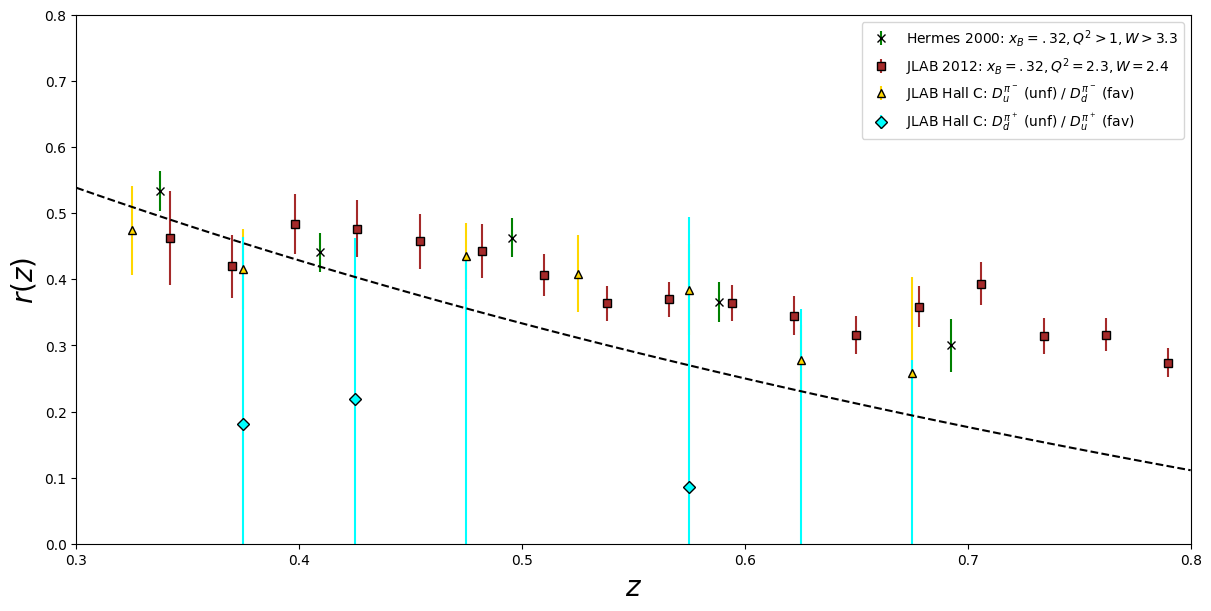

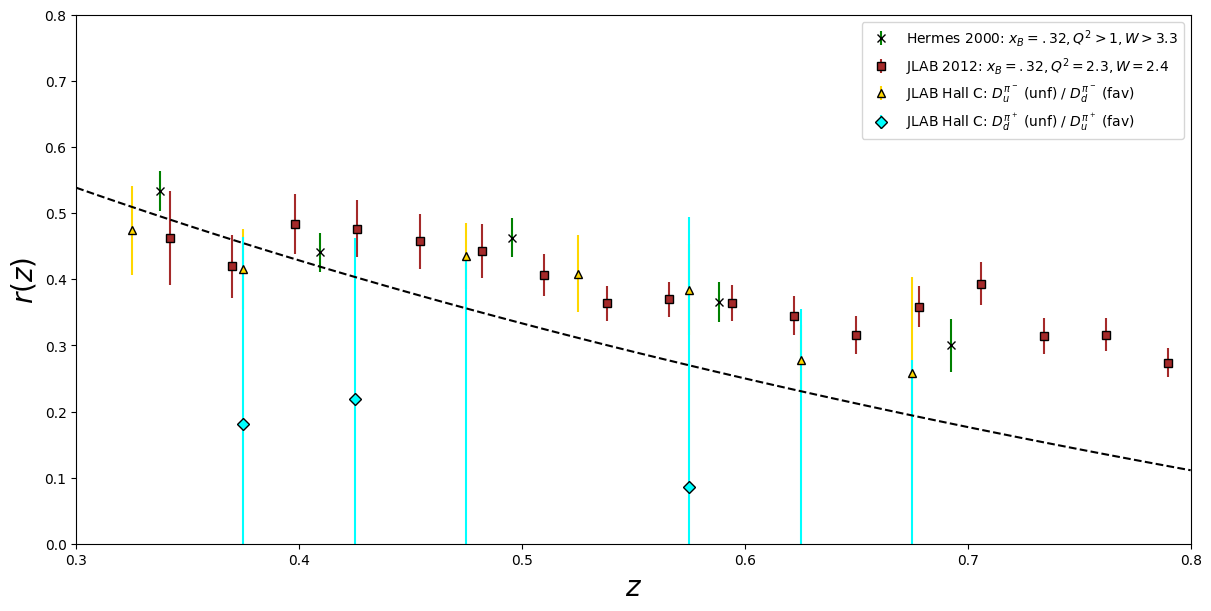

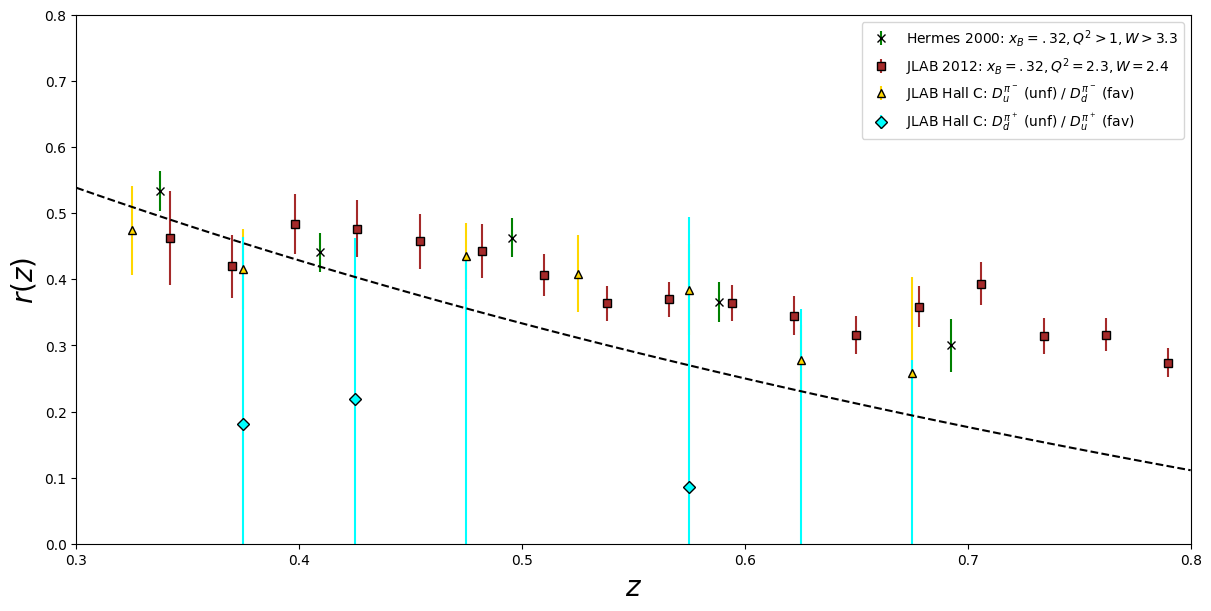

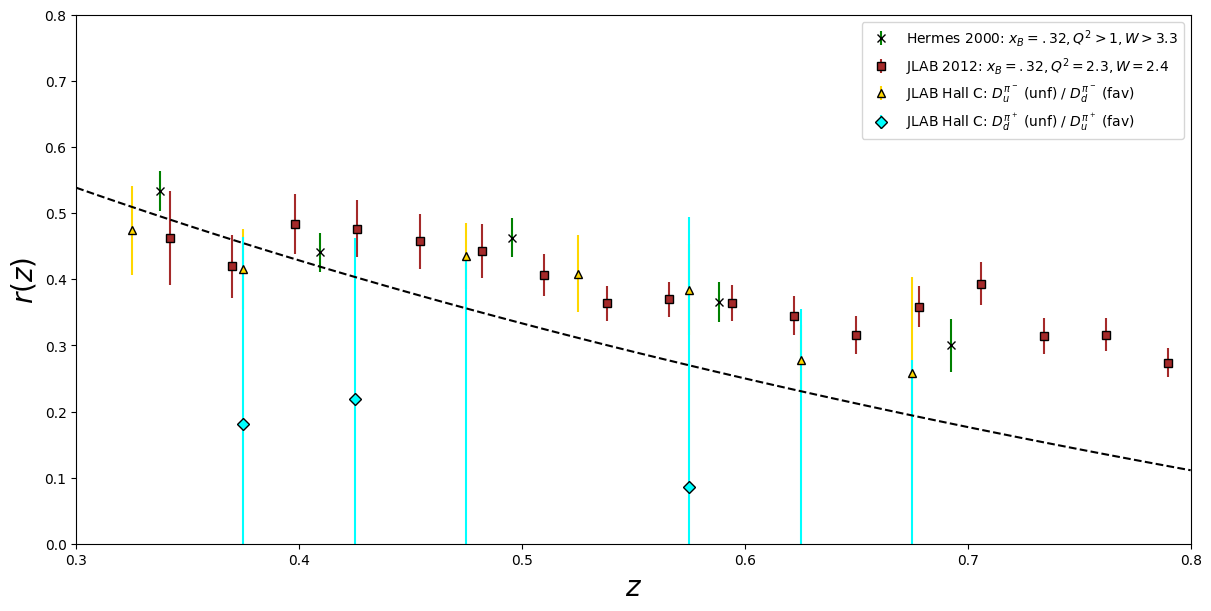

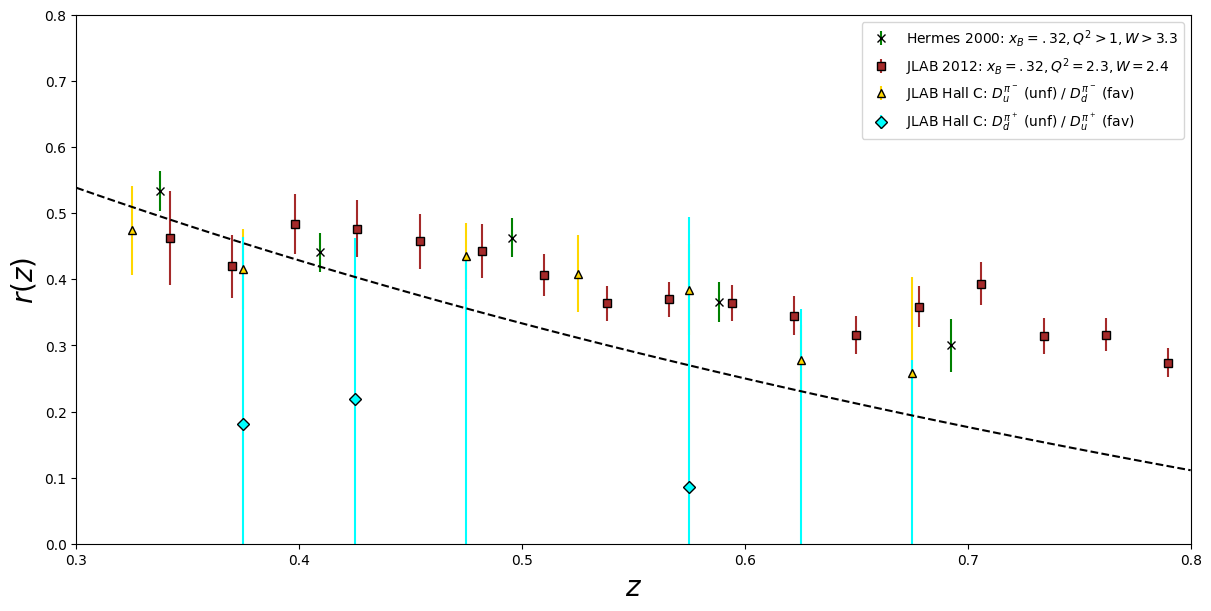

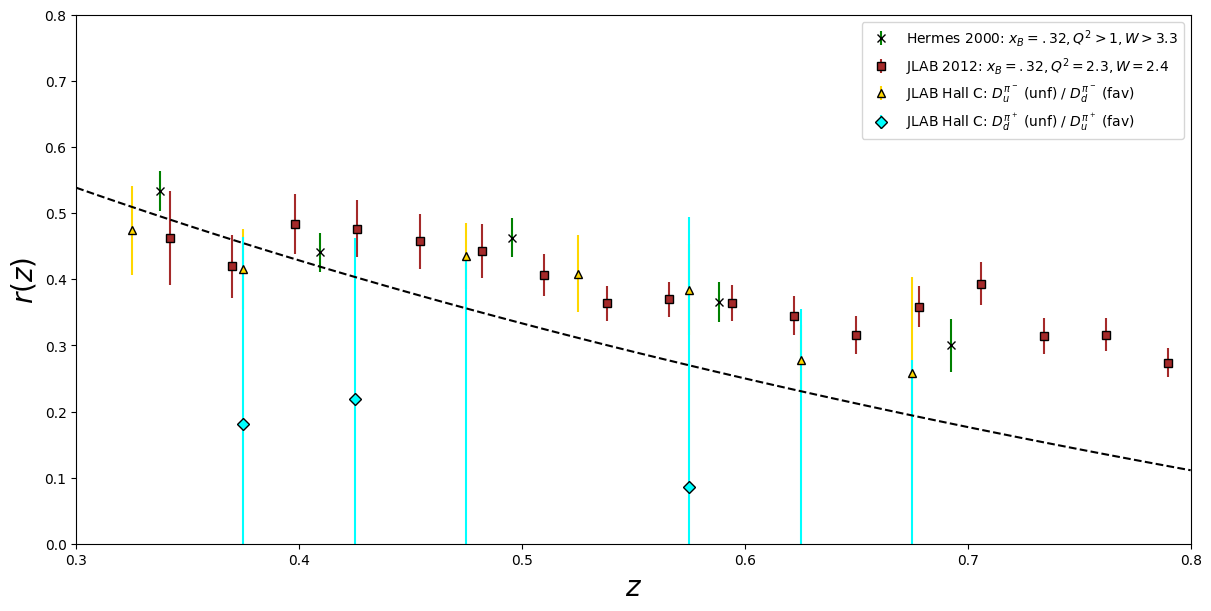

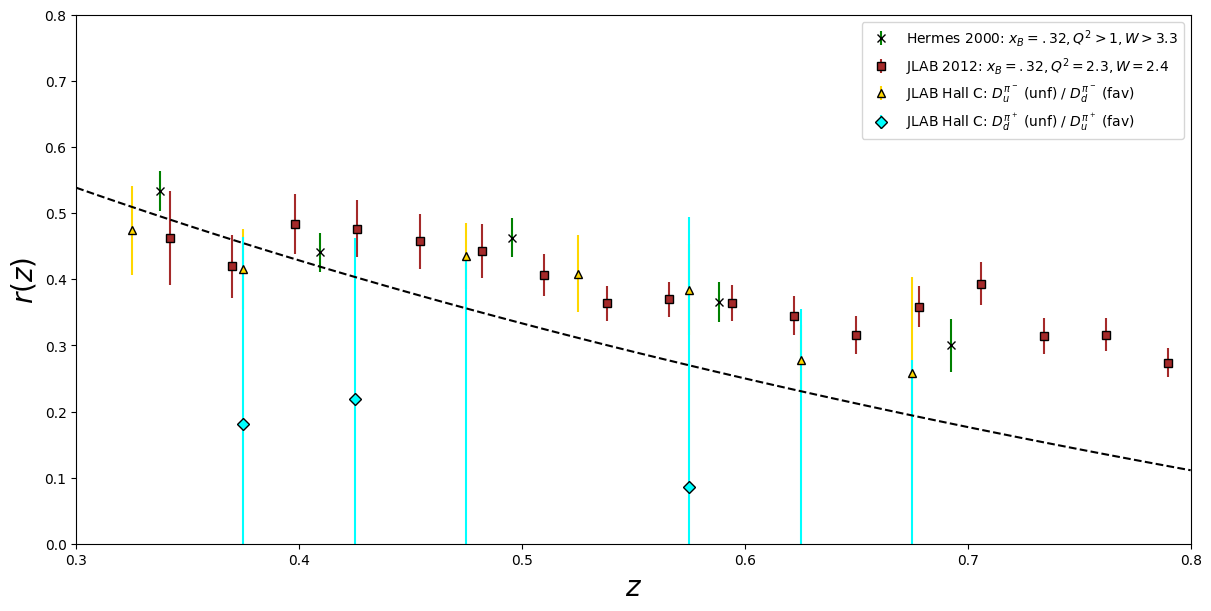

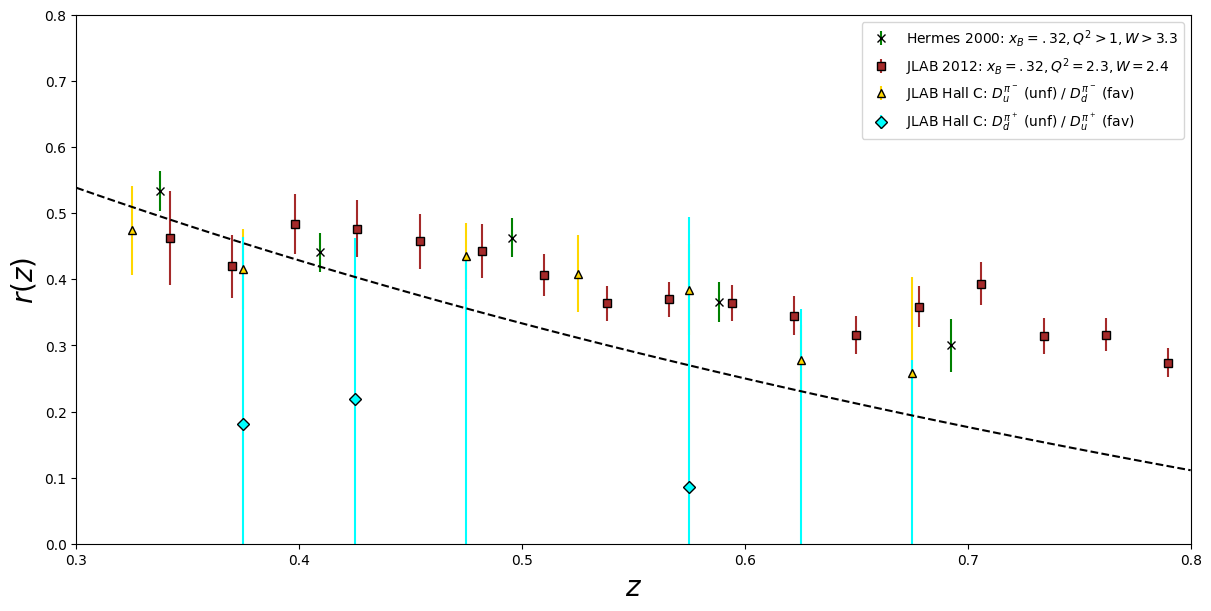

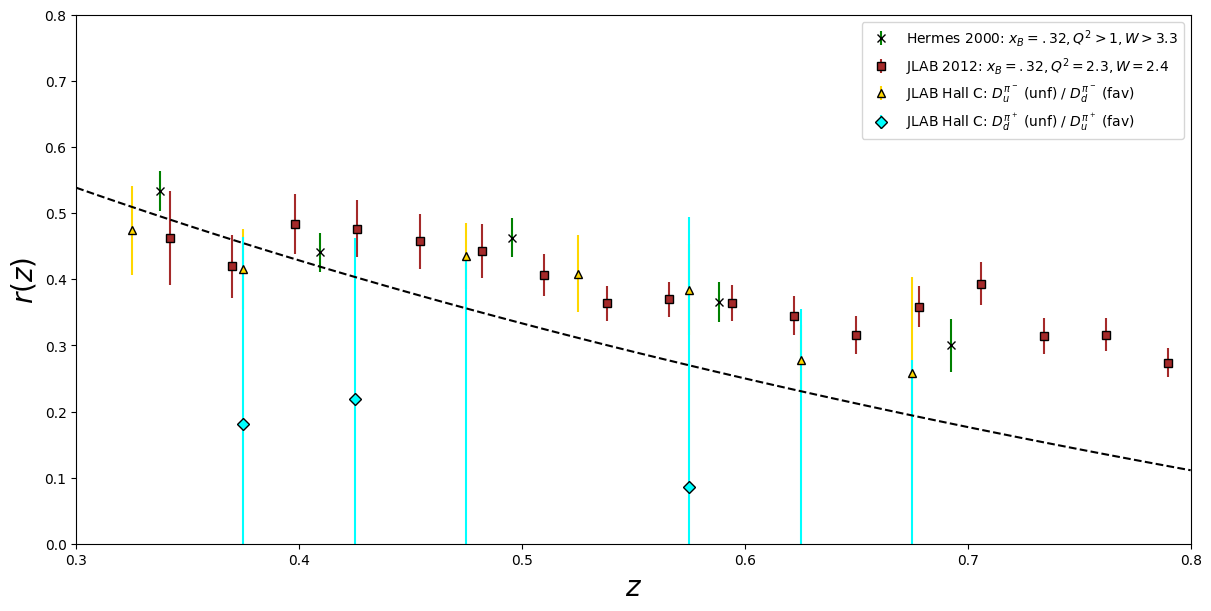

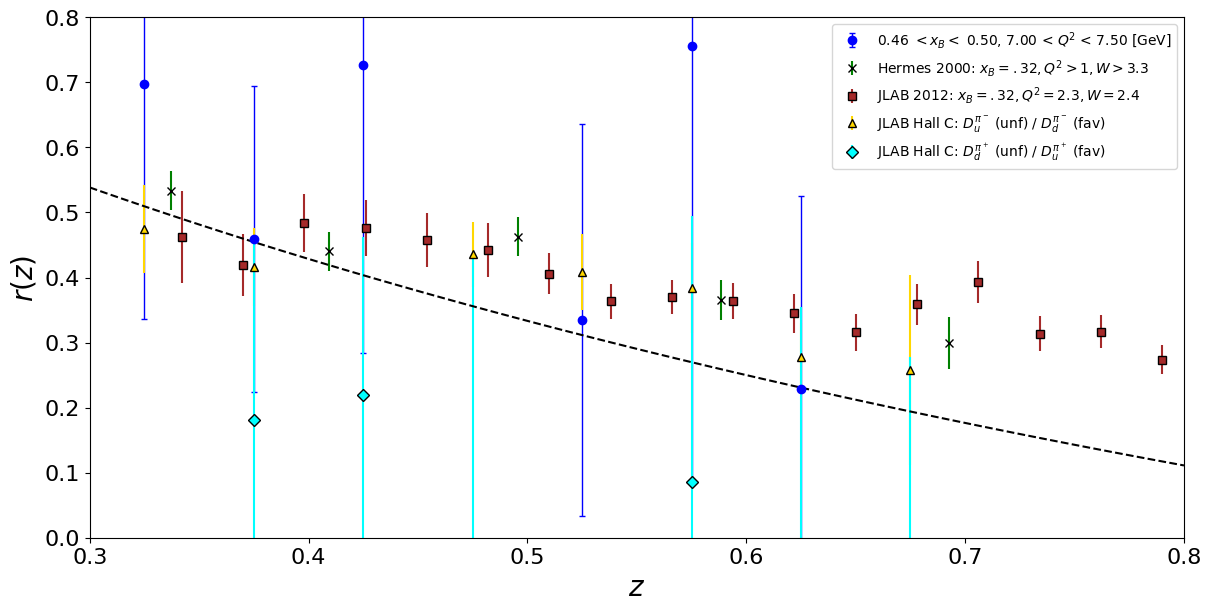

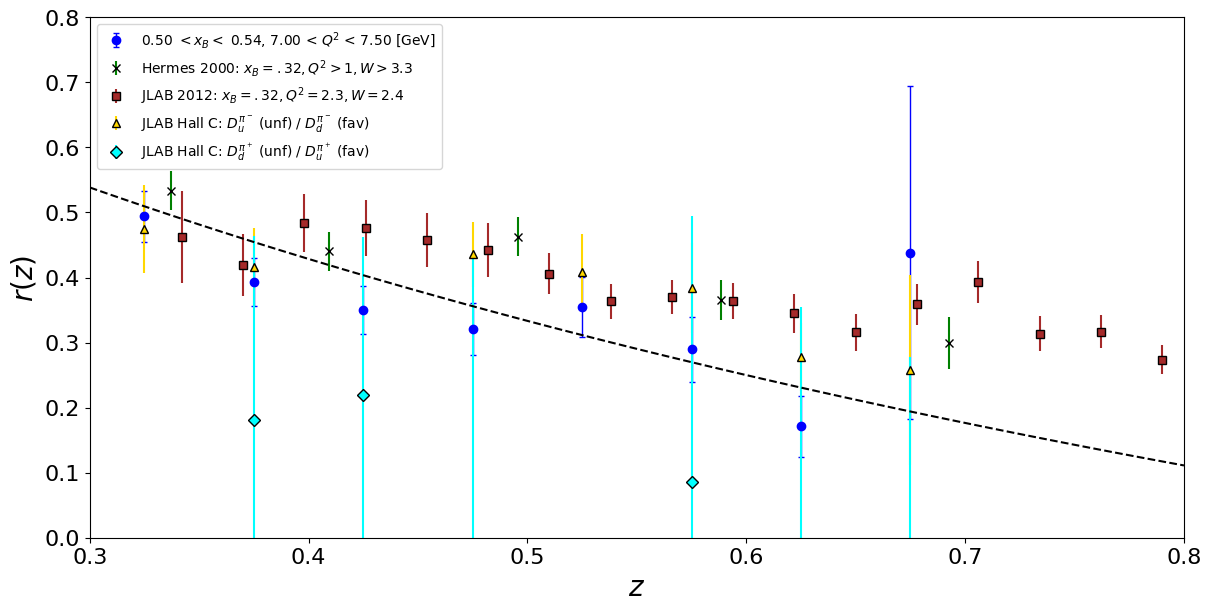

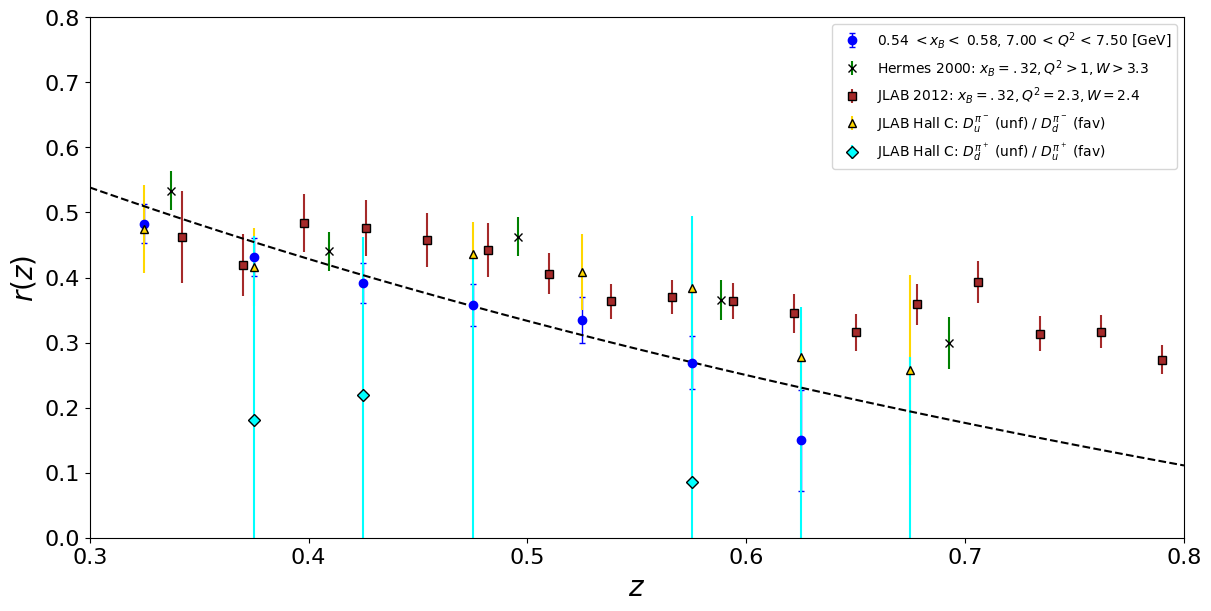

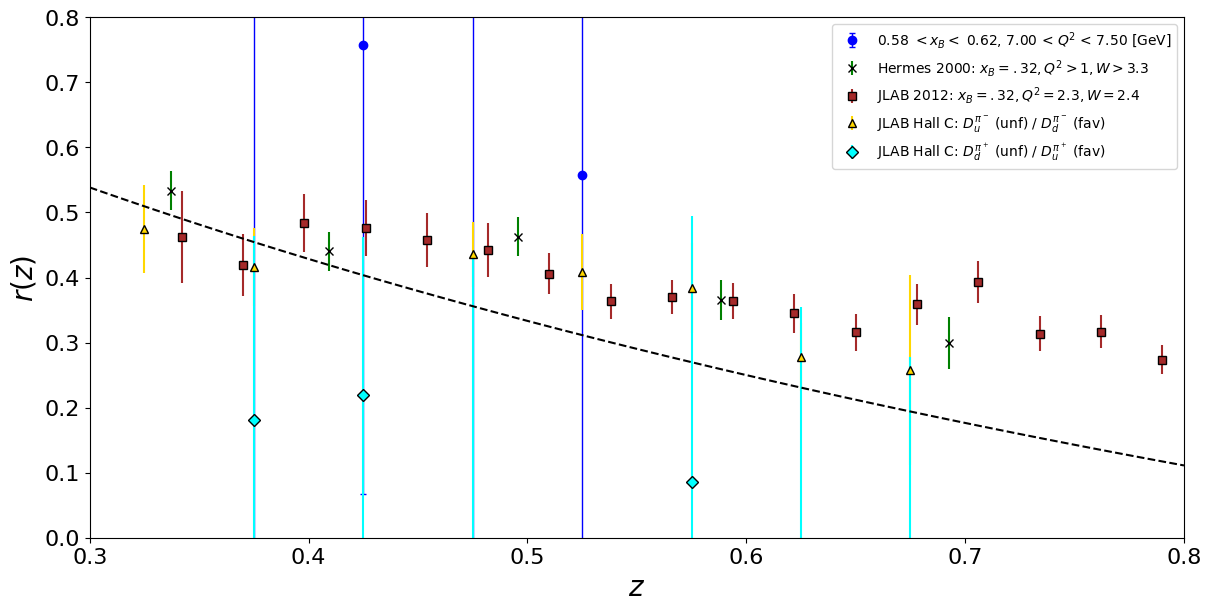

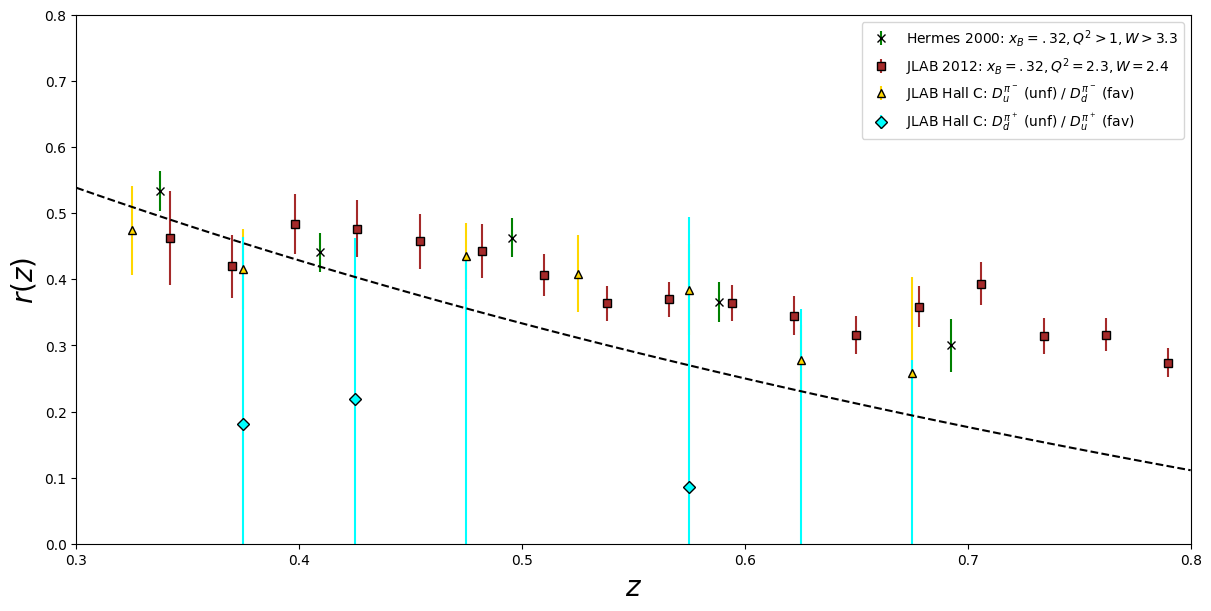

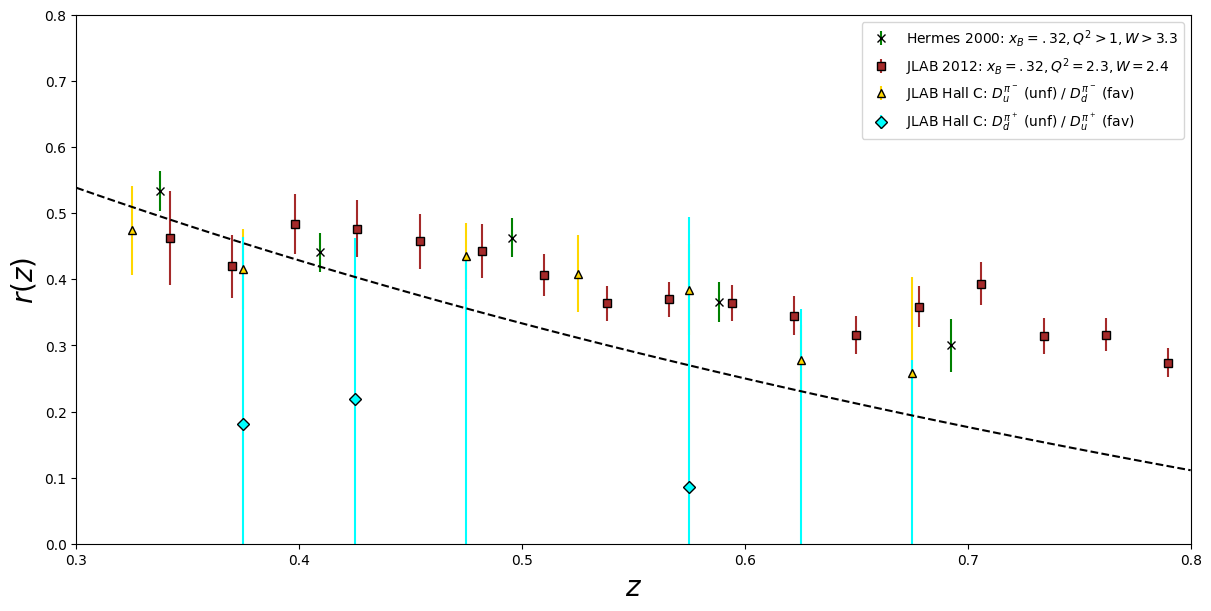

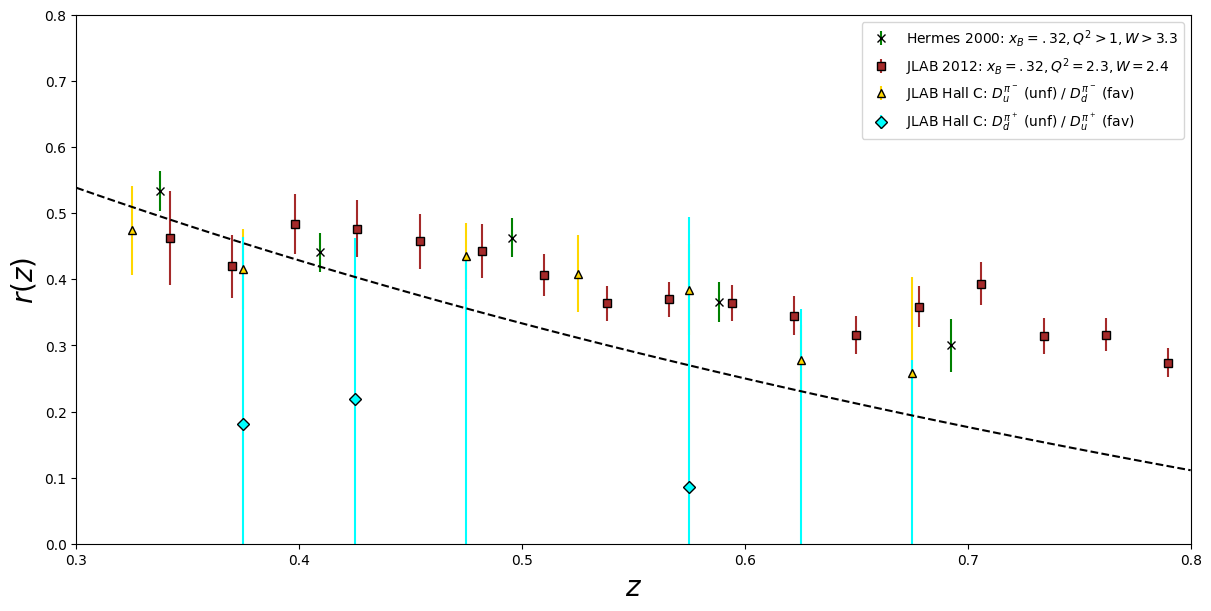

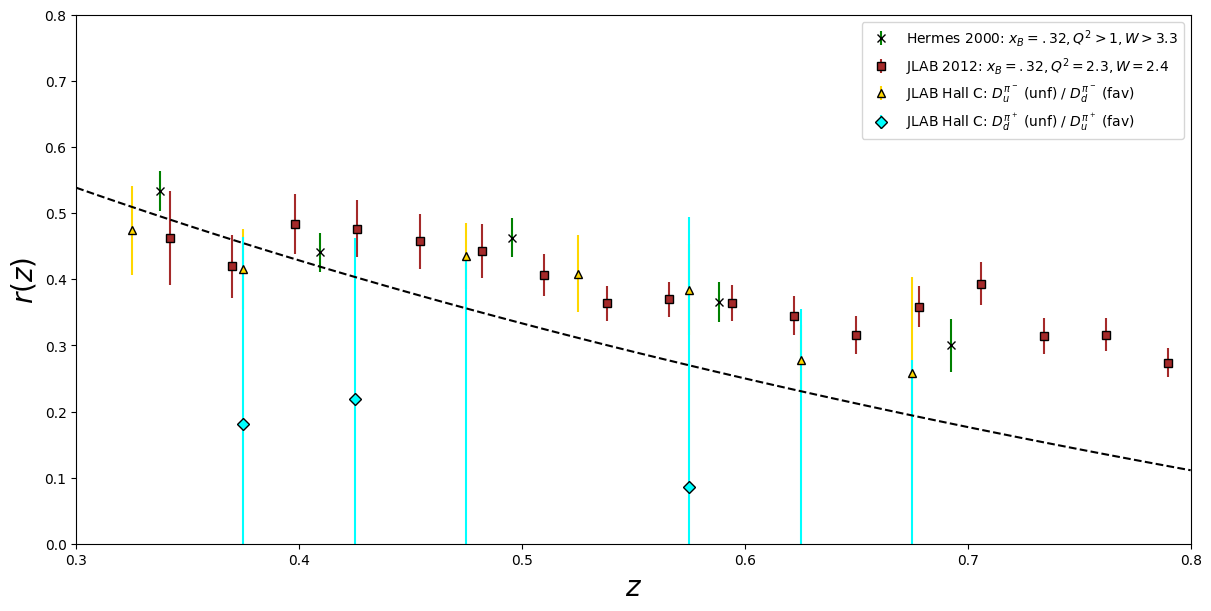

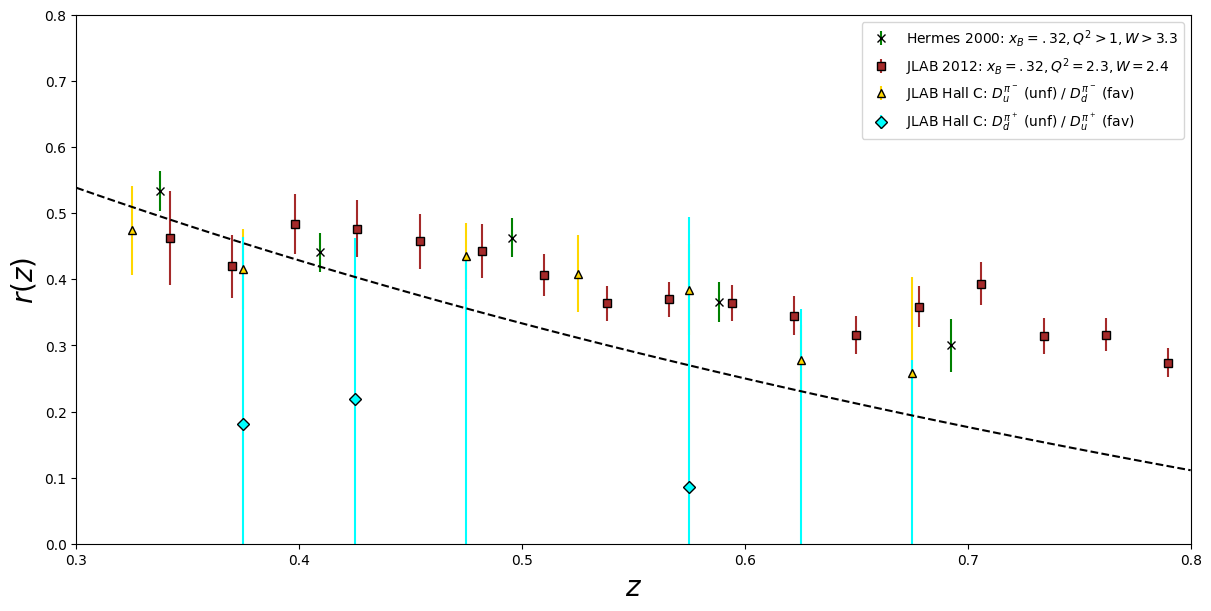

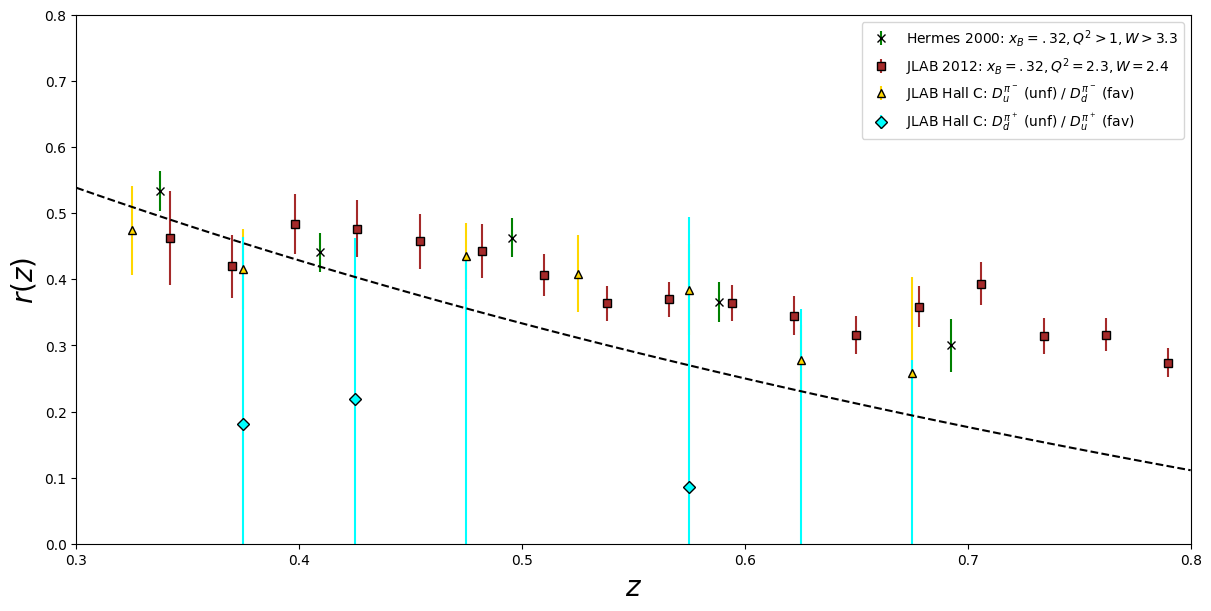

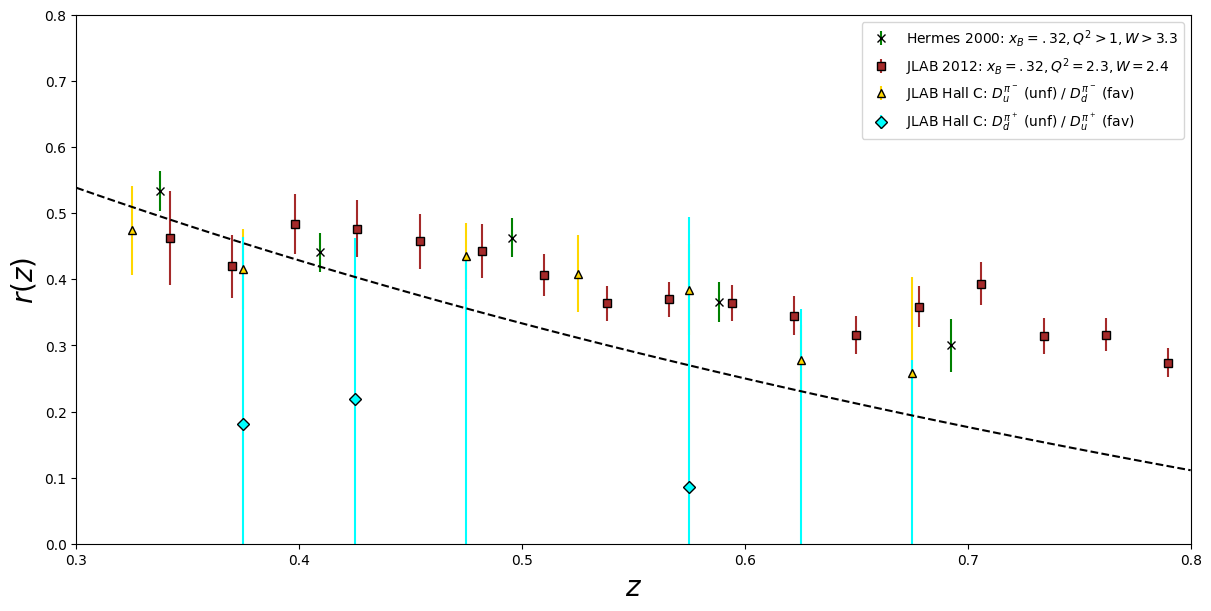

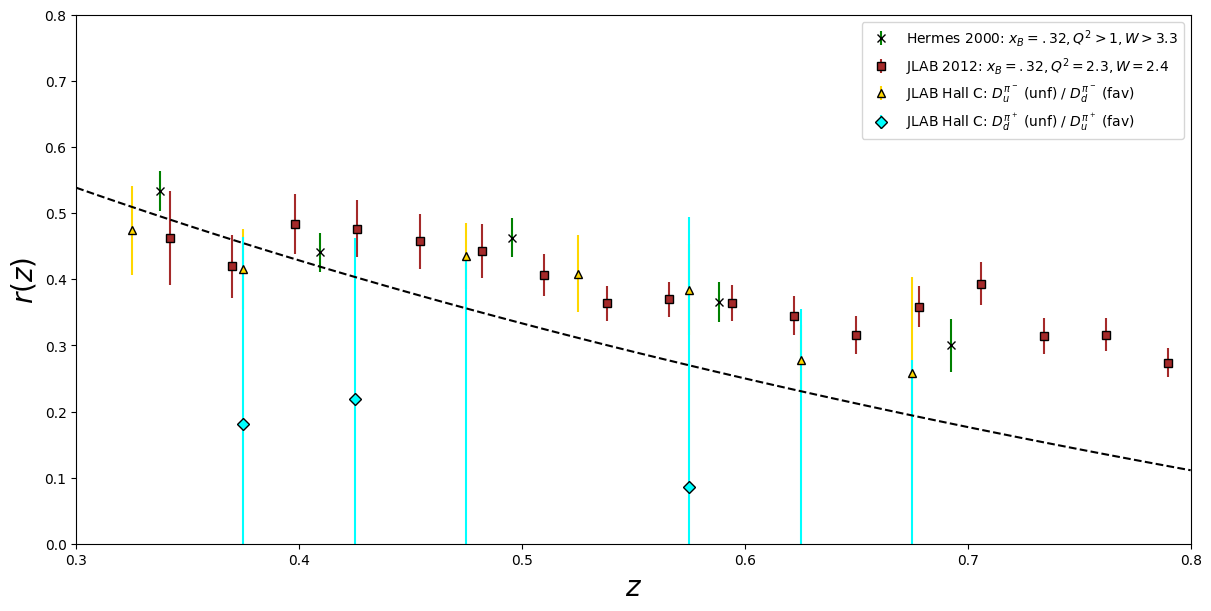

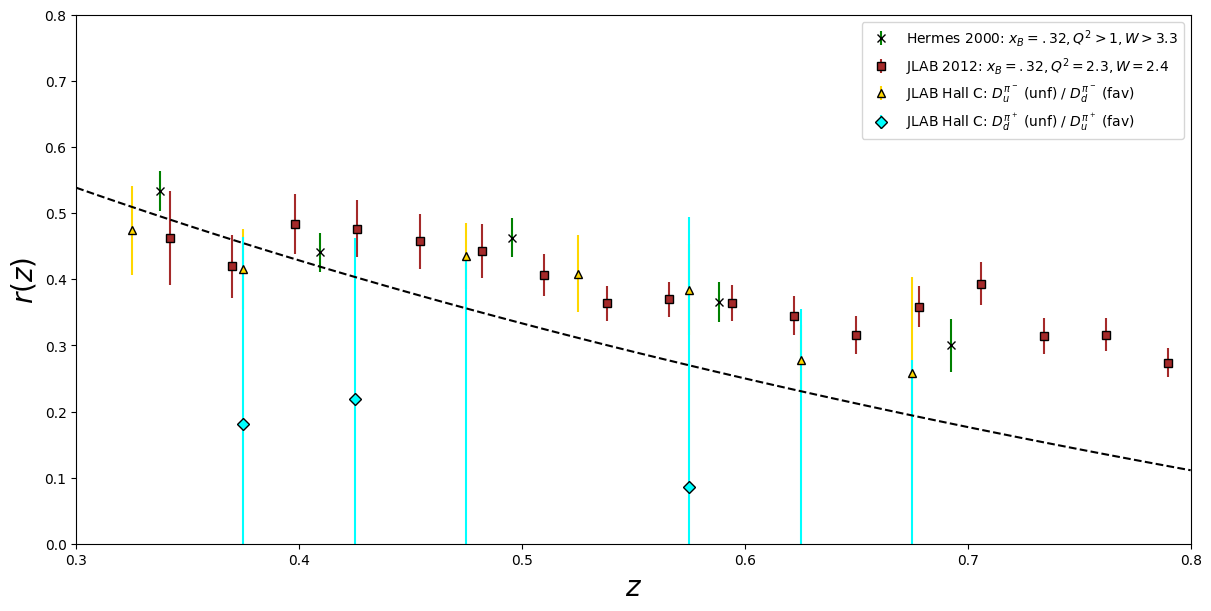

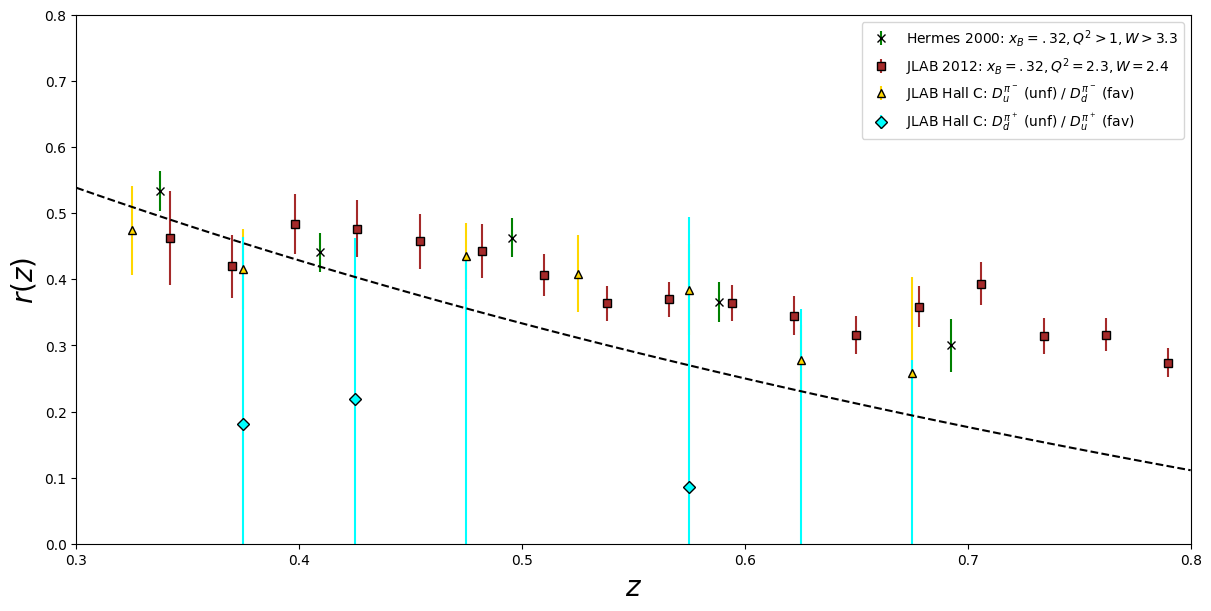

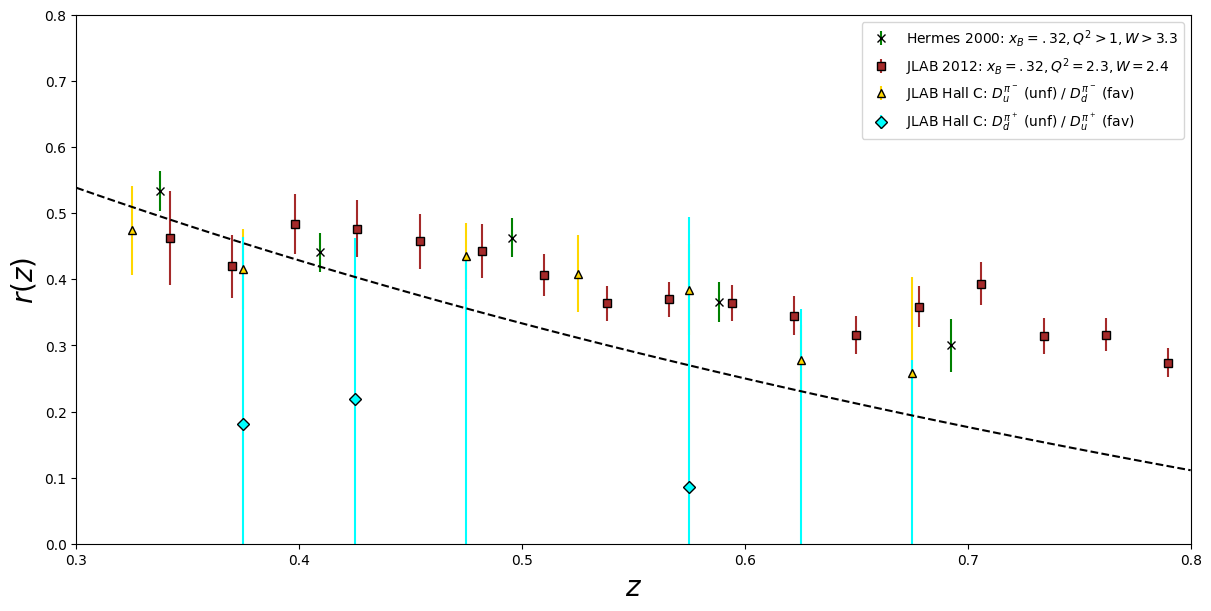

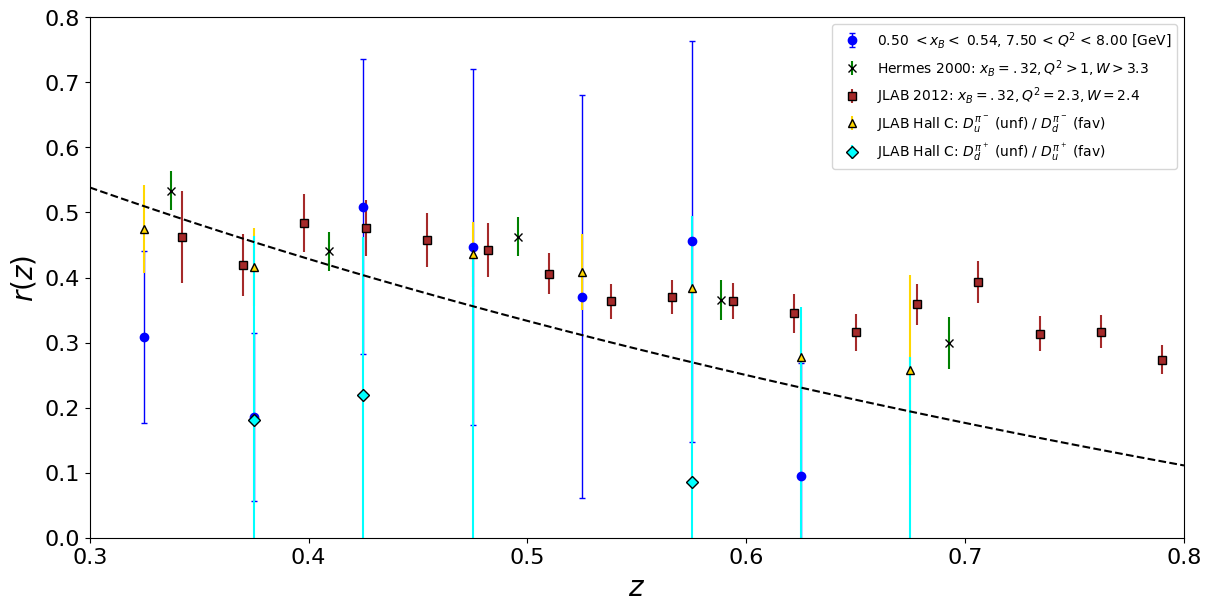

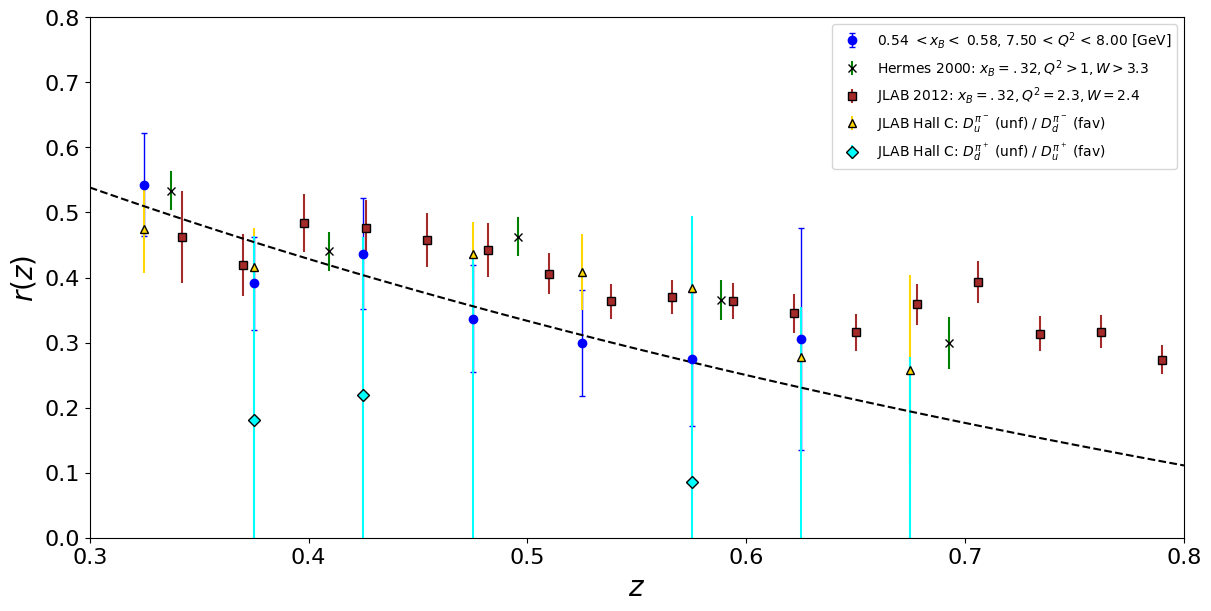

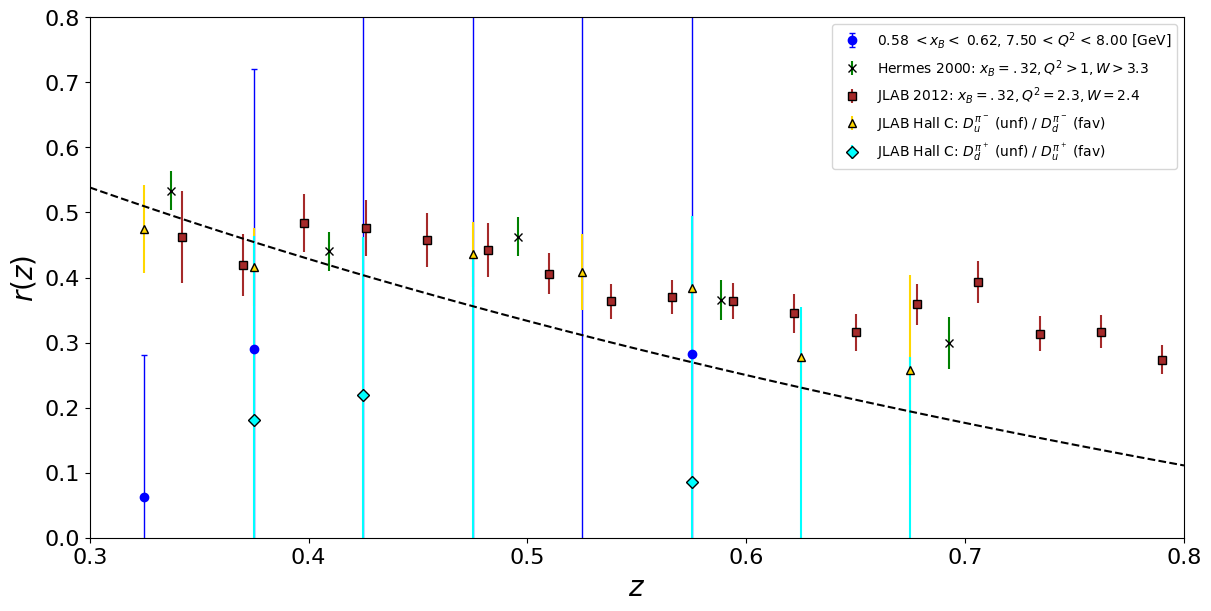

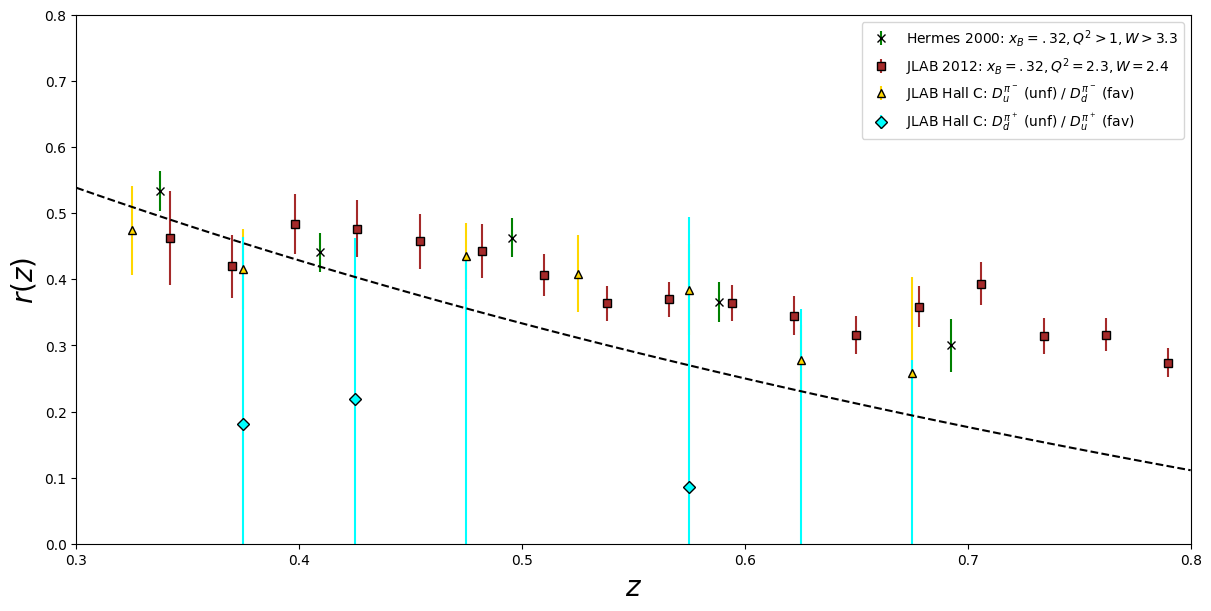

In [111]:
for q in range(12):
	
	for x in range(14):
		fig, ax = plt.subplots(figsize=(12,6), layout='constrained')
		edit_ax(ax)

		#ax.text(.7, .7, r'%.1f $< Q^2 <$ %.1f'%(2 + .5*(q), 2+.5*(q+1)), fontsize=12)
	
		label_x = r'%.2f $< x_B <$ %.2f'%( .1 + .04*x, .1 + .04*(x+1))
		make_plots(inFile_1, ax,q, x, label_x, x)
		for i in range(min(len(z), len(file_path))):
			ax.errorbar(z[i], r[i],dr[i], label=label[i], marker=marker[i], linestyle=' ', color=colorList[i+3], ms=6, mec='black')

		
		ax.plot(z_vals, ff(z_vals), marker=' ', linestyle='--', color='k')
		ax.legend()
		#plt.text(.95, .5, r'%.2f $< x_B <$ %.2f'%( .1 + .04*x, .1 + .04*(x+1) ), fontsize=12)
		#plt.title( r'%.1f $< Q^2 <$ %.1f [GeV$^2$]'%( 2 + 0.5*q, 2 + 0.5*(q+1) ), fontsize=16)
		if (x==2 and q == 0) or (x==3 and q == 1) or (x==4 and q == 2) or (x==5 and q == 3):
			fig.savefig('analysis_note/ratio_v_exp/ratio_{0}_{1}.png'.format( q+1, x+1))
			break
		
	#plt.close()